# Predicting audience neural synchrony (CorrCA-ISC) from film features — KU Leuven *Mr. Bean*

**Question.** Can low-level visual and audio features of a film predict, window by window, whether a viewer's EEG is *highly* or *weakly* synchronised with the rest of the audience (inter-subject correlation, ISC)?

**Pipeline (run top to bottom; every expensive step is cached on Drive):**

1. Align EEG and video at stimulus onset; cut into **non-overlapping windows** (`WINDOW_S`, default 4 s).
2. Preprocess EEG exactly as the dataset authors (30 Hz); compute **ISC** per participant and window — channel-average and **correlated-component (CorrCA) ISC** (filters fitted on training windows only).
3. Extract **81 low-level visual + 8 shot-timing + 69 temporal-context + 12 audio features** and **CLIP / DINOv2 embeddings** per window; visualise them.
4. Detect **shots**; build a **shot-based, chronological, interleaved train / validation / test split** with near-equal HIGH/LOW classes and buffers against leakage.
5. Define targets with **median splits**: the **audience** CorrCA ISC (primary), each viewer's CorrCA ISC (subject-wise median) and the channel-average ISC (comparison). Temporal-context features (previous windows, cut-response kernels) and a stimulus–response lag analysis address the delay between film and EEG.
6. Evaluate **all 15 combinations** of the Visual, Audio, CLIP and DINOv2 feature blocks, **raw and with PCA**, with five models (150 configurations; tuning on validation, one test); **leave-one-subject-out (LOSO) evaluation** of the top configurations, **examine the top configurations**, **ablations**, **SHAP**, a **circular-shift null test**, and export **reports, tables and 600-dpi figures**.

| § | Content | § | Content |
|---|---|---|---|
| 0 | Configuration | 7 | Shots and leakage-controlled split |
| 1 | Setup and figure style | 8 | CorrCA ISC, targets and labels |
| 2 | Data inventory | 9 | All feature-set combinations × models (raw / PCA); 9c LOSO |
| 3 | Alignment and windows | 10 | Top-configuration examination |
| 4 | EEG preprocessing (authors) | 11 | Low-level feature ablation |
| 5 | Channel-average ISC per window | 12 | Explanations: SHAP and permutation importance |
| 6 | Video + audio features, CLIP & DINOv2, visualisations | 13 | Null test, reports and export |

## 0. Configuration
All choices are here and saved with the results. Change `WINDOW_S` to analyse another window length (outputs go to separate folders).

In [ ]:
CFG = {
    # paths
    "VIDEO_DIR": "/content/drive/MyDrive/01 MLPR",
    "EEG_DIR": "/content/drive/MyDrive/01 MLPR/MrBean",
    "OUT_DIR": "/content/drive/MyDrive/MrBean_ISC_Paper_publication_final",
    "VIDEO_FILE": None,
    # alignment (Zenodo 10512414: presented stimulus = 39.77-1495.00 s of the YouTube upload)
    "SYNC_MODE": "auto", "SEGMENT_START_S": 39.77, "SEGMENT_END_S": 1495.00, "SYNC_TOL_S": 2.0,
    "EDGE_TRIM_S": 1.0,
    "WINDOW_S": 4.0,                       # non-overlapping analysis windows (s)
    # EEG (authors' protocol)
    "HIGHPASS_HZ": 0.5, "NOTCH_HZ": [50.0], "EEG_SFREQ": 30.0,
    "FALLBACK_BAD_CHANNELS": {"P01": ["B25", "B31"], "P02": ["A20", "A21", "A26", "A31", "B25", "B31"],
                              "P03": ["A28", "A29", "A30", "B25", "B31", "B32"], "P04": ["A25", "A30", "B25", "B29"],
                              "P05": ["A30", "B25", "B31"], "P06": ["A30", "B25"], "P07": [], "P08": ["B25"], "P09": ["B25"]},
    # video / audio
    "VIDEO_FPS": 5.0, "FRAME_SIZE": [427, 240], "CUT_MAD_K": 5.0,
    # split
    "N_BLOCKS": 10,                        # film divided into 10 consecutive blocks, each split train→val→test
    "SPLIT_FRACTIONS": [0.6, 0.2, 0.2],
    "SPLIT_TOLERANCE": 0.08,               # allowed deviation of each part's size (fraction of the block)
    "MIN_SHOT_WINDOWS": 2,                 # shorter shots are merged with the previous one
    "MIN_CUT_GAP_S": 0.5,                  # detections closer than this are one cut (shot-timing features)
    # labels
    "LABEL_REFERENCE": "session",          # subject-wise median over the participant's whole session ("train" = training windows only)
    # leave-one-subject-out
    "LOSO_TOP_K": 10,                      # LOSO for the top-K configurations (by validation) + the primary interpretable one
    # ISC targets
    "CORRCA_K": 3,                         # correlated components used for ISC
    "CORRCA_REG": 0.1,                     # shrinkage of the within-viewer covariance
    "PRIMARY_TARGET": "audience",          # audience | individual | individual_avg
    # temporal context
    "LAG_CONTEXT_WINDOWS": [1, 2],         # previous windows added as context features
    "CUT_KERNEL_TAUS": [1.0, 2.0, 4.0],    # decay constants (s) of the cut-response kernels
    "LABEL_LAGS": [-2, -1, 0, 1, 2, 3],    # label-lag analysis (windows)
    "BUFFER_WINDOWS": 1,                   # windows dropped at every boundary between parts
    # models
    "MODELS": ["logreg", "svm", "rf", "xgb", "mlp"],
    "N_BOOT": 1000, "N_NULL": 30, "MIN_SHIFT_S": 60, "SEED": 42,
    # figures
    "FIG_DPI": 600,
}
print("Configuration loaded.")

Configuration loaded.


## 1. Setup and figure style
Installs missing packages, mounts Drive, creates the output folders and defines one helper, `save`, that writes every figure as a **600-dpi PNG and a vector PDF**, prints a caption and records it for the report. Colour-blind-safe palette (Okabe–Ito); legends are placed below the axes so they never cover data.

In [ ]:
import importlib.util, os, subprocess, sys
os.environ["MNE_USE_NUMBA"] = "false"      # avoid Colab's numba/numpy version clash inside MNE filtering
installed = []
for mod, pkg in {"mne": "mne", "xgboost": "xgboost", "shap": "shap", "skimage": "scikit-image"}.items():
    if importlib.util.find_spec(mod) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        installed.append(pkg)
if installed:
    print("Installed", installed, "— if an import error follows, use Runtime → Restart session and run all again.")

import json, re, shutil, time, warnings, zipfile, gc
from pathlib import Path
from datetime import datetime
import numpy as np, pandas as pd, scipy.io, scipy.signal, scipy.stats
import matplotlib.pyplot as plt, cv2, mne, sklearn, xgboost, shap
from skimage.feature import local_binary_pattern
from itertools import product
import itertools
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score, f1_score, accuracy_score, confusion_matrix,
                             roc_curve, precision_recall_curve, average_precision_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyClassifier
import matplotlib as mpl, textwrap
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

OUT = Path(CFG["OUT_DIR"])
WTAG = f"w{CFG['WINDOW_S']:g}s"                  # results of different window lengths never overwrite each other
RTAG = f"{WTAG}_v3"                                # v3 = CorrCA ISC, audience target, temporal context, lag analysis
D = {"eeg": OUT / "eeg", "features": OUT / "features", "results": OUT / f"results_{RTAG}",
     "figures": OUT / f"figures_{RTAG}", "export": OUT / "export", "models": OUT / f"models_{RTAG}"}
for d in D.values():
    d.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(CFG["SEED"])
print({"mne": mne.__version__, "sklearn": sklearn.__version__, "xgboost": xgboost.__version__, "shap": shap.__version__,
       "opencv": cv2.__version__, "ffmpeg": shutil.which("ffmpeg")})


OI = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73", "vermillion": "#D55E00", "purple": "#CC79A7",
      "sky": "#56B4E9", "yellow": "#F0E442", "black": "#000000", "grey": "#8C8C8C"}
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": CFG["FIG_DPI"], "savefig.bbox": "tight", "font.family": "DejaVu Sans",
    "font.size": 10, "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.labelsize": 10.5, "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5, "legend.fontsize": 9, "legend.frameon": False, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.color": "#E6E6E6", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "pdf.fonttype": 42})
FULL, HALF = 7.0, 4.8
CAPTIONS = []


def save(fig, name, title, caption):
    """600-dpi PNG + PDF, title on the figure, caption printed and stored for the report."""
    fig.suptitle(title, fontsize=12, fontweight="bold")
    for ext in ("png", "pdf"):
        fig.savefig(D["figures"] / f"{name}.{ext}")
    plt.show()
    plt.close(fig)
    CAPTIONS.append((name, title, caption))
    print(textwrap.fill(f"{name} — {caption}", 110) + "\n")


def legend_below(fig, ax, ncol=2, handles=None, labels=None):
    h, l = (handles, labels) if handles is not None else ax.get_legend_handles_labels()
    fig.legend(h, l, loc="outside lower center", ncol=ncol, frameon=False)


def fig_ax(w=FULL, h=3.4):
    return plt.subplots(figsize=(w, h), layout="constrained")


def save_csv(df, name):
    p = D["results"] / f"{name}.csv"
    df.to_csv(p, index=False)
    return p

Installed ['mne'] — if an import error follows, use Runtime → Restart session and run all again.
Mounted at /content/drive
{'mne': '1.13.2', 'sklearn': '1.6.1', 'xgboost': '3.4.1', 'shap': '0.52.0', 'opencv': '4.14.0', 'ffmpeg': '/usr/bin/ffmpeg'}


## 2. Data inventory
Finds the video and one `.set` file per participant, and reads each participant's documented bad channels.

In [ ]:
BIOSEMI = {**{f"A{i}": n for i, n in enumerate(["Fp1", "AF7", "AF3", "F1", "F3", "F5", "F7", "FT7", "FC5", "FC3", "FC1", "C1",
                                                 "C3", "C5", "T7", "TP7", "CP5", "CP3", "CP1", "P1", "P3", "P5", "P7", "P9",
                                                 "PO7", "PO3", "O1", "Iz", "Oz", "POz", "Pz", "CPz"], 1)},
           **{f"B{i}": n for i, n in enumerate(["Fpz", "Fp2", "AF8", "AF4", "AFz", "Fz", "F2", "F4", "F6", "F8", "FT8",
                                                 "FC6", "FC4", "FC2", "FCz", "Cz", "C2", "C4", "C6", "T8", "TP8", "CP6",
                                                 "CP4", "CP2", "P2", "P4", "P6", "P8", "P10", "PO8", "PO4", "O2"], 1)}}
LABEL_RE = re.compile(r"(?<![A-Za-z0-9])([AB](?:3[0-2]|[12][0-9]|[1-9]))(?![0-9])")

vids = [p for p in Path(CFG["VIDEO_DIR"]).rglob("*") if p.suffix.lower() in {".mp4", ".mkv", ".avi", ".mov", ".webm"}]
VIDEO = Path(CFG["VIDEO_FILE"]) if CFG["VIDEO_FILE"] else max([v for v in vids if "bean" in v.name.lower()] or vids,
                                                               key=lambda p: p.stat().st_size)
rows = []
for folder in sorted(p for p in Path(CFG["EEG_DIR"]).iterdir() if p.is_dir()):
    sets = sorted(folder.glob("*.set"))
    if not sets:
        continue
    sets = [s for s in sets if "mr" in s.name.lower()] or sets
    num = re.findall(r"\d+", folder.name)[-1]
    pid = f"P{int(num):02d}"
    bads, src = [], "none"
    for t in folder.rglob("*.txt"):
        for line in t.read_text(errors="replace").splitlines():
            if re.search(r"bad|noisy|interpolat", line, re.I):
                bads += LABEL_RE.findall(line)
        if bads:
            src = f"README ({t.name})"
            break
    if not bads and pid in CFG["FALLBACK_BAD_CHANNELS"]:
        bads, src = CFG["FALLBACK_BAD_CHANNELS"][pid], "configured fallback"
    rows.append({"participant": pid, "set": str(sets[0]), "bad_channels": sorted(set(bads)), "bad_source": src})
INV = pd.DataFrame(rows)
PIDS = INV.participant.tolist()
print("Video:", VIDEO)
print(INV[["participant", "bad_channels", "bad_source"]].to_string(index=False))

Video: /content/drive/MyDrive/01 MLPR/mr_bean_episode.mp4
participant                   bad_channels          bad_source
        P01                     [B25, B31] README (README.txt)
        P02 [A20, A21, A26, A31, B25, B31] README (README.txt)
        P03 [A28, A29, A30, B25, B31, B32] README (README.txt)
        P04           [A25, A30, B25, B29] README (README.txt)
        P05                [A30, B25, B31] README (README.txt)
        P06                     [A30, B25] README (README.txt)
        P07                             [] configured fallback
        P08                          [B25] README (README.txt)
        P09                          [B25] README (README.txt)


## 3. Video–EEG alignment and windows
EEG *t* = 0 is the first frame of the presented stimulus. If the video file is the full YouTube upload, the stimulus starts at **39.77 s** of the file (`SYNC_MODE="auto"` detects this); video outside the EEG recording is discarded and the authors' 1-s edge trims are applied. The aligned interval is cut into **non-overlapping `WINDOW_S` windows**.

{
  "video_duration_s": 1509.701,
  "mode": "zenodo_segment",
  "offset_s": 39.77,
  "aligned_interval_s": [
    1.0,
    1453.0
  ],
  "n_segments": 363,
  "has_audio": true,
  "video_discarded_before_s": 39.77,
  "video_discarded_after_s": 16.93100000000004
}


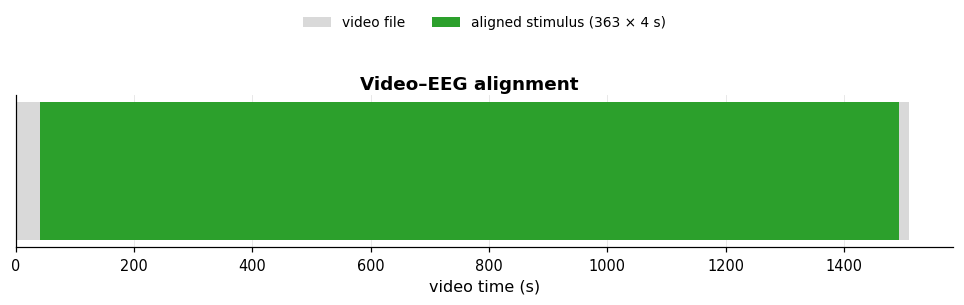

Fig01_alignment — Grey: full video file; green: aligned stimulus interval used for analysis (363 non-
overlapping 4-s windows). Video before the stimulus onset and after the end of the EEG recording is discarded.



In [ ]:
probe = json.loads(subprocess.run(["ffprobe", "-v", "error", "-print_format", "json", "-show_format", "-show_streams",
                                   str(VIDEO)], capture_output=True, text=True).stdout)
VDUR = float(probe["format"]["duration"])
HAS_AUDIO = any(s["codec_type"] == "audio" for s in probe["streams"])
EEG_DUR = {r.participant: (lambda raw: raw.n_times / raw.info["sfreq"])(
    mne.io.read_raw_eeglab(r.set, preload=False, verbose="ERROR")) for r in INV.itertuples()}
med = float(np.median(list(EEG_DUR.values())))
stim_len = CFG["SEGMENT_END_S"] - CFG["SEGMENT_START_S"]
full_upload = VDUR >= CFG["SEGMENT_END_S"] - CFG["SYNC_TOL_S"]
mode = CFG["SYNC_MODE"] if CFG["SYNC_MODE"] != "auto" else ("zenodo_segment" if full_upload else "start_aligned")
OFFSET = CFG["SEGMENT_START_S"] if (mode == "zenodo_segment" and full_upload) else 0.0
video_avail = VDUR - OFFSET
if mode == "zenodo_segment":
    video_avail = min(video_avail, stim_len)
T0 = CFG["EDGE_TRIM_S"]
T_END = min(min(EEG_DUR.values()), video_avail) - CFG["EDGE_TRIM_S"]
N_SEG = int((T_END - T0) // CFG["WINDOW_S"])
SEG = pd.DataFrame({"segment": np.arange(N_SEG), "t_start": T0 + CFG["WINDOW_S"] * np.arange(N_SEG)})
SEG["t_end"] = SEG.t_start + CFG["WINDOW_S"]
SYNC = {"video_duration_s": VDUR, "eeg_duration_s": EEG_DUR, "mode": mode, "offset_s": OFFSET,
        "aligned_interval_s": [T0, float(SEG.t_end.max())], "n_segments": N_SEG, "has_audio": HAS_AUDIO,
        "video_discarded_before_s": OFFSET, "video_discarded_after_s": VDUR - OFFSET - float(SEG.t_end.max())}
json.dump(SYNC, open(D["results"] / "alignment.json", "w"), indent=2)
print(json.dumps({k: v for k, v in SYNC.items() if k != "eeg_duration_s"}, indent=2))
if mode == "start_aligned" and VDUR - med > 30:
    print("WARNING: the video is much longer than the EEG — it may be the full upload; use SYNC_MODE='zenodo_segment'.")
fig, ax = plt.subplots(figsize=(11, 1.8))
ax.barh(0, VDUR, color="0.85", label="video file")
ax.barh(0, SEG.t_end.max() - T0, left=OFFSET + T0, color="tab:green", label=f"aligned stimulus ({N_SEG} × {CFG['WINDOW_S']:g} s)")
ax.set_yticks([])
ax.set_xlabel("video time (s)")
ax.legend(frameon=False, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.6))
save(fig, "Fig01_alignment", "Video–EEG alignment", f"Grey: full video file; green: aligned stimulus interval used for analysis ({N_SEG} non-overlapping {CFG['WINDOW_S']:g}-s windows). Video before the stimulus onset and after the end of the EEG recording is discarded.")

## 4. EEG preprocessing — authors' protocol
Per participant (Yao et al., 2024): BioSemi → 10-20 names → interpolate bad channels → average reference → 0.5-Hz high-pass → 50-Hz notch → **30 Hz** → EOG regression. Saved per participant and re-used.

No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
P01: done (94 s)
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
P02: done (112 s)
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
P03: done (114 s)
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
P04: done (62 s)
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
P05: done (68 s)
No projector specified for this dataset. Please consider the method self.add_proj.


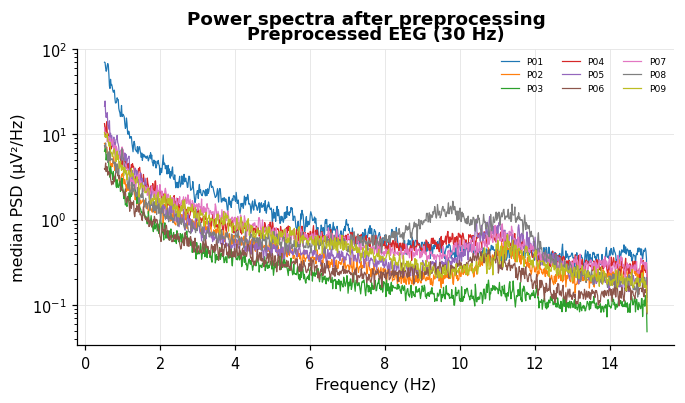

Fig02_eeg_psd — Median power spectral density across channels for each participant after the authors'
preprocessing (30 Hz).



In [ ]:
def preprocess(pid):
    out = D["eeg"] / f"{pid}_30Hz_raw.fif"
    if out.exists():
        return out
    r = INV.set_index("participant").loc[pid]
    raw = mne.io.read_raw_eeglab(r.set, preload=True, verbose="ERROR")
    raw.rename_channels({c: BIOSEMI[c] for c in raw.ch_names if c in BIOSEMI})
    eeg = [BIOSEMI[k] for k in BIOSEMI]
    eog = [c for c in raw.ch_names if c not in eeg and not re.match(r"status|trig", c, re.I)]
    if len(eog) != 4 or any(c not in raw.ch_names for c in eeg):
        raise RuntimeError(f"{pid}: unexpected channels {raw.ch_names}")
    raw.pick(eeg + eog)
    raw.set_channel_types({c: "eog" for c in eog}, on_unit_change="ignore")
    raw.set_montage("biosemi64")
    raw.info["bads"] = [BIOSEMI[b] for b in r.bad_channels]
    if raw.info["bads"]:
        raw.interpolate_bads(reset_bads=True, verbose="ERROR")
    raw.set_eeg_reference("average", projection=False, verbose="ERROR")
    raw.filter(CFG["HIGHPASS_HZ"], None, picks=["eeg", "eog"], verbose="ERROR")
    raw.notch_filter(CFG["NOTCH_HZ"], picks=["eeg", "eog"], verbose="ERROR")
    raw.resample(CFG["EEG_SFREQ"], verbose="ERROR")
    clean = mne.preprocessing.EOGRegression(picks="eeg", picks_artifact="eog").fit(raw).apply(raw)
    clean.pick("eeg").save(out, overwrite=True, verbose="ERROR")
    del raw, clean
    gc.collect()
    return out


for pid in PIDS:
    t = time.time()
    preprocess(pid)
    print(f"{pid}: done ({time.time() - t:.0f} s)")
EEG = {pid: mne.io.read_raw_fif(D["eeg"] / f"{pid}_30Hz_raw.fif", preload=True, verbose="ERROR") for pid in PIDS}
FS = EEG[PIDS[0]].info["sfreq"]
CH = EEG[PIDS[0]].ch_names
fig, ax = plt.subplots(figsize=(7, 3.5))
for pid in PIDS:
    psd = EEG[pid].compute_psd(fmin=0.5, fmax=FS / 2, verbose="ERROR")
    ax.semilogy(psd.freqs, np.median(psd.get_data(), 0) * 1e12, lw=0.8, label=pid)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("median PSD (µV²/Hz)")
ax.set_title(f"Preprocessed EEG ({FS:g} Hz)")
ax.legend(fontsize=6, ncol=3, frameon=False)
save(fig, "Fig02_eeg_psd", "Power spectra after preprocessing", "Median power spectral density across channels for each participant after the authors' preprocessing (30 Hz).")

## 5. Channel-average inter-subject correlation (ISC) per window
This is the simple ISC used in earlier runs; it is kept for comparison and to balance the split (§7). The improved **CorrCA ISC** and the prediction targets follow in §8. For participant *s* and window *w*: every channel is z-scored within the window and correlated with the mean of the same channel over the **other** participants; the channel correlations are averaged. ISC measures how closely a viewer's EEG follows the response shared by the audience. Only EEG from the same window is used, so ISC of different windows is independent of each other's data.

             count    mean     std     min     25%     50%     75%     max
participant                                                               
P01          363.0  0.0263  0.0783 -0.2031 -0.0262  0.0196  0.0760  0.3160
P02          363.0  0.0305  0.0729 -0.1840 -0.0204  0.0328  0.0774  0.3203
P03          363.0  0.0243  0.0729 -0.1698 -0.0274  0.0201  0.0672  0.2795
P04          363.0  0.0451  0.0823 -0.2175 -0.0099  0.0401  0.0978  0.2887
P05          363.0  0.0337  0.0772 -0.1848 -0.0091  0.0359  0.0825  0.2338
P06          363.0  0.0579  0.0724 -0.1261  0.0086  0.0527  0.1002  0.3446
P07          363.0  0.0358  0.0737 -0.1890 -0.0203  0.0316  0.0854  0.2242
P08          363.0  0.0394  0.0685 -0.1461 -0.0061  0.0332  0.0845  0.2814
P09          363.0  0.0390  0.0741 -0.1977 -0.0152  0.0387  0.0874  0.2806

Group-mean ISC: mean 0.0369, positive in 78.2% of windows


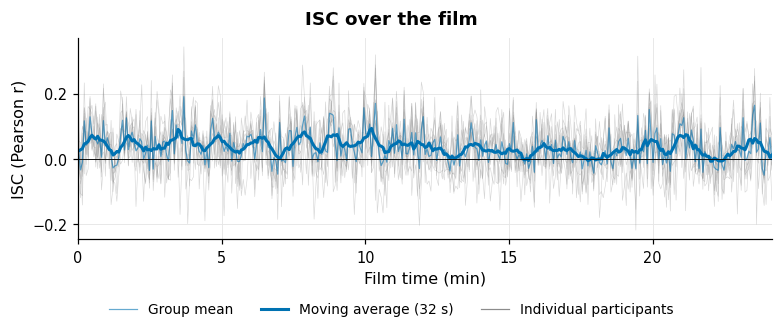

Fig03_isc_timeline — Inter-subject correlation per window for every participant (grey) and the group mean
(blue) with a moving average.



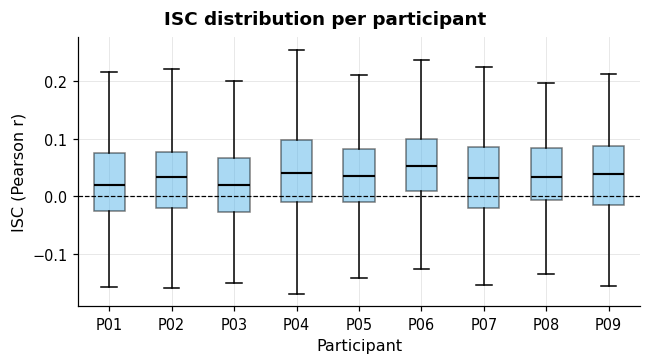

Fig04_isc_by_participant — Box = interquartile range, line = median, whiskers = 1.5 × IQR, over all windows.
Level differences between participants motivate subject-wise median labels.



In [ ]:
n = int(round(CFG["WINDOW_S"] * FS))
DATA = {pid: EEG[pid].get_data().astype(np.float32) for pid in PIDS}
rows = []
for k, t0 in zip(SEG.segment, SEG.t_start):
    s0 = int(round(t0 * FS))
    Z = {}
    for pid in PIDS:
        x = DATA[pid][:, s0:s0 + n]
        Z[pid] = (x - x.mean(1, keepdims=True)) / (x.std(1, keepdims=True) + 1e-12)
    total = np.sum([Z[p] for p in PIDS], axis=0)
    for pid in PIDS:
        others = (total - Z[pid]) / (len(PIDS) - 1)
        oz = (others - others.mean(1, keepdims=True)) / (others.std(1, keepdims=True) + 1e-12)
        rows.append({"participant": pid, "segment": k, "t_start": t0, "ISC": float(np.mean((Z[pid] * oz).mean(1)))})
ISCF = pd.DataFrame(rows)
ISCF.to_csv(D["features"] / f"isc_{WTAG}.csv", index=False)
ISC_STATS = ISCF.groupby("participant").ISC.describe()
save_csv(ISC_STATS.reset_index(), "isc_descriptive_by_participant")
print(ISC_STATS.round(4).to_string())
grp_isc = ISCF.groupby("segment").ISC.mean()
print(f"\nGroup-mean ISC: mean {grp_isc.mean():.4f}, positive in {100 * (grp_isc > 0).mean():.1f}% of windows")

fig, ax = fig_ax(FULL, 2.9)
piv = ISCF.pivot(index="t_start", columns="participant", values="ISC")
ax.plot(piv.index / 60, piv, color=OI["grey"], lw=0.4, alpha=0.35)
ax.plot(piv.index / 60, piv.mean(1), color=OI["blue"], lw=0.8, alpha=0.6, label="Group mean")
ax.plot(piv.index / 60, piv.mean(1).rolling(8, center=True, min_periods=1).mean(), color=OI["blue"], lw=2,
        label=f"Moving average ({8 * CFG['WINDOW_S']:g} s)")
ax.plot([], [], color=OI["grey"], lw=0.8, label="Individual participants")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("Film time (min)")
ax.set_ylabel("ISC (Pearson r)")
ax.set_xlim(0, piv.index.max() / 60)
legend_below(fig, ax, 3)
save(fig, "Fig03_isc_timeline", "ISC over the film", "Inter-subject correlation per window for every participant (grey) and "
     "the group mean (blue) with a moving average.")

fig, ax = fig_ax(HALF + 1, 3.2)
bp = ax.boxplot([piv[p] for p in PIDS], patch_artist=True, showfliers=False, medianprops=dict(color="k", lw=1.4))
for b in bp["boxes"]:
    b.set(facecolor=OI["sky"], alpha=0.5)
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xticks(range(1, len(PIDS) + 1))
ax.set_xticklabels(PIDS)
ax.set_xlabel("Participant")
ax.set_ylabel("ISC (Pearson r)")
save(fig, "Fig04_isc_by_participant", "ISC distribution per participant", "Box = interquartile range, line = median, "
     "whiskers = 1.5 × IQR, over all windows. Level differences between participants motivate subject-wise median labels.")

## 6. Video and audio features
**81 low-level visual features** in six groups (colour & luminance 18, hue distribution 9, texture 11, motion 15, temporal editing 10, composition 18) from frames at 5 fps, **8 shot-timing features** (§6a), and **12 audio features** (RMS, zero-crossing rate, spectral centroid/bandwidth/roll-off/flatness/flux, onset rate, silence). All features are used in the analysis (the Visual block = 81 low-level + 8 shot-timing + the temporal-context features of §6a-ii). *Note for the paper:* the film was presented **muted**, so audio features describe the soundtrack, not what viewers heard; they act as proxies for on-screen events and are examined separately in the ablations.

In [ ]:
FEAT_FILE = D["features"] / f"video_features_81_{WTAG}.csv"
W, H = CFG["FRAME_SIZE"]
GRID3 = [(i, j) for i in range(3) for j in range(3)]


def grid_means(img):
    h, w = img.shape
    return [float(img[i * h // 3:(i + 1) * h // 3, j * w // 3:(j + 1) * w // 3].mean()) for i, j in GRID3]


def frame_pass():
    t0 = OFFSET + T0 - 1.0 / CFG["VIDEO_FPS"]
    dur = SEG.t_end.max() - T0 + 1.0 / CFG["VIDEO_FPS"]
    cmd = ["ffmpeg", "-v", "error", "-ss", f"{t0:.3f}", "-i", str(VIDEO), "-t", f"{dur:.3f}", "-vf",
           f"fps={CFG['VIDEO_FPS']},scale={W}:{H}", "-f", "rawvideo", "-pix_fmt", "bgr24", "-"]
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.DEVNULL)
    rows, prev, k = [], None, 0
    yy, xx = np.indices((256, 256))
    rr = np.hypot(yy - 128, xx - 128) / 128
    han = np.outer(np.hanning(256), np.hanning(256))
    while True:
        buf = proc.stdout.read(W * H * 3)
        if len(buf) < W * H * 3:
            break
        fr = np.frombuffer(buf, np.uint8).reshape(H, W, 3)
        t = T0 - 1.0 / CFG["VIDEO_FPS"] + k / CFG["VIDEO_FPS"]
        k += 1
        g8 = cv2.cvtColor(fr, cv2.COLOR_BGR2GRAY)
        g = g8.astype(np.float32) / 255
        hsv = cv2.cvtColor(fr, cv2.COLOR_BGR2HSV)
        lab = cv2.cvtColor(fr, cv2.COLOR_BGR2LAB).astype(np.float32)
        b_, g_, r_ = [fr[..., c].astype(np.float32) / 255 for c in range(3)]
        s = hsv[..., 1].astype(np.float32) / 255
        ang = hsv[..., 0].astype(np.float32) * np.pi / 90
        rg, yb = r_ - g_, 0.5 * (r_ + g_) - b_
        hist = np.bincount(g8.ravel(), minlength=256) / g8.size
        hh, _ = np.histogram(hsv[..., 0], bins=8, range=(0, 180), weights=s)
        gx, gy = cv2.Sobel(g, cv2.CV_32F, 1, 0), cv2.Sobel(g, cv2.CV_32F, 0, 1)
        P = np.abs(np.fft.fftshift(np.fft.fft2((cv2.resize(g, (256, 256)) - g.mean()) * han))) ** 2
        ins = (rr > 0) & (rr <= 1)
        lbp = local_binary_pattern(g8, 8, 1, "uniform")
        lh = np.bincount(lbp.astype(int).ravel(), minlength=10) / lbp.size
        c = g[H // 4:3 * H // 4, W // 4:3 * W // 4]
        f = {"t": t, "lum": g.mean(), "rms": g.std(), "sat": s.mean(), "hue_cos": (np.cos(ang) * s).mean(),
             "hue_sin": (np.sin(ang) * s).mean(),
             "colorful": np.hypot(rg.std(), yb.std()) + 0.3 * np.hypot(rg.mean(), yb.mean()),
             "R": r_.mean(), "G": g_.mean(), "B": b_.mean(), "lab_a": lab[..., 1].mean() / 255, "lab_b": lab[..., 2].mean() / 255,
             "entropy": -(hist[hist > 0] * np.log2(hist[hist > 0])).sum(), "dark": (g < 0.2).mean(), "bright": (g > 0.8).mean(),
             "edge": (cv2.Canny(g8, 100, 200) > 0).mean(), "sobel": np.hypot(gx, gy).mean(),
             "lapvar": cv2.Laplacian(g, cv2.CV_32F).var(),
             "hf_ratio": P[ins & (rr > 0.45)].sum() / (P[ins & (rr < 0.15)].sum() + 1e-12),
             "spec_centroid": (rr[ins] * P[ins]).sum() / (P[ins].sum() + 1e-12),
             "lbp_entropy": -(lh[lh > 0] * np.log2(lh[lh > 0])).sum(), "center_surround": c.mean() - g.mean(),
             "warmth": (r_ - b_).mean(), **{f"hue_h{i}": v for i, v in enumerate(hh / (hh.sum() + 1e-12))},
             **{f"lumgrid_{i}{j}": v for (i, j), v in zip(GRID3, grid_means(g))}}
        hsvh = cv2.calcHist([hsv], [0, 1], None, [32, 32], [0, 180, 0, 256])
        cv2.normalize(hsvh, hsvh, 1, norm_type=cv2.NORM_L1)
        if prev is None:
            f.update({k2: np.nan for k2 in ["flow", "flow_p90", "flow_x", "flow_y", "flow_dir_ent", "moving", "fdiff",
                                             "global_flow", "local_flow", "flow_center", "flow_periph", "hist_dist"]})
            f.update({f"motgrid_{i}{j}": np.nan for i, j in GRID3})
        else:
            fl = cv2.calcOpticalFlowFarneback(prev["g8"], g8, None, 0.5, 3, 15, 3, 5, 1.2, 0)
            m = np.hypot(fl[..., 0], fl[..., 1])
            dh, _ = np.histogram(np.arctan2(fl[..., 1], fl[..., 0]), bins=8, range=(-np.pi, np.pi), weights=m)
            dh = dh / (dh.sum() + 1e-12)
            med = np.median(fl.reshape(-1, 2), 0)
            mc = m[H // 4:3 * H // 4, W // 4:3 * W // 4]
            f.update({"flow": m.mean(), "flow_p90": np.percentile(m, 90), "flow_x": np.abs(fl[..., 0]).mean(),
                      "flow_y": np.abs(fl[..., 1]).mean(), "flow_dir_ent": -(dh[dh > 0] * np.log2(dh[dh > 0])).sum(),
                      "moving": (m > 1).mean(), "fdiff": np.abs(g - prev["g"]).mean(), "global_flow": np.hypot(*med),
                      "local_flow": np.hypot(fl[..., 0] - med[0], fl[..., 1] - med[1]).mean(), "flow_center": mc.mean(),
                      "flow_periph": (m.sum() - mc.sum()) / (m.size - mc.size),
                      "hist_dist": cv2.compareHist(prev["h"], hsvh, cv2.HISTCMP_BHATTACHARYYA),
                      **{f"motgrid_{i}{j}": v for (i, j), v in zip(GRID3, grid_means(m))}})
        prev = {"g8": g8, "g": g, "h": hsvh}
        rows.append(f)
    proc.wait()
    F = pd.DataFrame(rows)
    if len(F) < 0.95 * dur * CFG["VIDEO_FPS"]:
        raise RuntimeError(f"Only {len(F)} frames decoded — check the video file.")
    return F


def aggregate_segments(F):
    hd = F.hist_dist.to_numpy()
    med = np.nanmedian(hd)
    thr = med + CFG["CUT_MAD_K"] * 1.4826 * np.nanmedian(np.abs(hd - med))
    F["cut"] = (hd > thr).astype(int)
    cut_times = F.t[F.cut == 1].to_numpy()
    for c in ["lum", "sat", "flow", "edge"]:
        F[f"d_{c}"] = F[c].diff().abs()
    out = []
    for r in SEG.itertuples():
        x = F[(F.t >= r.t_start) & (F.t < r.t_end)]
        prior = cut_times[cut_times <= r.t_start]
        ncut = int(x.cut.sum())
        d = {"segment": r.segment,
             # colour_luminance (18)
             "lum_mean": x.lum.mean(), "lum_sd": x.lum.std(), "rms_mean": x.rms.mean(), "rms_sd": x.rms.std(),
             "sat_mean": x.sat.mean(), "sat_sd": x.sat.std(), "hue_cos": x.hue_cos.mean(), "hue_sin": x.hue_sin.mean(),
             "colorful_mean": x.colorful.mean(), "colorful_sd": x.colorful.std(), "R_mean": x.R.mean(),
             "G_mean": x.G.mean(), "B_mean": x.B.mean(), "lab_a": x.lab_a.mean(), "lab_b": x.lab_b.mean(),
             "lum_entropy": x.entropy.mean(), "dark_frac": x.dark.mean(), "bright_frac": x.bright.mean(),
             # hue_distribution (9)
             **{f"hue_h{i}": x[f"hue_h{i}"].mean() for i in range(8)}, "warmth": x.warmth.mean(),
             # texture (11)
             "edge_mean": x.edge.mean(), "edge_sd": x.edge.std(), "sobel_mean": x.sobel.mean(), "sobel_sd": x.sobel.std(),
             "lapvar_mean": x.lapvar.mean(), "lapvar_sd": x.lapvar.std(), "hf_ratio_mean": x.hf_ratio.mean(),
             "hf_ratio_sd": x.hf_ratio.std(), "spec_centroid": x.spec_centroid.mean(), "lbp_entropy": x.lbp_entropy.mean(),
             "center_surround": x.center_surround.mean(),
             # motion (15)
             "flow_mean": x.flow.mean(), "flow_sd": x.flow.std(), "flow_max": x.flow.max(), "flow_p90": x.flow_p90.mean(),
             "flow_x": x.flow_x.mean(), "flow_y": x.flow_y.mean(), "flow_dir_entropy": x.flow_dir_ent.mean(),
             "moving_frac": x.moving.mean(), "fdiff_mean": x.fdiff.mean(), "fdiff_sd": x.fdiff.std(),
             "fdiff_max": x.fdiff.max(), "global_motion": x.global_flow.mean(), "local_motion": x.local_flow.mean(),
             "motion_center": x.flow_center.mean(), "motion_periphery": x.flow_periph.mean(),
             # temporal_editing (10)
             "n_cuts": ncut, "time_since_cut": r.t_start - (prior.max() if len(prior) else T0),
             "mean_shot_len": CFG["WINDOW_S"] / (ncut + 1), "hist_change_mean": x.hist_dist.mean(),
             "hist_change_max": x.hist_dist.max(), "lum_change_mean": x.d_lum.mean(), "lum_change_sd": x.d_lum.std(),
             "sat_change": x.d_sat.mean(), "motion_change": x.d_flow.mean(), "edge_change": x.d_edge.mean(),
             # composition (18)
             **{f"lumgrid_{i}{j}": x[f"lumgrid_{i}{j}"].mean() for i, j in GRID3},
             **{f"motgrid_{i}{j}": x[f"motgrid_{i}{j}"].mean() for i, j in GRID3}}
        out.append(d)
    return pd.DataFrame(out), thr


GROUPS = {"colour_luminance": ["lum_mean", "lum_sd", "rms_mean", "rms_sd", "sat_mean", "sat_sd", "hue_cos", "hue_sin",
                               "colorful_mean", "colorful_sd", "R_mean", "G_mean", "B_mean", "lab_a", "lab_b",
                               "lum_entropy", "dark_frac", "bright_frac"],
          "hue_distribution": [f"hue_h{i}" for i in range(8)] + ["warmth"],
          "texture": ["edge_mean", "edge_sd", "sobel_mean", "sobel_sd", "lapvar_mean", "lapvar_sd", "hf_ratio_mean",
                      "hf_ratio_sd", "spec_centroid", "lbp_entropy", "center_surround"],
          "motion": ["flow_mean", "flow_sd", "flow_max", "flow_p90", "flow_x", "flow_y", "flow_dir_entropy", "moving_frac",
                     "fdiff_mean", "fdiff_sd", "fdiff_max", "global_motion", "local_motion", "motion_center",
                     "motion_periphery"],
          "temporal_editing": ["n_cuts", "time_since_cut", "mean_shot_len", "hist_change_mean", "hist_change_max",
                               "lum_change_mean", "lum_change_sd", "sat_change", "motion_change", "edge_change"],
          "composition": [f"lumgrid_{i}{j}" for i, j in GRID3] + [f"motgrid_{i}{j}" for i, j in GRID3]}
VIS = [c for g in GROUPS.values() for c in g]
assert len(VIS) == 81 and len(set(VIS)) == 81, len(VIS)

if FEAT_FILE.exists():
    VF = pd.read_csv(FEAT_FILE)
    print("Loaded", FEAT_FILE)
else:
    t = time.time()
    fr_file = D["features"] / f"video_frames_{CFG['VIDEO_FPS']:g}fps_off{OFFSET:.2f}.parquet"
    FR = pd.read_parquet(fr_file) if fr_file.exists() else frame_pass()      # frames are window-independent
    FR.to_parquet(fr_file, index=False)
    VF, CUT_THR = aggregate_segments(FR)
    VF.to_csv(FEAT_FILE, index=False)
    print(f"{len(FR)} frames -> {len(VF)} segments x {len(VIS)} features ({time.time() - t:.0f} s); "
          f"cuts detected: {int(FR.cut.sum())}")
print(VF[VIS].describe().T[["mean", "std", "min", "max"]].round(4).head(20).to_string())

7261 frames -> 363 segments x 81 features (1065 s); cuts detected: 344
                 mean     std     min     max
lum_mean       0.2073  0.0802  0.0876  0.4322
lum_sd         0.0090  0.0161  0.0001  0.1281
rms_mean       0.1895  0.0476  0.0996  0.3254
rms_sd         0.0068  0.0113  0.0001  0.0870
sat_mean       0.2562  0.0340  0.1065  0.3707
sat_sd         0.0077  0.0112  0.0003  0.0921
hue_cos        0.1717  0.0474 -0.0461  0.3006
hue_sin        0.1271  0.0353  0.0533  0.3087
colorful_mean  0.0810  0.0228  0.0451  0.1800
colorful_sd    0.0037  0.0072  0.0001  0.0510
R_mean         0.2290  0.0863  0.0904  0.4461
G_mean         0.2040  0.0807  0.0911  0.4350
B_mean         0.1674  0.0632  0.0627  0.4104
lab_a          0.5068  0.0048  0.4790  0.5306
lab_b          0.5265  0.0123  0.5103  0.5664
lum_entropy    5.9597  0.3191  4.6719  6.5201
dark_frac      0.5896  0.1654  0.2649  0.8876
bright_frac    0.0115  0.0163  0.0001  0.1409
hue_h0         0.7290  0.1709  0.0223  0.9904
hue_h1   

### 6a. Shot-timing (temporal editing) features
From the detected cuts (colour-histogram distance > median + 5 × MAD; detections closer than `MIN_CUT_GAP_S` are merged) the film is described as a sequence of shots. For the centre of each window:

| Feature | Meaning | Uses the future of the film? |
|---|---|---|
| `shot_duration` | length of the current shot | yes (full shot) |
| `shot_elapsed` | time since the shot started | no |
| `shot_remaining` | time until the next cut | yes |
| `shot_position` | elapsed / duration (0 = start, 1 = end) | yes |
| `prev_shot_duration` | length of the previous shot | no |
| `next_shot_duration` | length of the next shot | yes |
| `cut_rate_30s` | cuts per minute in the preceding 30 s (editing pace) | no |
| `mean_shot_dur_30s` | mean length of shots completed in the preceding 30 s | no |

These describe the **edit of the film**, which is fixed and known in advance; no EEG is involved, so they do not leak labels. Features marked "yes" would not be available in an online (live) setting — state this in the paper.

In [ ]:
fr_file = D["features"] / f"video_frames_{CFG['VIDEO_FPS']:g}fps_off{OFFSET:.2f}.parquet"
FRS = pd.read_parquet(fr_file, columns=["t", "hist_dist"])
med_ = np.nanmedian(FRS.hist_dist)
thr_ = med_ + CFG["CUT_MAD_K"] * 1.4826 * np.nanmedian(np.abs(FRS.hist_dist - med_))
cand = FRS.t[FRS.hist_dist > thr_].to_numpy()
CUT_T = []
for c in cand:                                          # merge detections closer than MIN_CUT_GAP_S
    if not CUT_T or c - CUT_T[-1] > CFG["MIN_CUT_GAP_S"]:
        CUT_T.append(c)
CUT_T = np.array(CUT_T)
t_first, t_last = FRS.t.min(), FRS.t.max() + 1.0 / CFG["VIDEO_FPS"]
S_START = np.r_[t_first, CUT_T]
S_END = np.r_[CUT_T, t_last]
S_DUR = S_END - S_START
SHOT_TIMING = ["shot_duration", "shot_elapsed", "shot_remaining", "shot_position", "prev_shot_duration",
               "next_shot_duration", "cut_rate_30s", "mean_shot_dur_30s"]
rows_ = []
for k, t0 in zip(SEG.segment, SEG.t_start):
    tc = t0 + CFG["WINDOW_S"] / 2
    i = int(np.clip(np.searchsorted(S_START, tc, side="right") - 1, 0, len(S_START) - 1))
    past_cuts = CUT_T[(CUT_T <= tc) & (CUT_T > tc - 30)]
    done = (S_END <= tc) & (S_END > tc - 30)
    rows_.append({"segment": k, "shot_duration": S_DUR[i], "shot_elapsed": tc - S_START[i], "shot_remaining": S_END[i] - tc,
                  "shot_position": (tc - S_START[i]) / S_DUR[i], "prev_shot_duration": S_DUR[i - 1] if i > 0 else np.nan,
                  "next_shot_duration": S_DUR[i + 1] if i + 1 < len(S_DUR) else np.nan,
                  "cut_rate_30s": len(past_cuts) / (max(min(30.0, tc - t_first), 1.0) / 60),
                  "mean_shot_dur_30s": S_DUR[done].mean() if done.any() else np.nan})
SHOTF = pd.DataFrame(rows_)
VF = VF.drop(columns=[c for c in SHOT_TIMING if c in VF.columns]).merge(SHOTF, on="segment")
GROUPS["shot_timing"] = SHOT_TIMING
VIS = VIS + SHOT_TIMING
SHOTF.to_csv(D["features"] / f"shot_timing_{WTAG}.csv", index=False)
print(f"{len(CUT_T)} cuts -> {len(S_DUR)} shots; shot duration median {np.median(S_DUR):.1f} s "
      f"(IQR {np.percentile(S_DUR, 25):.1f}–{np.percentile(S_DUR, 75):.1f} s, max {S_DUR.max():.1f} s)")
print(SHOTF[SHOT_TIMING].describe().T.round(3).to_string())

215 cuts -> 216 shots; shot duration median 2.9 s (IQR 0.8–7.4 s, max 97.4 s)
                    count    mean     std  min    25%     50%     75%     max
shot_duration       363.0  26.962  26.061  0.6  7.700  19.000  38.600  97.400
shot_elapsed        363.0  13.212  17.020  0.0  2.200   6.600  17.600  95.200
shot_remaining      363.0  13.750  16.927  0.2  2.800   7.600  17.700  94.200
shot_position       363.0   0.468   0.297  0.0  0.214   0.472   0.708   0.995
prev_shot_duration  362.0  10.035  15.852  0.6  2.000   4.800  10.600  97.400
next_shot_duration  354.0  10.185  12.528  0.6  1.800   5.400  13.000  97.400
cut_rate_30s        363.0   9.008   8.537  0.0  2.000   6.000  12.000  44.000
mean_shot_dur_30s   314.0  12.742  16.719  0.7  4.025   7.225  13.683  97.400


### 6a-ii. Temporal-context features (stimulus–response lag)
The EEG response follows the film with a delay, so the current window alone may miss the cause of synchrony. Two kinds of context features are added to the **Visual block** (group *Temporal context*):

* **Lagged features:** the motion, temporal-editing and shot-timing features of the **previous 1 and 2 windows** (a fixed, pre-specified list — no data-driven selection);
* **Cut-response kernels:** Σ exp(−Δt/τ) over all cuts before the window centre, for τ = 1, 2, 4 s — a smooth "recent-cut" drive that decays after each cut.

Only past video is used; no EEG enters the features.

In [ ]:
LAG_BASE = GROUPS["motion"] + GROUPS["temporal_editing"] + GROUPS["shot_timing"]
lag_df = VF.set_index("segment").loc[SEG.segment, LAG_BASE]
ctx = {}
for L in CFG["LAG_CONTEXT_WINDOWS"]:
    for f in LAG_BASE:
        ctx[f"{f}_lag{L}"] = lag_df[f].shift(L).to_numpy()
tc_all = SEG.t_start.to_numpy() + CFG["WINDOW_S"] / 2
for tau in CFG["CUT_KERNEL_TAUS"]:
    dt = tc_all[:, None] - CUT_T[None, :]
    ctx[f"cut_kernel_{tau:g}s"] = np.where(dt >= 0, np.exp(-dt / tau), 0).sum(1)
CTX = pd.DataFrame(ctx).assign(segment=SEG.segment.to_numpy())
CONTEXT = [c for c in CTX.columns if c != "segment"]
VF = VF.drop(columns=[c for c in CONTEXT if c in VF.columns]).merge(CTX, on="segment")
GROUPS["temporal_context"] = CONTEXT
VIS = VIS + CONTEXT
print(f"{len(CONTEXT)} temporal-context features added; Visual block now has {len(VIS)} features")

69 temporal-context features added; Visual block now has 158 features


/tmp/ipykernel_472/453502307.py:10: RuntimeWarning: overflow encountered in exp
  ctx[f"cut_kernel_{tau:g}s"] = np.where(dt >= 0, np.exp(-dt / tau), 0).sum(1)


In [ ]:
AUD_FILE = D["features"] / f"audio_features_12_{WTAG}.csv"
AUDIO = ["aud_rms_mean", "aud_rms_sd", "aud_zcr", "aud_centroid_mean", "aud_centroid_sd", "aud_bandwidth", "aud_rolloff",
         "aud_flatness", "aud_flux_mean", "aud_flux_sd", "aud_onset_rate", "aud_silence_frac"]


def audio_features():
    sr = 16000
    cmd = ["ffmpeg", "-v", "error", "-ss", f"{OFFSET + T0:.3f}", "-i", str(VIDEO), "-t", f"{SEG.t_end.max() - T0:.3f}",
           "-vn", "-ac", "1", "-ar", str(sr), "-f", "s16le", "-"]
    y = np.frombuffer(subprocess.run(cmd, capture_output=True).stdout, np.int16).astype(np.float32) / 32768
    if len(y) < sr:
        raise RuntimeError("no audio decoded")
    nfft, hop = 400, 160
    frames = np.lib.stride_tricks.sliding_window_view(y, nfft)[::hop] * np.hanning(nfft)
    S = np.abs(np.fft.rfft(frames, axis=1)) + 1e-10
    fr = np.fft.rfftfreq(nfft, 1 / sr)
    tt = np.arange(len(frames)) * hop / sr + T0
    rms = np.sqrt((frames ** 2).mean(1))
    zcr = (np.abs(np.diff(np.sign(frames), axis=1)) > 0).mean(1)
    cen = (S * fr).sum(1) / S.sum(1)
    bw = np.sqrt((S * (fr - cen[:, None]) ** 2).sum(1) / S.sum(1))
    roll = fr[np.argmax(np.cumsum(S, 1) >= 0.85 * S.sum(1, keepdims=True), axis=1)]
    flat = np.exp(np.log(S).mean(1)) / S.mean(1)
    flux = np.r_[0, np.sqrt((np.diff(S / S.sum(1, keepdims=True), axis=0) ** 2).sum(1))]
    thr_on = np.median(flux) + 2 * 1.4826 * np.median(np.abs(flux - np.median(flux)))
    onsets = tt[np.r_[False, (flux[1:-1] > thr_on) & (flux[1:-1] > flux[:-2]) & (flux[1:-1] >= flux[2:]), False]]
    silence = rms < 0.05 * np.percentile(rms, 95)
    out = []
    for r in SEG.itertuples():
        m = (tt >= r.t_start) & (tt < r.t_end)
        vals = [rms[m].mean(), rms[m].std(), zcr[m].mean(), cen[m].mean(), cen[m].std(), bw[m].mean(), roll[m].mean(),
                flat[m].mean(), flux[m].mean(), flux[m].std(),
                ((onsets >= r.t_start) & (onsets < r.t_end)).sum() / CFG["WINDOW_S"], silence[m].mean()]
        out.append({"segment": r.segment, **dict(zip(AUDIO, vals))})
    return pd.DataFrame(out)


AF = None
if AUD_FILE.exists():
    AF = pd.read_csv(AUD_FILE)
elif HAS_AUDIO:
    try:
        AF = audio_features()
        AF.to_csv(AUD_FILE, index=False)
    except Exception as exc:
        print("Audio features not available:", exc)
else:
    print("The video file has no audio stream — audio features skipped.")
if AF is not None:
    VF = VF.drop(columns=[c for c in AUDIO if c in VF.columns]).merge(AF, on="segment")
    print("Audio features added (control only):", AUDIO)
FEATURES = VIS + (AUDIO if AF is not None else [])
GROUPS_ALL = {**GROUPS, **({"audio": AUDIO} if AF is not None else {})}
print(f"Main feature set: {len(FEATURES)} features")

Audio features added (control only): ['aud_rms_mean', 'aud_rms_sd', 'aud_zcr', 'aud_centroid_mean', 'aud_centroid_sd', 'aud_bandwidth', 'aud_rolloff', 'aud_flatness', 'aud_flux_mean', 'aud_flux_sd', 'aud_onset_rate', 'aud_silence_frac']
Main feature set: 170 features


### 6b. Feature visualisations and descriptive statistics
Descriptive statistics of all features (`results/feature_descriptives.csv`), detected cuts, feature-group time courses, the feature correlation structure, PCA and t-SNE of the windows, and the relation between editing and ISC.

group
audio               12
colour_luminance    18
composition         18
hue_distribution     9
motion              15
shot_timing          8
temporal_context    69
temporal_editing    10
texture             11


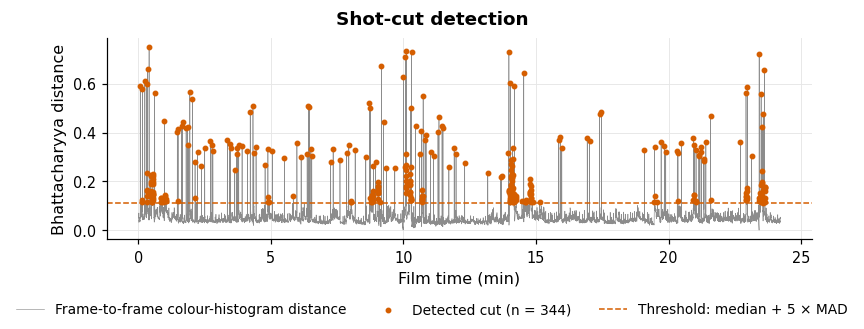

Fig05_cut_detection — Colour-histogram distance between consecutive frames (5 fps). Values above the robust
threshold are detected as cuts; they define the shots used for splitting.



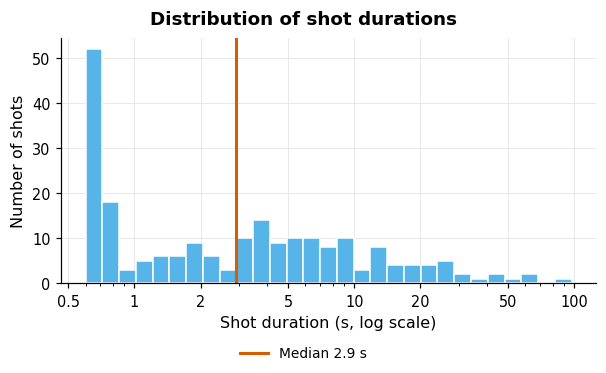

Fig05b_shot_durations — 216 shots detected in the aligned stimulus.



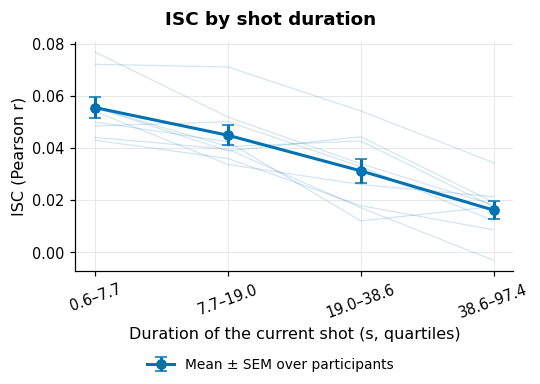

Fig05c_isc_by_shot_duration — Mean ISC for windows in short to long shots (quartiles of the current shot's
duration); faint lines are individual participants.



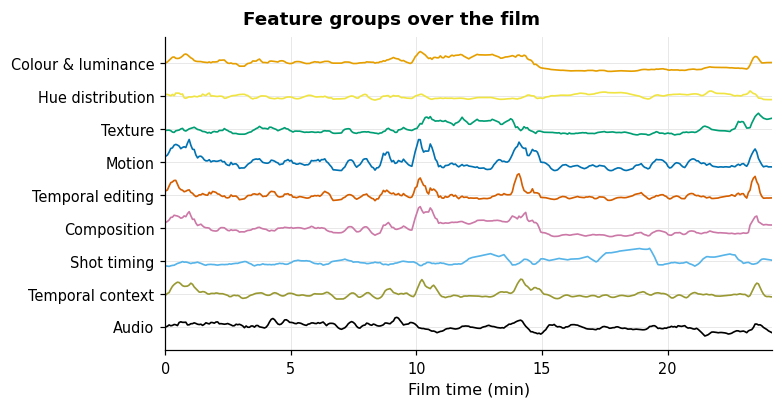

Fig06_feature_groups_timeline — Mean z-scored value of each feature group per window (5-window moving
average), stacked vertically for readability.



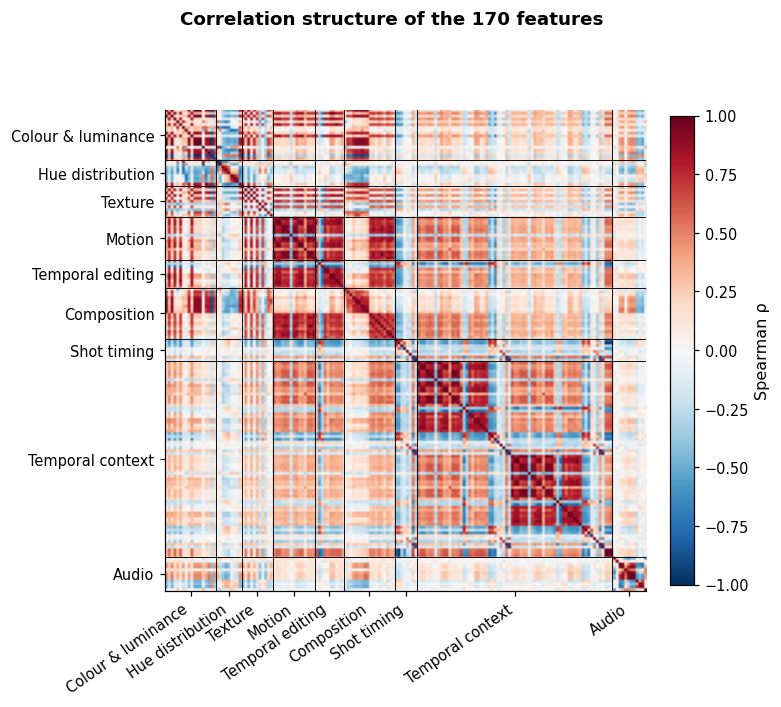

Fig07_feature_correlations — Spearman correlations between all features across windows, ordered by feature
group (black lines). Blocks of high correlation show redundancy within groups, e.g. motion and editing
features.



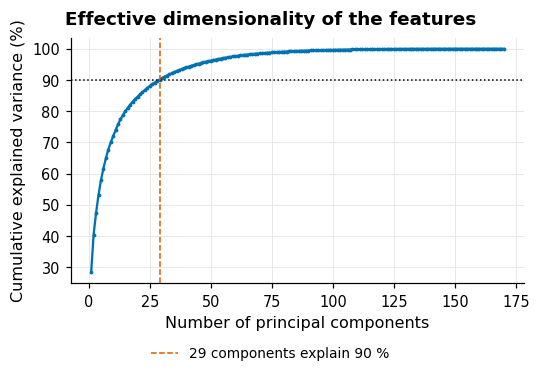

Fig08_pca_variance — Cumulative variance explained by principal components of the standardised 170 features.



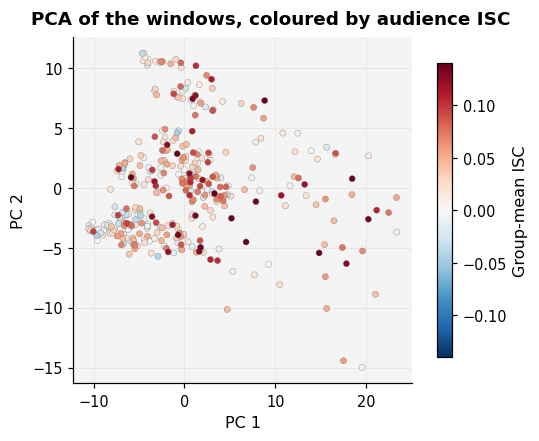

Fig09_pca_isc — One point per window (170 standardised features; unsupervised). Colour = mean ISC over
participants; high-ISC windows (red) do not form a single region of feature space.



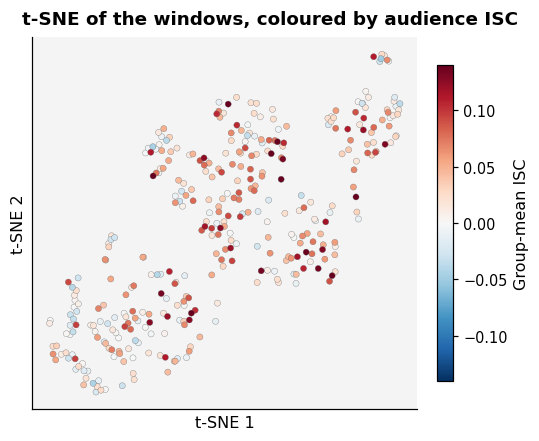

Fig10_tsne_isc — One point per window (170 standardised features; unsupervised). Colour = mean ISC over
participants; high-ISC windows (red) do not form a single region of feature space.



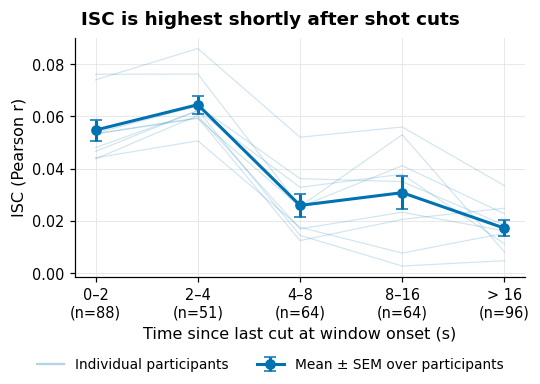

Fig11_isc_after_cuts — ISC as a function of time elapsed since the most recent cut (n = windows per bin).
Spearman ρ between group ISC and time since cut = -0.34 (descriptive; windows are autocorrelated).



In [ ]:
GLAB = {"colour_luminance": "Colour & luminance", "hue_distribution": "Hue distribution", "texture": "Texture",
        "motion": "Motion", "temporal_editing": "Temporal editing", "composition": "Composition",
        "shot_timing": "Shot timing", "temporal_context": "Temporal context", "audio": "Audio"}
GCOL = {"colour_luminance": OI["orange"], "hue_distribution": OI["yellow"], "texture": OI["green"], "motion": OI["blue"],
        "temporal_editing": OI["vermillion"], "composition": OI["purple"], "shot_timing": OI["sky"], "temporal_context": "#999933", "audio": OI["black"]}
GROUP_OF = {f: g for g, cols in GROUPS_ALL.items() for f in cols}
POS, POSC = {"0": "top", "1": "middle", "2": "bottom"}, {"0": "left", "1": "centre", "2": "right"}
HUEB = ["red–orange", "orange–yellow", "yellow–green", "green", "cyan", "blue", "violet", "magenta"]
NICE = {"lum_mean": "Mean luminance", "lum_sd": "Luminance variability", "rms_mean": "RMS contrast", "rms_sd": "Contrast variability",
        "sat_mean": "Mean saturation", "sat_sd": "Saturation variability", "hue_cos": "Hue direction (cos)",
        "hue_sin": "Hue direction (sin)", "colorful_mean": "Colourfulness", "colorful_sd": "Colourfulness variability",
        "R_mean": "Mean red", "G_mean": "Mean green", "B_mean": "Mean blue", "lab_a": "CIELAB a*", "lab_b": "CIELAB b*",
        "lum_entropy": "Luminance entropy", "dark_frac": "Dark-pixel fraction", "bright_frac": "Bright-pixel fraction",
        "warmth": "Warmth (red − blue)", "edge_mean": "Edge density", "edge_sd": "Edge-density variability",
        "sobel_mean": "Mean gradient", "sobel_sd": "Gradient variability", "lapvar_mean": "Sharpness",
        "lapvar_sd": "Sharpness variability", "hf_ratio_mean": "High/low spatial-freq. ratio",
        "hf_ratio_sd": "Spatial-freq. ratio variability", "spec_centroid": "Spatial spectral centroid",
        "lbp_entropy": "Texture entropy (LBP)", "center_surround": "Centre–surround luminance", "flow_mean": "Mean optical flow",
        "flow_sd": "Optical-flow variability", "flow_max": "Max optical flow", "flow_p90": "Optical flow (90th pct.)",
        "flow_x": "Horizontal motion", "flow_y": "Vertical motion", "flow_dir_entropy": "Motion-direction entropy",
        "moving_frac": "Moving-pixel fraction", "fdiff_mean": "Mean frame difference", "fdiff_sd": "Frame-difference variability",
        "fdiff_max": "Max frame difference", "global_motion": "Global (camera) motion", "local_motion": "Local (object) motion",
        "motion_center": "Central motion", "motion_periphery": "Peripheral motion", "n_cuts": "Number of cuts",
        "time_since_cut": "Time since last cut", "mean_shot_len": "Mean shot length", "hist_change_mean": "Mean colour change",
        "hist_change_max": "Max colour change", "lum_change_mean": "Luminance change", "lum_change_sd": "Luminance-change variability",
        "sat_change": "Saturation change", "motion_change": "Motion change", "edge_change": "Edge-density change",
        **{f"hue_h{i}": f"Hue {b}" for i, b in enumerate(HUEB)},
        **{f"lumgrid_{i}{j}": f"Luminance {POS[i]}-{POSC[j]}" for i in "012" for j in "012"},
        **{f"motgrid_{i}{j}": f"Motion {POS[i]}-{POSC[j]}" for i in "012" for j in "012"},
        "aud_rms_mean": "Audio loudness (RMS)", "aud_rms_sd": "Loudness variability", "aud_zcr": "Audio zero-crossing rate",
        "aud_centroid_mean": "Audio spectral centroid", "aud_centroid_sd": "Audio centroid variability",
        "aud_bandwidth": "Audio bandwidth", "aud_rolloff": "Audio roll-off", "aud_flatness": "Audio flatness",
        "aud_flux_mean": "Audio spectral flux", "aud_flux_sd": "Audio flux variability", "aud_onset_rate": "Audio onset rate",
        "aud_silence_frac": "Silence fraction", "shot_duration": "Shot duration", "shot_elapsed": "Time into shot",
        "shot_remaining": "Time until next cut", "shot_position": "Relative position in shot",
        "prev_shot_duration": "Previous shot duration", "next_shot_duration": "Next shot duration",
        "cut_rate_30s": "Cut rate (past 30 s)", "mean_shot_dur_30s": "Mean shot duration (past 30 s)"}
NICE.update({f"cut_kernel_{t:g}s": f"Cut-response kernel (τ = {t:g} s)" for t in CFG["CUT_KERNEL_TAUS"]})
for _f in list(NICE):
    for _L in CFG["LAG_CONTEXT_WINDOWS"]:
        NICE[f"{_f}_lag{_L}"] = f"{NICE[_f]} (−{_L} window)"
nice = lambda f: NICE.get(f, f)

X_ALL = VF.set_index("segment").loc[SEG.segment, FEATURES]
desc = X_ALL.describe().T
desc.insert(0, "group", [GROUP_OF[f] for f in desc.index])
desc.insert(1, "label", [nice(f) for f in desc.index])
save_csv(desc.reset_index().rename(columns={"index": "feature"}), "feature_descriptives")
print(desc.groupby("group").size().rename("n_features").to_string())
Zs = (X_ALL - X_ALL.mean()) / X_ALL.std()
tmin = SEG.t_start.to_numpy() / 60

# shot cuts (from the cached per-frame table)
fr_file = D["features"] / f"video_frames_{CFG['VIDEO_FPS']:g}fps_off{OFFSET:.2f}.parquet"
FRM = pd.read_parquet(fr_file, columns=["t", "hist_dist"])
med = np.nanmedian(FRM.hist_dist)
CUT_THR = med + CFG["CUT_MAD_K"] * 1.4826 * np.nanmedian(np.abs(FRM.hist_dist - med))
fig, ax = fig_ax(FULL, 2.9)
ax.plot(FRM.t / 60, FRM.hist_dist, color=OI["grey"], lw=0.4, label="Frame-to-frame colour-histogram distance")
cut = FRM.hist_dist > CUT_THR
ax.scatter(FRM.t[cut] / 60, FRM.hist_dist[cut], s=8, color=OI["vermillion"], zorder=3, label=f"Detected cut (n = {int(cut.sum())})")
ax.axhline(CUT_THR, color=OI["vermillion"], ls="--", lw=1, label="Threshold: median + 5 × MAD")
ax.set_xlabel("Film time (min)")
ax.set_ylabel("Bhattacharyya distance")
legend_below(fig, ax, 3)
save(fig, "Fig05_cut_detection", "Shot-cut detection", "Colour-histogram distance between consecutive frames (5 fps). "
     "Values above the robust threshold are detected as cuts; they define the shots used for splitting.")

fig, ax = fig_ax(HALF + 0.6, 3.3)
ax.hist(S_DUR, bins=np.logspace(np.log10(max(S_DUR.min(), 0.2)), np.log10(S_DUR.max()), 30), color=OI["sky"], edgecolor="white")
ax.set_xscale("log")
ticks_ = [t for t in [0.5, 1, 2, 5, 10, 20, 50, 100] if S_DUR.min() * 0.8 <= t <= S_DUR.max() * 1.2]
ax.set_xticks(ticks_)
ax.set_xticklabels([f"{t:g}" for t in ticks_])
ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
ax.axvline(np.median(S_DUR), color=OI["vermillion"], lw=2, label=f"Median {np.median(S_DUR):.1f} s")
ax.set_xlabel("Shot duration (s, log scale)")
ax.set_ylabel("Number of shots")
legend_below(fig, ax, 1)
save(fig, "Fig05b_shot_durations", "Distribution of shot durations", f"{len(S_DUR)} shots detected in the aligned stimulus.")

sd_bins = pd.qcut(pd.Series(X_ALL["shot_duration"].to_numpy(), index=SEG.segment), 4, duplicates="drop")
per_sd = ISCF.assign(b=ISCF.segment.map(sd_bins)).groupby(["participant", "b"], observed=True).ISC.mean().unstack()
fig, ax = fig_ax(HALF, 3.4)
for p in per_sd.index:
    ax.plot(range(per_sd.shape[1]), per_sd.loc[p], color=OI["blue"], alpha=0.18, lw=0.8)
ax.errorbar(range(per_sd.shape[1]), per_sd.mean(), yerr=per_sd.std(ddof=1) / np.sqrt(len(per_sd)), color=OI["blue"],
            marker="o", capsize=4, lw=2, label="Mean ± SEM over participants")
ax.set_xticks(range(per_sd.shape[1]))
ax.set_xticklabels([f"{iv.left:.1f}–{iv.right:.1f}" for iv in per_sd.columns], rotation=20)
ax.set_xlabel("Duration of the current shot (s, quartiles)")
ax.set_ylabel("ISC (Pearson r)")
legend_below(fig, ax, 1)
save(fig, "Fig05c_isc_by_shot_duration", "ISC by shot duration", "Mean ISC for windows in short to long shots (quartiles "
     "of the current shot's duration); faint lines are individual participants.")

# feature-group time courses
fig, ax = fig_ax(FULL, 3.6)
for i, (g, cols) in enumerate(GROUPS_ALL.items()):
    ax.plot(tmin, Zs[cols].mean(1).rolling(5, center=True, min_periods=1).mean() + 3 * (len(GROUPS_ALL) - 1 - i),
            color=GCOL[g], lw=1.1)
ax.set_yticks([3 * (len(GROUPS_ALL) - 1 - i) for i in range(len(GROUPS_ALL))])
ax.set_yticklabels([GLAB[g] for g in GROUPS_ALL])
ax.set_xlabel("Film time (min)")
ax.set_xlim(0, tmin.max())
save(fig, "Fig06_feature_groups_timeline", "Feature groups over the film", "Mean z-scored value of each feature group per "
     "window (5-window moving average), stacked vertically for readability.")

# correlation matrix (ordered by group)
C = X_ALL.corr(method="spearman")
fig, ax = fig_ax(FULL, 6.4)
im = ax.imshow(C.values, cmap="RdBu_r", vmin=-1, vmax=1)
edges = np.cumsum([len(c) for c in GROUPS_ALL.values()])
for e in edges[:-1]:
    ax.axhline(e - 0.5, color="k", lw=0.6)
    ax.axvline(e - 0.5, color="k", lw=0.6)
mids = edges - np.array([len(c) for c in GROUPS_ALL.values()]) / 2
ax.set_xticks(mids - 0.5)
ax.set_xticklabels([GLAB[g] for g in GROUPS_ALL], rotation=35, ha="right")
ax.set_yticks(mids - 0.5)
ax.set_yticklabels([GLAB[g] for g in GROUPS_ALL])
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.75).set_label("Spearman ρ")
save(fig, "Fig07_feature_correlations", f"Correlation structure of the {len(FEATURES)} features",
     "Spearman correlations between all features across windows, ordered by feature group (black lines). Blocks of high "
     "correlation show redundancy within groups, e.g. motion and editing features.")

# PCA + t-SNE coloured by group ISC
Xs_ = StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(X_ALL))
pca = PCA(random_state=CFG["SEED"]).fit(Xs_)
Zp = pca.transform(Xs_)
Zt = TSNE(2, perplexity=30, init="pca", random_state=CFG["SEED"]).fit_transform(Zp[:, :20])
gISC = grp_isc.reindex(SEG.segment).to_numpy()
cum = np.cumsum(pca.explained_variance_ratio_)
fig, ax = fig_ax(HALF, 3.3)
ax.plot(np.arange(1, len(cum) + 1), cum * 100, color=OI["blue"], marker=".", ms=3)
k90 = int(np.searchsorted(cum, 0.9) + 1)
ax.axhline(90, color="k", ls=":", lw=1)
ax.axvline(k90, color=OI["vermillion"], ls="--", lw=1, label=f"{k90} components explain 90 %")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance (%)")
legend_below(fig, ax, 1)
save(fig, "Fig08_pca_variance", "Effective dimensionality of the features", "Cumulative variance explained by principal "
     f"components of the standardised {len(FEATURES)} features.")
lim = np.nanpercentile(np.abs(gISC), 98)
order = np.argsort(np.abs(gISC))
for name, Z, lab in [("Fig09_pca_isc", Zp, ("PC 1", "PC 2")), ("Fig10_tsne_isc", Zt, ("t-SNE 1", "t-SNE 2"))]:
    fig, ax = fig_ax(HALF, 3.9)
    ax.set_facecolor("#F4F4F4")
    sc = ax.scatter(Z[order, 0], Z[order, 1], c=gISC[order], cmap="RdBu_r", vmin=-lim, vmax=lim, s=16, edgecolor="#666666", lw=0.2)
    fig.colorbar(sc, ax=ax, shrink=0.85).set_label("Group-mean ISC")
    ax.set_xlabel(lab[0])
    ax.set_ylabel(lab[1])
    if name.endswith("tsne_isc"):
        ax.set_xticks([])
        ax.set_yticks([])
    save(fig, name, f"{'PCA' if 'pca' in name else 't-SNE'} of the windows, coloured by audience ISC",
         f"One point per window ({len(FEATURES)} standardised features; unsupervised). Colour = mean ISC over participants; "
         "high-ISC windows (red) do not form a single region of feature space.")
pd.DataFrame({"segment": SEG.segment, "pc1": Zp[:, 0], "pc2": Zp[:, 1], "tsne1": Zt[:, 0], "tsne2": Zt[:, 1],
              "group_isc": gISC}).to_csv(D["results"] / "projections.csv", index=False)

# ISC after cuts
tsc = X_ALL["time_since_cut"].to_numpy()
bins, labs = [-0.1, 2, 4, 8, 16, 1e4], ["0–2", "2–4", "4–8", "8–16", "> 16"]
b = pd.cut(pd.Series(tsc, index=SEG.segment), bins, labels=labs)
per = ISCF.assign(tbin=ISCF.segment.map(b)).groupby(["participant", "tbin"], observed=True).ISC.mean().unstack().reindex(columns=labs)
fig, ax = fig_ax(HALF, 3.4)
for p in per.index:
    ax.plot(range(len(labs)), per.loc[p], color=OI["blue"], alpha=0.18, lw=0.8)
ax.errorbar(range(len(labs)), per.mean(), yerr=per.std(ddof=1) / np.sqrt(len(per)), color=OI["blue"], marker="o",
            capsize=4, lw=2, label="Mean ± SEM over participants")
ax.plot([], [], color=OI["blue"], alpha=0.3, label="Individual participants")
ax.set_xticks(range(len(labs)))
ax.set_xticklabels([f"{l}\n(n={int((b == l).sum())})" for l in labs])
ax.set_xlabel("Time since last cut at window onset (s)")
ax.set_ylabel("ISC (Pearson r)")
legend_below(fig, ax, 2)
rho = scipy.stats.spearmanr(gISC, tsc)[0]
save(fig, "Fig11_isc_after_cuts", "ISC is highest shortly after shot cuts",
     f"ISC as a function of time elapsed since the most recent cut (n = windows per bin). Spearman ρ between group ISC and "
     f"time since cut = {rho:.2f} (descriptive; windows are autocorrelated).")

### 6c. Deep visual embeddings: CLIP and DINOv2
Frozen pretrained encoders applied to frames sampled at 1 fps and averaged per window: **CLIP ViT-B/32** (512-D, L2-normalised) and **DINOv2 ViT-S/14** (384-D CLS). Cached on Drive. Individual embedding dimensions have no direct human meaning; they are evaluated through the feature-set combinations (§9).

In [ ]:
CFG.update({"EMB_FPS": 1.0, "EMB_BATCH": 32, "CLIP_MODEL": "ViT-B/32", "DINO_MODEL": "facebook/dinov2-small"})
if importlib.util.find_spec("clip") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ftfy", "regex",
                           "git+https://github.com/openai/CLIP.git"])
import torch
from PIL import Image
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def emb_frames():
    """Yield (segment_time, PIL image) at EMB_FPS over the aligned interval."""
    w, h = 448, 252
    t0 = OFFSET + T0
    cmd = ["ffmpeg", "-v", "error", "-ss", f"{t0:.3f}", "-i", str(VIDEO), "-t", f"{SEG.t_end.max() - T0:.3f}",
           "-vf", f"fps={CFG['EMB_FPS']},scale={w}:{h}", "-f", "rawvideo", "-pix_fmt", "rgb24", "-"]
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.DEVNULL)
    k = 0
    while True:
        buf = proc.stdout.read(w * h * 3)
        if len(buf) < w * h * 3:
            break
        yield T0 + k / CFG["EMB_FPS"], Image.fromarray(np.frombuffer(buf, np.uint8).reshape(h, w, 3))
        k += 1
    proc.wait()


def segment_embeddings(name, encode, dim):
    path = D["features"] / f"{name}_segments_{WTAG}.csv"
    if path.exists():
        return pd.read_csv(path)
    t = time.time()
    times, embs, buf, bt = [], [], [], []
    for ts, im in emb_frames():
        buf.append(im)
        bt.append(ts)
        if len(buf) == CFG["EMB_BATCH"]:
            embs.append(encode(buf))
            times += bt
            buf, bt = [], []
    if buf:
        embs.append(encode(buf))
        times += bt
    E, times = np.concatenate(embs), np.array(times)
    if E.shape[1] != dim or not np.isfinite(E).all():
        raise RuntimeError(f"{name}: unexpected embeddings {E.shape}")
    cols = [f"{name}_{i:03d}" for i in range(dim)]
    seg_idx = ((times - T0) // CFG["WINDOW_S"]).astype(int)
    df = pd.DataFrame(E, columns=cols).assign(segment=seg_idx)
    df = df[df.segment < N_SEG].groupby("segment", as_index=False).mean()
    df.to_csv(path, index=False)
    print(f"{name}: {len(times)} frames -> {len(df)} segments x {dim} dims on {DEVICE} ({time.time() - t:.0f} s)")
    return df


ENC = {}


@torch.no_grad()
def clip_encode(ims):
    if "clip" not in ENC:
        import clip
        ENC["clip"] = clip.load(CFG["CLIP_MODEL"], device=DEVICE, jit=False)
    model, pre = ENC["clip"]
    e = model.encode_image(torch.stack([pre(i) for i in ims]).to(DEVICE)).float()
    return (e / e.norm(dim=-1, keepdim=True)).cpu().numpy()


@torch.no_grad()
def dino_encode(ims):
    if "dino" not in ENC:
        from transformers import AutoImageProcessor, AutoModel
        ENC["dino"] = (AutoImageProcessor.from_pretrained(CFG["DINO_MODEL"]),
                       AutoModel.from_pretrained(CFG["DINO_MODEL"]).to(DEVICE).eval())
    proc, model = ENC["dino"]
    return model(**proc(images=ims, return_tensors="pt").to(DEVICE)).pooler_output.float().cpu().numpy()


CLIPF = segment_embeddings("clip", clip_encode, 512)
DINOF = segment_embeddings("dino", dino_encode, 384)
ENC.clear()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
CLIP_COLS = [c for c in CLIPF.columns if c.startswith("clip_")]
DINO_COLS = [c for c in DINOF.columns if c.startswith("dino_")]
VF = VF.drop(columns=[c for c in VF.columns if c.startswith(("clip_", "dino_"))]).merge(CLIPF, on="segment").merge(DINOF, on="segment")
print(f"Segment table: {VF.shape[0]} segments; low-level {len(VIS)}, CLIP {len(CLIP_COLS)}, DINOv2 {len(DINO_COLS)}")

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 119MiB/s]


clip: 1452 frames -> 363 segments x 512 dims on cpu (620 s)


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

dino: 1452 frames -> 363 segments x 384 dims on cpu (757 s)
Segment table: 363 segments; low-level 158, CLIP 512, DINOv2 384


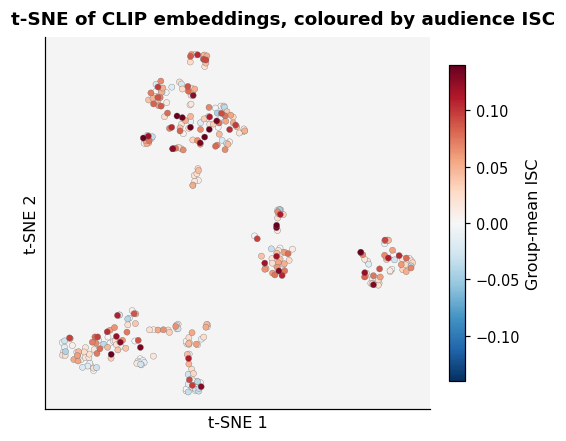

Fig11b_tsne_CLIP — One point per window (512-D CLIP embedding; 52 principal components explain 90 % of its
variance). Windows cluster by scene content; ISC varies within clusters.



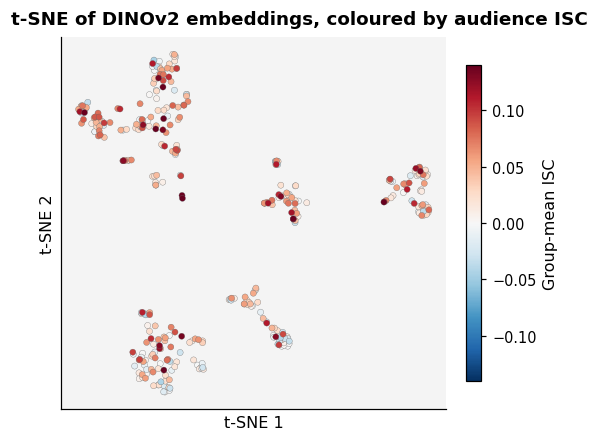

Fig11c_tsne_DINOv2 — One point per window (384-D DINOv2 embedding; 38 principal components explain 90 % of its
variance). Windows cluster by scene content; ISC varies within clusters.

CLIP: 512 dims, DINOv2: 384 dims, windows: 363


In [ ]:
X_FULL = VF.set_index("segment").loc[SEG.segment]
for name, cols in [("CLIP", CLIP_COLS), ("DINOv2", DINO_COLS)]:
    Xe = StandardScaler().fit_transform(X_FULL[cols])
    pe = PCA(random_state=CFG["SEED"]).fit(Xe)
    Ze = pe.transform(Xe)
    cum_e = np.cumsum(pe.explained_variance_ratio_)
    Te = TSNE(2, perplexity=30, init="pca", random_state=CFG["SEED"]).fit_transform(Ze[:, :20])
    fig, ax = fig_ax(HALF, 3.9)
    ax.set_facecolor("#F4F4F4")
    sc = ax.scatter(Te[order, 0], Te[order, 1], c=gISC[order], cmap="RdBu_r", vmin=-lim, vmax=lim, s=16, edgecolor="#666666", lw=0.2)
    fig.colorbar(sc, ax=ax, shrink=0.85).set_label("Group-mean ISC")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    k90e = int(np.searchsorted(cum_e, 0.9) + 1)
    save(fig, f"Fig11{'b' if name == 'CLIP' else 'c'}_tsne_{name}", f"t-SNE of {name} embeddings, coloured by audience ISC",
         f"One point per window ({len(cols)}-D {name} embedding; {k90e} principal components explain 90 % of its variance). "
         "Windows cluster by scene content; ISC varies within clusters.")
print(f"CLIP: {len(CLIP_COLS)} dims, DINOv2: {len(DINO_COLS)} dims, windows: {len(X_FULL)}")

## 7. Shots and the leakage-controlled split

**Plan (as stated before building the notebook).**

1. **Shots as the unit.** Detected cuts divide the film into shots. A window containing a cut starts a new shot; consecutive very short shots are grouped until each unit has at least `MIN_SHOT_WINDOWS` windows. A shot is never divided between train, validation and test.
2. **Chronological, interleaved blocks.** The film is divided into `N_BLOCKS` = 10 consecutive blocks (≈ 2.4 min each, at shot boundaries). Inside every block the shots are assigned **in time order**: first ≈ 60 % → train, next ≈ 20 % → validation, last ≈ 20 % → test. Training data therefore always precedes validation and test data within a block, while every part of the film contributes to every split — so slow drifts over the film cannot unbalance the classes.
3. **Balancing HIGH/LOW.** Within the allowed size tolerance (± `SPLIT_TOLERANCE`), the two boundaries of each block are placed at the shot boundaries that bring the fraction of HIGH windows in validation and test closest to 50 %. This search uses *provisional* labels (each participant's whole-session median ISC) only to position boundaries; it never touches video features.
4. **Buffers.** The first `BUFFER_WINDOWS` window after every boundary (train→val, val→test, test→next block's train) is discarded, so neighbouring, autocorrelated windows never sit on opposite sides of a split.
5. **Final labels** are **subject-wise medians**: HIGH = ISC above the participant's own median over the whole session (`LABEL_REFERENCE = "session"`; each participant is exactly balanced overall, and the same labels are used for split balancing). Labels are derived from EEG only and never enter the model inputs; set `LABEL_REFERENCE = "train"` to compute the median from training windows only.
6. Scaling and model fitting use training rows only; hyper-parameters are chosen on validation; the test set is used once.

Shots after merging: 91 (median 2 windows)
train     218
val        56
test       61
buffer     28
Checks passed: no shot is shared between train, validation and test.


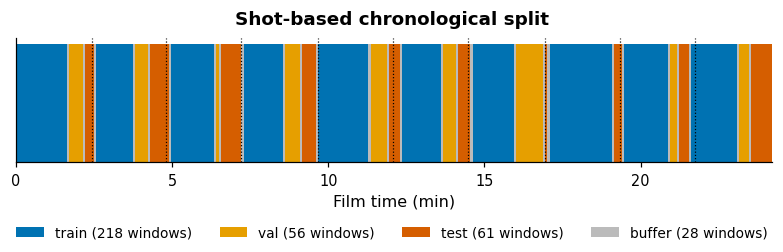

Fig12_split — Each bar is one 4-s window. Dotted lines separate the 10 blocks; within each block shots are
assigned in time order to train → validation → test, with buffer windows (grey) at every boundary.



In [ ]:
def build_shots():
    cuts = X_ALL["n_cuts"].to_numpy() > 0
    sid = np.cumsum(cuts)
    sid -= sid[0]
    s = pd.Series(sid, index=SEG.segment)
    sizes = s.value_counts().sort_index()
    remap, cur, cur_size = {}, None, 0
    for shot, size in sizes.items():                       # grow a unit until it has >= MIN_SHOT_WINDOWS windows
        if cur is None or cur_size >= CFG["MIN_SHOT_WINDOWS"]:
            cur, cur_size = shot, 0
        remap[shot] = cur
        cur_size += size
    s = s.map(remap)
    return s.map({v: i for i, v in enumerate(sorted(s.unique()))})


def provisional_high_fraction():
    piv = ISCF.pivot(index="segment", columns="participant", values="ISC").reindex(SEG.segment)
    return (piv > piv.median()).mean(1)                    # fraction of participants HIGH per window (whole-session median)


def chronological_shot_split():
    shot = build_shots()
    hf = provisional_high_fraction()
    shots = shot.groupby(shot).apply(lambda x: list(x.index))
    n_total = len(SEG)
    targets = np.linspace(0, n_total, CFG["N_BLOCKS"] + 1)
    cum = np.cumsum([len(w) for w in shots])
    block_of_shot = np.searchsorted(targets[1:-1], cum - np.array([len(w) for w in shots]) / 2)
    part = pd.Series("buffer", index=SEG.segment, dtype=object)
    fr, tol = CFG["SPLIT_FRACTIONS"], CFG["SPLIT_TOLERANCE"]
    for b in range(CFG["N_BLOCKS"]):
        bs = [w for w, bb in zip(shots, block_of_shot) if bb == b]
        if len(bs) < 3:
            for w in bs:
                part[w] = "train"
            continue
        sizes = np.array([len(w) for w in bs])
        edges = np.r_[0, np.cumsum(sizes)] / sizes.sum()   # fraction of block before each shot boundary
        best = None
        for i in range(1, len(bs) - 1):
            for j in range(i + 1, len(bs)):
                ftr, fva = edges[i], edges[j] - edges[i]
                if abs(ftr - fr[0]) > tol or abs(fva - fr[1]) > tol or abs(1 - edges[j] - fr[2]) > tol:
                    continue
                va = [x for w in bs[i:j] for x in w]
                te = [x for w in bs[j:] for x in w]
                score = abs(hf[va].mean() - 0.5) + abs(hf[te].mean() - 0.5) + 0.5 * (abs(ftr - fr[0]) + abs(fva - fr[1]))
                if best is None or score < best[0]:
                    best = (score, i, j)
        if best is None:                                   # fall back to the closest-size boundaries
            i = int(np.argmin(np.abs(edges[1:-1] - fr[0]))) + 1
            j = max(i + 1, int(np.argmin(np.abs(edges[1:-1] - fr[0] - fr[1]))) + 1)
            best = (np.nan, i, min(j, len(bs) - 1))
        _, i, j = best
        for k, w in enumerate(bs):
            name = "train" if k < i else ("val" if k < j else "test")
            for x in w:
                part[x] = name
    # buffers at every change of part (including block transitions)
    prev = None
    seq = part.copy()
    for k in SEG.segment:
        if prev is not None and seq[k] != seq[prev] and seq[prev] != "buffer":
            for q in range(k, min(k + CFG["BUFFER_WINDOWS"], SEG.segment.max() + 1)):
                part[q] = "buffer"
        prev = k
    return part, shot


SPLIT, SHOT = chronological_shot_split()
if not {"train", "val", "test"} <= set(SPLIT):
    raise RuntimeError("A split is empty — reduce N_BLOCKS or MIN_SHOT_WINDOWS.")
SPLIT_TAB = pd.DataFrame({"segment": SEG.segment, "t_start": SEG.t_start, "shot": SHOT.values, "split": SPLIT.values,
                          "block": np.searchsorted(np.linspace(0, len(SEG), CFG["N_BLOCKS"] + 1)[1:-1], SEG.segment, side="right")})
SPLIT_TAB.to_csv(D["results"] / "split_assignment.csv", index=False)
print(f"Shots after merging: {SHOT.nunique()} (median {SHOT.value_counts().median():.0f} windows)")
print(SPLIT.value_counts().reindex(["train", "val", "test", "buffer"]).to_string())
# leakage checks
for a in ["val", "test"]:
    assert not set(SHOT[SPLIT == "train"]) & set(SHOT[SPLIT == a]), "shot shared between train and " + a
assert not set(SHOT[SPLIT == "val"]) & set(SHOT[SPLIT == "test"]), "shot shared between val and test"
print("Checks passed: no shot is shared between train, validation and test.")

COL_SPLIT = {"train": OI["blue"], "val": OI["orange"], "test": OI["vermillion"], "buffer": "#BBBBBB"}
fig, ax = fig_ax(FULL, 2.2)
for p, c in COL_SPLIT.items():
    m = (SPLIT == p).to_numpy()
    ax.bar(tmin[m], 1, width=CFG["WINDOW_S"] / 60, color=c, align="edge", label=f"{p} ({m.sum()} windows)")
for e in np.linspace(0, len(SEG), CFG["N_BLOCKS"] + 1)[1:-1]:
    ax.axvline(SEG.t_start.iloc[int(e)] / 60, color="k", lw=0.8, ls=":")
ax.set_yticks([])
ax.set_xlim(0, tmin.max() + CFG["WINDOW_S"] / 60)
ax.set_xlabel("Film time (min)")
ax.grid(False)
legend_below(fig, ax, 4)
save(fig, "Fig12_split", "Shot-based chronological split", f"Each bar is one {CFG['WINDOW_S']:g}-s window. Dotted lines "
     f"separate the {CFG['N_BLOCKS']} blocks; within each block shots are assigned in time order to train → validation → test, "
     "with buffer windows (grey) at every boundary.")

## 8. CorrCA-based ISC and prediction targets

### 8a. Correlated component analysis (CorrCA)
Channel-averaged ISC (§5) mixes the few spatial patterns that viewers share with many that they do not. **Correlated component analysis** (Dmochowski et al., 2012) finds spatial filters **w** that maximise the correlation between viewers: it solves the generalised eigenproblem **R_b w = λ R_w w**, with R_w the pooled within-viewer covariance and R_b the between-viewer covariance. ISC is then computed on the first `CORRCA_K` components (per window, each viewer vs the mean of the others; averaged over components).

**Leakage control:** the CorrCA filters are estimated from **training windows only** (`SPLIT == "train"`) and then applied to all windows. The split itself (§7) was balanced with the channel-average labels, so CorrCA never influences how windows are assigned.

In [ ]:
TR = SPLIT[SPLIT == "train"].index
nW = int(round(CFG["WINDOW_S"] * FS))


def window_idx(segs):
    return np.concatenate([np.arange(int(round(SEG.set_index("segment").t_start[k] * FS)),
                                     int(round(SEG.set_index("segment").t_start[k] * FS)) + nW) for k in segs])


def corrca_fit(segs, K, reg):
    idx = window_idx(segs)
    Xs = [DATA[p][:, idx].astype(np.float64) for p in PIDS]
    Xs = [x - x.mean(1, keepdims=True) for x in Xs]
    N, S = len(idx), len(Xs)
    Rw = sum(x @ x.T for x in Xs) / N
    Xsum = sum(Xs)
    Rb = (Xsum @ Xsum.T / N - Rw) / (S - 1)
    Rw_r = Rw + reg * np.trace(Rw) / Rw.shape[0] * np.eye(Rw.shape[0])
    vals, vecs = scipy.linalg.eigh(Rb, Rw_r)
    order_ = np.argsort(vals)[::-1]
    vals, W = vals[order_], vecs[:, order_]
    A = Rw @ W @ np.linalg.pinv(W.T @ Rw @ W)            # forward models (scalp patterns)
    return vals, W[:, :K], A[:, :K]


import scipy.linalg
CC_VALS, CC_W, CC_A = corrca_fit(TR, CFG["CORRCA_K"], CFG["CORRCA_REG"])
PROJ = {p: (CC_W.T @ DATA[p]).astype(np.float32) for p in PIDS}      # K × samples
rows_cc, comp_rows = [], []
for k, t0 in zip(SEG.segment, SEG.t_start):
    s0 = int(round(t0 * FS))
    Z = {p: PROJ[p][:, s0:s0 + nW] for p in PIDS}
    Z = {p: (z - z.mean(1, keepdims=True)) / (z.std(1, keepdims=True) + 1e-12) for p, z in Z.items()}
    tot = np.sum([Z[p] for p in PIDS], axis=0)
    for p in PIDS:
        o = (tot - Z[p]) / (len(PIDS) - 1)
        o = (o - o.mean(1, keepdims=True)) / (o.std(1, keepdims=True) + 1e-12)
        r = (Z[p] * o).mean(1)                           # one ISC per component
        rows_cc.append({"participant": p, "segment": k, "ISC_corrca": float(r.mean()),
                        **{f"ISC_c{j + 1}": float(r[j]) for j in range(len(r))}})
ISCC = pd.DataFrame(rows_cc)
ISCC.to_csv(D["results"] / "isc_corrca_by_window.csv", index=False)
pivCC = ISCC.pivot(index="segment", columns="participant", values="ISC_corrca").reindex(SEG.segment)
pivAVG = ISCF.pivot(index="segment", columns="participant", values="ISC").reindex(SEG.segment)
grp_cc = pivCC.mean(1)
print(f"CorrCA eigenvalues (first 6): {np.round(CC_VALS[:6], 4)}")
print(f"Group ISC — channel average: mean {grp_isc.mean():.4f}; CorrCA (K={CFG['CORRCA_K']}): mean {grp_cc.mean():.4f}")
for part in ["train", "val", "test"]:
    s_ = SPLIT[SPLIT == part].index
    print(f"  {part:5s}: CorrCA group ISC {grp_cc[s_].mean():.4f} | channel-average {grp_isc.reindex(s_).mean():.4f}")

CorrCA eigenvalues (first 6): [0.0394 0.023  0.0204 0.019  0.016  0.0153]
Group ISC — channel average: mean 0.0369; CorrCA (K=3): mean 0.0674
  train: CorrCA group ISC 0.0735 | channel-average 0.0334
  val  : CorrCA group ISC 0.0635 | channel-average 0.0504
  test : CorrCA group ISC 0.0570 | channel-average 0.0349


### 8b. CorrCA visualisations
Component strength, scalp maps (forward models), ISC per component on training vs held-out windows, reliability of the two ISC measures, and the CorrCA ISC time course with cuts.

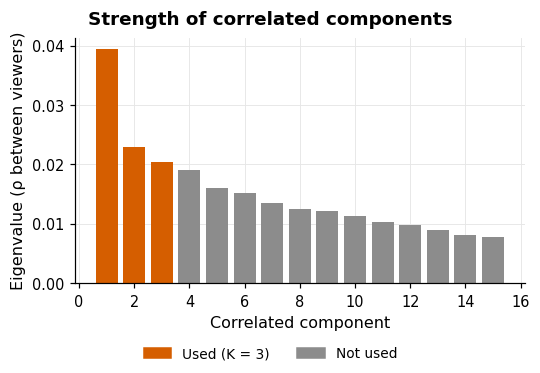

Fig13a_corrca_spectrum — Generalised eigenvalues of CorrCA fitted on training windows; the first components
capture the EEG activity most shared across viewers.



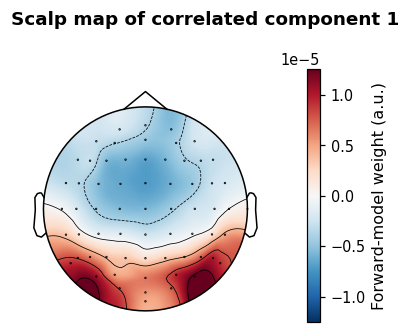

Fig13b_1_corrca_topomap_c1 — Forward model (spatial pattern) of component 1; sign is arbitrary.



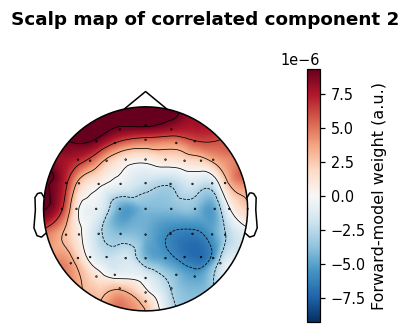

Fig13b_2_corrca_topomap_c2 — Forward model (spatial pattern) of component 2; sign is arbitrary.



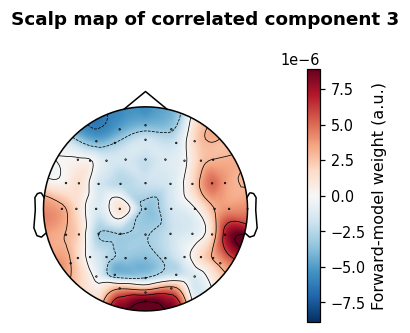

Fig13b_3_corrca_topomap_c3 — Forward model (spatial pattern) of component 3; sign is arbitrary.



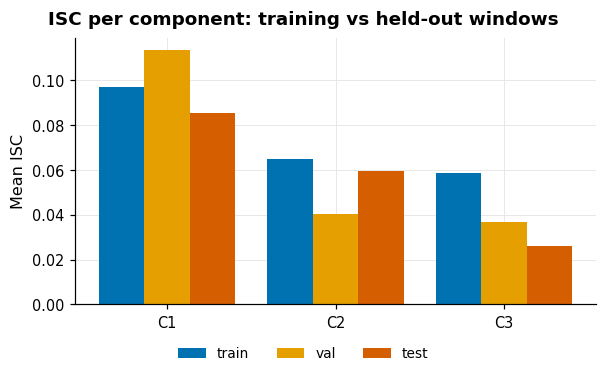

Fig13c_corrca_component_isc — Mean ISC of each correlated component in the training, validation and test
windows. Similar values on held-out windows show that the CorrCA filters generalise beyond the data they were
fitted on.



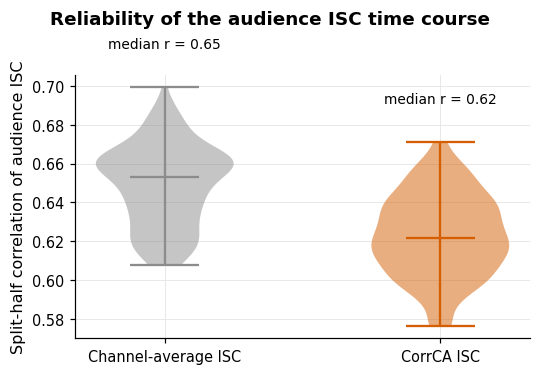

Fig13d_isc_reliability — Correlation across windows between the mean ISC of two random halves of the
participants (200 splits). Higher values mean the ISC time course is more consistent across viewers — a more
reliable prediction target.



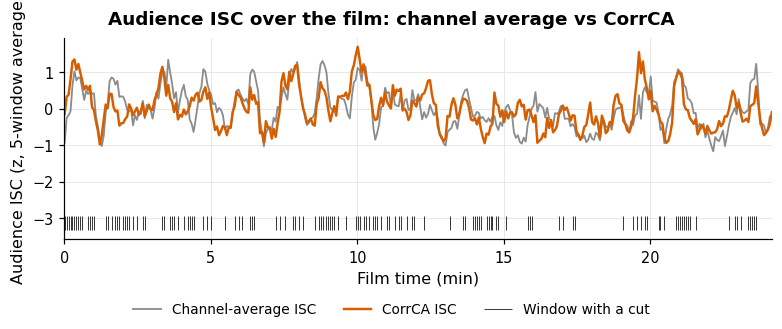

Fig13e_isc_measures_timeline — Correlation between the two time courses: r = 0.67.



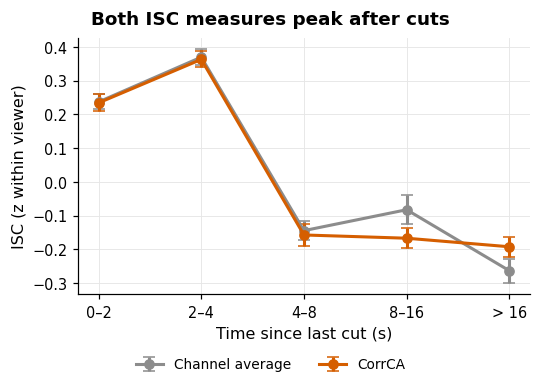

Fig13f_isc_after_cuts_both — Mean (± SEM over viewers) of z-scored ISC by time since the last cut, for
channel-average and CorrCA ISC.



In [ ]:
fig, ax = fig_ax(HALF, 3.3)
kk = min(15, len(CC_VALS))
ax.bar(np.arange(1, kk + 1), CC_VALS[:kk], color=[OI["vermillion"] if i < CFG["CORRCA_K"] else OI["grey"] for i in range(kk)])
ax.set_xlabel("Correlated component")
ax.set_ylabel("Eigenvalue (ρ between viewers)")
legend_below(fig, ax, 2, [mpl.patches.Patch(color=OI["vermillion"]), mpl.patches.Patch(color=OI["grey"])],
             [f"Used (K = {CFG['CORRCA_K']})", "Not used"])
save(fig, "Fig13a_corrca_spectrum", "Strength of correlated components", "Generalised eigenvalues of CorrCA fitted on "
     "training windows; the first components capture the EEG activity most shared across viewers.")

info = EEG[PIDS[0]].info
for j in range(CFG["CORRCA_K"]):
    fig, ax = fig_ax(3.4, 3.2)
    im, _ = mne.viz.plot_topomap(CC_A[:, j], info, axes=ax, show=False, cmap="RdBu_r")
    fig.colorbar(im, ax=ax, shrink=0.8).set_label("Forward-model weight (a.u.)")
    save(fig, f"Fig13b_{j + 1}_corrca_topomap_c{j + 1}", f"Scalp map of correlated component {j + 1}",
         f"Forward model (spatial pattern) of component {j + 1}; sign is arbitrary.")

comp = ISCC.merge(SPLIT.rename("split"), left_on="segment", right_index=True)
cm_ = comp[comp.split != "buffer"].groupby("split")[[f"ISC_c{j + 1}" for j in range(CFG["CORRCA_K"])]].mean().reindex(["train", "val", "test"])
fig, ax = fig_ax(HALF + 0.6, 3.3)
xx = np.arange(CFG["CORRCA_K"])
for i, (part, c) in enumerate([("train", OI["blue"]), ("val", OI["orange"]), ("test", OI["vermillion"])]):
    ax.bar(xx + (i - 1) * 0.27, cm_.loc[part].values, 0.27, color=c, label=part)
ax.set_xticks(xx)
ax.set_xticklabels([f"C{j + 1}" for j in xx])
ax.set_ylabel("Mean ISC")
legend_below(fig, ax, 3)
save(fig, "Fig13c_corrca_component_isc", "ISC per component: training vs held-out windows",
     "Mean ISC of each correlated component in the training, validation and test windows. Similar values on held-out "
     "windows show that the CorrCA filters generalise beyond the data they were fitted on.")

rng_ = np.random.default_rng(CFG["SEED"])
rel = []
for _ in range(200):
    perm = rng_.permutation(PIDS)
    h1, h2 = list(perm[:len(PIDS) // 2]), list(perm[len(PIDS) // 2:])
    for name, pv in [("Channel average", pivAVG), ("CorrCA", pivCC)]:
        r = scipy.stats.pearsonr(pv[h1].mean(1), pv[h2].mean(1))[0]
        rel.append({"measure": name, "split_half_r": r})
REL = pd.DataFrame(rel)
save_csv(REL.groupby("measure").split_half_r.describe().reset_index(), "isc_reliability_split_half")
fig, ax = fig_ax(HALF, 3.3)
for i, (name, c) in enumerate([("Channel average", OI["grey"]), ("CorrCA", OI["vermillion"])]):
    v = REL[REL.measure == name].split_half_r
    vp = ax.violinplot(v, positions=[i], showmedians=True)
    for body in vp["bodies"]:
        body.set_facecolor(c)
        body.set_alpha(0.5)
    for key in ("cbars", "cmins", "cmaxes", "cmedians"):
        vp[key].set_color(c)
    ax.text(i, v.max() + 0.02, f"median r = {v.median():.2f}", ha="center", fontsize=9)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Channel-average ISC", "CorrCA ISC"])
ax.set_ylabel("Split-half correlation of audience ISC")
save(fig, "Fig13d_isc_reliability", "Reliability of the audience ISC time course",
     "Correlation across windows between the mean ISC of two random halves of the participants (200 splits). Higher values "
     "mean the ISC time course is more consistent across viewers — a more reliable prediction target.")

fig, ax = fig_ax(FULL, 2.9)
z1 = (grp_isc.reindex(SEG.segment) - grp_isc.mean()) / grp_isc.std()
z2 = (grp_cc - grp_cc.mean()) / grp_cc.std()
ax.plot(tmin, z1.rolling(5, center=True, min_periods=1).mean(), color=OI["grey"], lw=1.2, label="Channel-average ISC")
ax.plot(tmin, z2.rolling(5, center=True, min_periods=1).mean(), color=OI["vermillion"], lw=1.6, label="CorrCA ISC")
y0_ = min(z1.min(), z2.min())
ax.vlines(tmin[X_ALL["n_cuts"].to_numpy() > 0], y0_ - 0.5, y0_ - 0.1, color="k", lw=0.5, label="Window with a cut")
ax.set_xlabel("Film time (min)")
ax.set_ylabel("Audience ISC (z, 5-window average)")
ax.set_xlim(0, tmin.max())
legend_below(fig, ax, 3)
save(fig, "Fig13e_isc_measures_timeline", "Audience ISC over the film: channel average vs CorrCA",
     f"Correlation between the two time courses: r = {scipy.stats.pearsonr(z1, z2)[0]:.2f}.")

bins_, labs_ = [-0.1, 2, 4, 8, 16, 1e4], ["0–2", "2–4", "4–8", "8–16", "> 16"]
bb = pd.cut(pd.Series(X_ALL["time_since_cut"].to_numpy(), index=SEG.segment), bins_, labels=labs_)
fig, ax = fig_ax(HALF, 3.4)
for name, pv, c in [("Channel average", pivAVG, OI["grey"]), ("CorrCA", pivCC, OI["vermillion"])]:
    zz = (pv - pv.mean()) / pv.std()
    per_ = zz.groupby(bb, observed=True).mean().reindex(labs_)
    ax.errorbar(range(len(labs_)), per_.mean(1), yerr=per_.std(1, ddof=1) / np.sqrt(len(PIDS)), marker="o", capsize=4,
                color=c, lw=2, label=name)
ax.set_xticks(range(len(labs_)))
ax.set_xticklabels(labs_)
ax.set_xlabel("Time since last cut (s)")
ax.set_ylabel("ISC (z within viewer)")
legend_below(fig, ax, 2)
save(fig, "Fig13f_isc_after_cuts_both", "Both ISC measures peak after cuts",
     "Mean (± SEM over viewers) of z-scored ISC by time since the last cut, for channel-average and CorrCA ISC.")

### 8c. Prediction targets and labels
Three targets are defined; all use **medians** as thresholds (`LABEL_REFERENCE`, default: whole session):

| Target | Unit | HIGH if … |
|---|---|---|
| **`audience`** (primary) | film window | the **audience (group-mean) CorrCA ISC** is above its median |
| `individual` | viewer × window | the viewer's own CorrCA ISC is above **that viewer's** median (subject-wise) |
| `individual_avg` | viewer × window | as before: channel-average ISC above the viewer's median (previous pipeline, for comparison) |

The primary target (`PRIMARY_TARGET`) drives §9–§13. LOSO (§9c) uses the individual targets, and §9d compares all three.

split            test  train    val
target                             
audience        0.443  0.528  0.500
individual      0.468  0.526  0.470
individual_avg  0.492  0.481  0.562


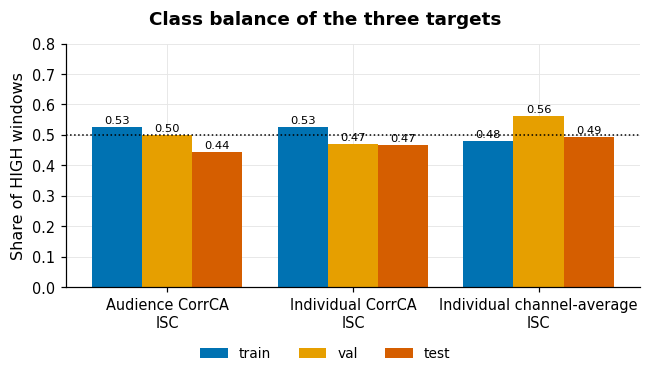

Fig14a_class_balance_targets — Fraction of windows labelled HIGH in each split (individual targets: mean over
participants).



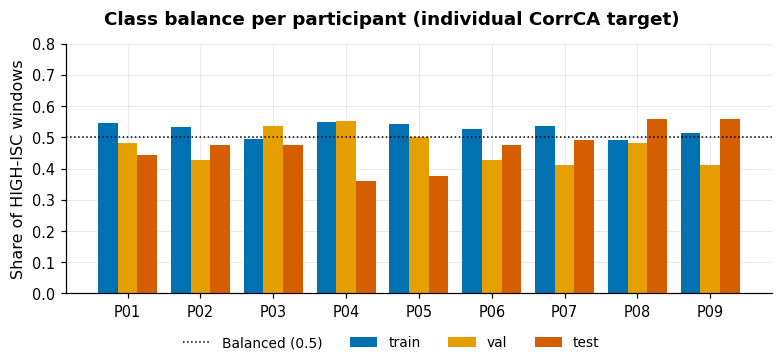

Fig14b_class_balance_individual — Fraction of windows labelled HIGH per participant and split (subject-wise
median).



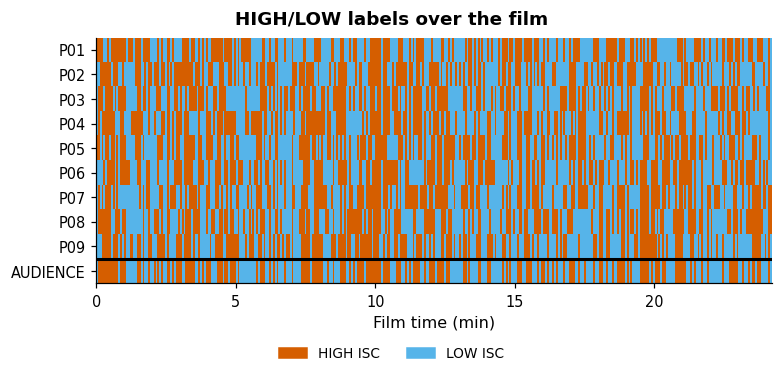

Fig14c_label_raster — Rows: each viewer's individual CorrCA label (subject-wise median) and, at the bottom,
the audience label used as the primary target.



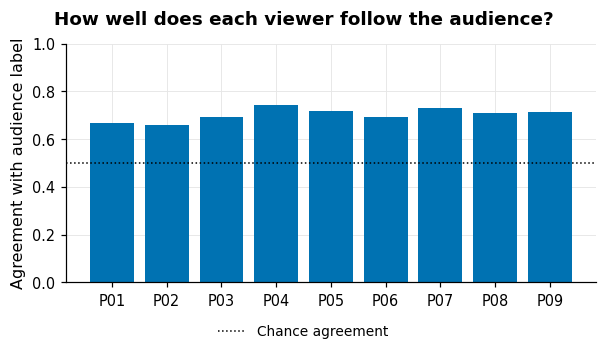

Fig14d_individual_vs_audience — Fraction of windows in which a viewer's own HIGH/LOW label equals the audience
label.

Primary target: Audience CorrCA ISC — rows: train 218, validation 56, test 61


In [ ]:
REF = SPLIT.index if CFG["LABEL_REFERENCE"] == "session" else TR
LABELS = {"audience": (grp_cc > grp_cc.loc[REF].median()).astype(int),
          "individual": (pivCC > pivCC.loc[REF].median()).astype(int),
          "individual_avg": (pivAVG > pivAVG.loc[REF].median()).astype(int)}
VALUES = {"audience": grp_cc, "individual": pivCC, "individual_avg": pivAVG}
TARGET_NAMES = {"audience": "Audience CorrCA ISC", "individual": "Individual CorrCA ISC",
                "individual_avg": "Individual channel-average ISC"}
PRIMARY = CFG["PRIMARY_TARGET"]
bal_rows = []
for t, L in LABELS.items():
    for part in ["train", "val", "test"]:
        s_ = SPLIT[SPLIT == part].index
        v = L.loc[s_]
        bal_rows.append({"target": t, "split": part, "share_high": float(np.mean(v.values))})
BAL_T = pd.DataFrame(bal_rows)
save_csv(BAL_T, "class_balance_by_target")
bal = pd.concat({p: LABELS["individual"][SPLIT == p].mean() for p in ["train", "val", "test"]}, axis=1)
bal.loc["ALL"] = bal.mean()
save_csv(bal.reset_index().rename(columns={"index": "participant"}), "class_balance_individual_by_participant")
print(BAL_T.pivot(index="target", columns="split", values="share_high").round(3).to_string())

fig, ax = fig_ax(HALF + 1, 3.3)
x = np.arange(3)
for j, (part, c) in enumerate([("train", OI["blue"]), ("val", OI["orange"]), ("test", OI["vermillion"])]):
    v = BAL_T[BAL_T.split == part].set_index("target").reindex(list(LABELS)).share_high
    b_ = ax.bar(x + (j - 1) * 0.27, v, 0.27, color=c, label=part)
    ax.bar_label(b_, fmt="%.2f", fontsize=7.5, padding=1)
ax.axhline(0.5, color="k", ls=":", lw=1)
ax.set_xticks(x)
ax.set_xticklabels([TARGET_NAMES[t].replace(" ISC", "\nISC") for t in LABELS])
ax.set_ylim(0, 0.8)
ax.set_ylabel("Share of HIGH windows")
legend_below(fig, ax, 3)
save(fig, "Fig14a_class_balance_targets", "Class balance of the three targets", "Fraction of windows labelled HIGH in each "
     "split (individual targets: mean over participants).")

fig, ax = fig_ax(FULL, 3.2)
x = np.arange(len(PIDS))
for j, (p, c) in enumerate([("train", OI["blue"]), ("val", OI["orange"]), ("test", OI["vermillion"])]):
    ax.bar(x + (j - 1) * 0.27, bal.loc[PIDS, p], 0.27, color=c, label=p)
ax.axhline(0.5, color="k", ls=":", lw=1, label="Balanced (0.5)")
ax.set_ylim(0, 0.8)
ax.set_xticks(x)
ax.set_xticklabels(PIDS)
ax.set_ylabel("Share of HIGH-ISC windows")
legend_below(fig, ax, 4)
save(fig, "Fig14b_class_balance_individual", "Class balance per participant (individual CorrCA target)",
     "Fraction of windows labelled HIGH per participant and split (subject-wise median).")

fig, ax = fig_ax(FULL, 3.3)
M_ = np.vstack([LABELS["individual"].T.values, LABELS["audience"].values[None, :]])
ax.imshow(M_, aspect="auto", cmap=mpl.colors.ListedColormap([OI["sky"], OI["vermillion"]]), interpolation="nearest",
          extent=[0, tmin.max() + CFG["WINDOW_S"] / 60, len(PIDS) + 1, 0])
ax.axhline(len(PIDS), color="k", lw=2)
ax.set_yticks(np.arange(len(PIDS) + 1) + 0.5)
ax.set_yticklabels(PIDS + ["AUDIENCE"])
ax.set_xlabel("Film time (min)")
ax.grid(False)
legend_below(fig, ax, 2, [mpl.patches.Patch(color=OI["vermillion"]), mpl.patches.Patch(color=OI["sky"])], ["HIGH ISC", "LOW ISC"])
save(fig, "Fig14c_label_raster", "HIGH/LOW labels over the film", "Rows: each viewer's individual CorrCA label "
     "(subject-wise median) and, at the bottom, the audience label used as the primary target.")

agree = pd.Series({p: (LABELS["individual"][p] == LABELS["audience"]).mean() for p in PIDS})
fig, ax = fig_ax(HALF + 0.6, 3.1)
ax.bar(agree.index, agree.values, color=OI["blue"])
ax.axhline(0.5, color="k", ls=":", lw=1, label="Chance agreement")
ax.set_ylim(0, 1)
ax.set_ylabel("Agreement with audience label")
legend_below(fig, ax, 1)
save(fig, "Fig14d_individual_vs_audience", "How well does each viewer follow the audience?",
     "Fraction of windows in which a viewer's own HIGH/LOW label equals the audience label.")

ALLCOLS = FEATURES + CLIP_COLS + DINO_COLS


def rows(part, target=None, cols=None):
    target, cols = target or PRIMARY, cols or ALLCOLS
    parts = [part] if isinstance(part, str) else list(part)
    segs = SPLIT[SPLIT.isin(parts)].index
    Xp = X_FULL.loc[segs, cols]
    L = LABELS[target]
    if target == "audience":
        return Xp.assign(participant="audience", y=L.loc[segs].to_numpy(), segment=segs).reset_index(drop=True)
    return pd.concat([Xp.assign(participant=p, y=L.loc[segs, p].to_numpy(), segment=segs) for p in PIDS], ignore_index=True)


DTR, DVA, DTE = rows("train"), rows("val"), rows("test")
print(f"Primary target: {TARGET_NAMES[PRIMARY]} — rows: train {len(DTR)}, validation {len(DVA)}, test {len(DTE)}")

## 9. Models × all feature-set combinations (raw and PCA)

**Target:** the primary target (`PRIMARY_TARGET`, default the audience CorrCA ISC). **Feature blocks:** Visual (81 low-level + 8 shot-timing + temporal context), Audio (12), CLIP (512), DINOv2 (384). **All 15 non-empty combinations** of the four blocks are evaluated, each in two variants:

* **Raw** — every block standardised;
* **PCA** — every block standardised and reduced by its own PCA keeping `PCA_VARIANCE` (95 %) of the **training** variance (fitted inside the pipeline, so validation/test data never influence it).

Each combination × variant is run with five models (logistic regression, SVM, random forest, XGBoost, MLP): **15 × 2 × 5 = 150 configurations**. For each configuration, the hyper-parameters are chosen on **validation** (ROC-AUC, ties by balanced accuracy) and the selected model is evaluated **once on test**, with 95 % shot-bootstrap confidence intervals, per-participant scores and a Wilcoxon test against chance. A stratified dummy classifier is the chance reference. Results are saved after every configuration and re-used on re-runs (`results/combination_results_test.csv`).

In [ ]:
CFG.update({"PCA_VARIANCE": 0.95})
BLOCKS = {"Visual": VIS, "Audio": AUDIO if AF is not None else [], "CLIP": CLIP_COLS, "DINOv2": DINO_COLS}
BLOCKS = {k: v for k, v in BLOCKS.items() if v}
BCOL = {"Visual": OI["blue"], "Audio": OI["black"], "CLIP": OI["orange"], "DINOv2": OI["purple"]}
COMBOS = [c for r in range(1, len(BLOCKS) + 1) for c in itertools.combinations(BLOCKS, r)]
cname = lambda c: " + ".join(c)
GRIDS = {
    "logreg": (lambda **p: LogisticRegression(max_iter=4000, class_weight="balanced", **p), {"C": [0.01, 0.1, 1.0]}),
    "svm": (lambda **p: SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=CFG["SEED"], **p),
            {"C": [0.1, 1.0, 10.0]}),
    "rf": (lambda **p: RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight="balanced", n_jobs=-1,
                                              random_state=CFG["SEED"], **p), {"max_depth": [4, 8, None]}),
    "xgb": (lambda **p: XGBClassifier(n_estimators=300, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                                      eval_metric="logloss", n_jobs=-1, random_state=CFG["SEED"], **p), {"max_depth": [2, 3, 4]}),
    "mlp": (lambda **p: MLPClassifier(hidden_layer_sizes=(64, 32), early_stopping=True, max_iter=800,
                                      random_state=CFG["SEED"], **p), {"alpha": [1e-3, 1e-2, 1e-1]}),
}
MODEL_NAMES = {"logreg": "Logistic regression", "svm": "SVM (RBF)", "rf": "Random forest", "xgb": "XGBoost", "mlp": "MLP"}
MODES = ["raw", "pca"]


def build(model, combo, mode, params):
    tr = []
    for b in combo:
        steps = [("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]
        if mode == "pca":
            steps.append(("pca", PCA(n_components=CFG["PCA_VARIANCE"], svd_solver="full", random_state=CFG["SEED"])))
        tr.append((b, Pipeline(steps), BLOCKS[b]))
    return Pipeline([("prep", ColumnTransformer(tr)), ("clf", GRIDS[model][0](**params))])


def cols_of(combo):
    return [f for b in combo for f in BLOCKS[b]]


def fit_cfg(model, combo, mode, params, dtr):
    return build(model, combo, mode, params).fit(dtr[cols_of(combo)], dtr.y)


def metrics(y, p, thr=0.5):
    pred = (p >= thr).astype(int)
    both = len(np.unique(y)) == 2
    return {"balanced_accuracy": balanced_accuracy_score(y, pred) if both else np.nan,
            "roc_auc": roc_auc_score(y, p) if both else np.nan, "pr_auc": average_precision_score(y, p) if both else np.nan,
            "f1": f1_score(y, pred, zero_division=0), "accuracy": accuracy_score(y, pred), "brier": brier_score_loss(y, p)}


def per_participant(d, p):
    """Per-viewer scores. For the audience target, the audience-model predictions are compared with each viewer's own
    (individual CorrCA) labels on the same windows."""
    if (d.participant == "audience").all():
        return pd.DataFrame([{"participant": pid, **metrics(LABELS["individual"].loc[d.segment, pid].to_numpy(), p)}
                             for pid in PIDS])
    return pd.DataFrame([{"participant": pid, **metrics(g.y.to_numpy(), p[g.index])} for pid, g in d.groupby("participant")])


def shot_bootstrap(d, p, n=CFG["N_BOOT"]):
    rng = np.random.default_rng(CFG["SEED"])
    shot_ids = SHOT.reindex(d.segment).to_numpy()
    uniq = np.unique(shot_ids)
    idx_by = {s: np.where(shot_ids == s)[0] for s in uniq}
    ba, auc = [], []
    for _ in range(n):
        idx = np.concatenate([idx_by[s] for s in rng.choice(uniq, len(uniq))])
        y, q = d.y.to_numpy()[idx], p[idx]
        if len(np.unique(y)) == 2:
            ba.append(balanced_accuracy_score(y, (q >= 0.5).astype(int)))
            auc.append(roc_auc_score(y, q))
    if not ba:
        return np.array([np.nan, np.nan]), np.array([np.nan, np.nan])
    return np.percentile(ba, [2.5, 97.5]), np.percentile(auc, [2.5, 97.5])


RES_FILE, TUNE_FILE = D["results"] / "combination_results_test.csv", D["results"] / "combination_tuning_validation.csv"
PRED_DIR = D["results"] / "test_predictions"
PRED_DIR.mkdir(exist_ok=True)
RES_DF = pd.read_csv(RES_FILE) if RES_FILE.exists() else pd.DataFrame()
TUNE_DF = pd.read_csv(TUNE_FILE) if TUNE_FILE.exists() else pd.DataFrame()
n_cfg = len(COMBOS) * len(MODES) * len(CFG["MODELS"])
print(f"{len(COMBOS)} combinations × {len(MODES)} variants × {len(CFG['MODELS'])} models = {n_cfg} configurations")
t_all = time.time()
for combo in COMBOS:
    for mode in MODES:
        for model in CFG["MODELS"]:
            cid = f"{cname(combo)}|{mode}|{model}"
            if len(RES_DF) and (RES_DF.config == cid).any():
                continue
            grid, best = GRIDS[model][1], None
            for vals in product(*grid.values()):
                params = dict(zip(grid, vals))
                m = fit_cfg(model, combo, mode, params, DTR)
                pv = m.predict_proba(DVA[cols_of(combo)])[:, 1]
                mv = metrics(DVA.y.to_numpy(), pv)
                TUNE_DF = pd.concat([TUNE_DF, pd.DataFrame([{"config": cid, "params": json.dumps(params),
                                                             **{f"val_{k}": v for k, v in mv.items()}}])], ignore_index=True)
                if best is None or (mv["roc_auc"], mv["balanced_accuracy"]) > best[0]:
                    best = ((mv["roc_auc"], mv["balanced_accuracy"]), params, m)
            (vauc, vba), params, m = best
            pt = m.predict_proba(DTE[cols_of(combo)])[:, 1]
            np.save(PRED_DIR / f"{cid.replace('|', '__').replace(' + ', '+')}.npy", pt)
            mt = metrics(DTE.y.to_numpy(), pt)
            (blo, bhi), (alo, ahi) = shot_bootstrap(DTE, pt)
            pp = per_participant(DTE, pt)
            ncomp = {b: int(m.named_steps["prep"].named_transformers_[b].named_steps["pca"].n_components_)
                     for b in combo} if mode == "pca" else {b: len(BLOCKS[b]) for b in combo}
            row = {"config": cid, "combination": cname(combo), "n_blocks": len(combo), "mode": mode, "model": model,
                   "best_params": json.dumps(params), "dims_after_reduction": json.dumps(ncomp),
                   "n_model_inputs": sum(ncomp.values()), "val_roc_auc": vauc, "val_balanced_accuracy": vba,
                   **{f"test_{k}": v for k, v in mt.items()}, "test_ba_ci95_low": blo, "test_ba_ci95_high": bhi,
                   "test_auc_ci95_low": alo, "test_auc_ci95_high": ahi,
                   "participants_above_chance": int((pp.balanced_accuracy > 0.5).sum()),
                   "wilcoxon_p_vs_0.5": scipy.stats.wilcoxon(pp.balanced_accuracy - 0.5, alternative="greater").pvalue}
            RES_DF = pd.concat([RES_DF, pd.DataFrame([row])], ignore_index=True)
            RES_DF.to_csv(RES_FILE, index=False)
            TUNE_DF.to_csv(TUNE_FILE, index=False)
            print(f"{cid:45s} val AUC {vauc:.3f} | TEST BA {mt['balanced_accuracy']:.3f} [{blo:.3f}, {bhi:.3f}] "
                  f"AUC {mt['roc_auc']:.3f} | inputs {sum(ncomp.values())}")
print(f"All configurations done ({(time.time() - t_all) / 60:.1f} min this session)")
PRED = {r.config: np.load(PRED_DIR / f"{r.config.replace('|', '__').replace(' + ', '+')}.npy") for r in RES_DF.itertuples()}
dummy = DummyClassifier(strategy="stratified", random_state=CFG["SEED"]).fit(DTR[FEATURES], DTR.y)
DUMMY = metrics(DTE.y.to_numpy(), dummy.predict_proba(DTE[FEATURES])[:, 1])
PP = pd.concat([per_participant(DTE, PRED[c]).assign(config=c) for c in RES_DF.config], ignore_index=True)
save_csv(PP, "combination_per_participant_test")
RANK = RES_DF.sort_values(["val_roc_auc", "val_balanced_accuracy"], ascending=False).config.tolist()
TOP = RANK[:2]
LABEL = {r.config: f"{MODEL_NAMES[r.model]} · {r.combination} · {'PCA' if r.mode == 'pca' else 'raw'}" for r in RES_DF.itertuples()}
print(f"\nChance (stratified dummy): test BA {DUMMY['balanced_accuracy']:.3f}")
print("Top configurations by VALIDATION AUC:\n" + "\n".join(f"  {i + 1}. {LABEL[c]}" for i, c in enumerate(RANK[:5])))
show = ["combination", "mode", "model", "n_model_inputs", "val_roc_auc", "test_balanced_accuracy", "test_ba_ci95_low",
        "test_ba_ci95_high", "test_roc_auc", "participants_above_chance"]
print(RES_DF.sort_values("val_roc_auc", ascending=False)[show].head(20).round(3).to_string(index=False))

15 combinations × 2 variants × 5 models = 150 configurations
Visual|raw|logreg                             val AUC 0.684 | TEST BA 0.491 [0.355, 0.577] AUC 0.556 | inputs 158
Visual|raw|svm                                val AUC 0.705 | TEST BA 0.414 [0.313, 0.496] AUC 0.472 | inputs 158
Visual|raw|rf                                 val AUC 0.722 | TEST BA 0.590 [0.470, 0.675] AUC 0.566 | inputs 158
Visual|raw|xgb                                val AUC 0.662 | TEST BA 0.542 [0.414, 0.655] AUC 0.557 | inputs 158
Visual|raw|mlp                                val AUC 0.654 | TEST BA 0.557 [0.421, 0.658] AUC 0.545 | inputs 158
Visual|pca|logreg                             val AUC 0.713 | TEST BA 0.472 [0.347, 0.554] AUC 0.491 | inputs 34
Visual|pca|svm                                val AUC 0.731 | TEST BA 0.436 [0.349, 0.537] AUC 0.456 | inputs 34
Visual|pca|rf                                 val AUC 0.721 | TEST BA 0.491 [0.395, 0.566] AUC 0.469 | inputs 34
Visual|pca|xgb                

/usr/local/lib/python3.13/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


Audio + CLIP|pca|svm                          val AUC 0.511 | TEST BA 0.500 [0.500, 0.500] AUC 0.670 | inputs 65
Audio + CLIP|pca|rf                           val AUC 0.495 | TEST BA 0.418 [0.336, 0.518] AUC 0.338 | inputs 65
Audio + CLIP|pca|xgb                          val AUC 0.436 | TEST BA 0.447 [0.344, 0.566] AUC 0.345 | inputs 65
Audio + CLIP|pca|mlp                          val AUC 0.541 | TEST BA 0.465 [0.331, 0.612] AUC 0.429 | inputs 65
Audio + DINOv2|raw|logreg                     val AUC 0.608 | TEST BA 0.483 [0.312, 0.621] AUC 0.502 | inputs 396
Audio + DINOv2|raw|svm                        val AUC 0.543 | TEST BA 0.437 [0.357, 0.519] AUC 0.435 | inputs 396
Audio + DINOv2|raw|rf                         val AUC 0.547 | TEST BA 0.444 [0.359, 0.561] AUC 0.293 | inputs 396
Audio + DINOv2|raw|xgb                        val AUC 0.526 | TEST BA 0.392 [0.275, 0.533] AUC 0.357 | inputs 396
Audio + DINOv2|raw|mlp                        val AUC 0.601 | TEST BA 0.491 [0.408, 0.583] A

/usr/local/lib/python3.13/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


Audio + CLIP + DINOv2|pca|svm                 val AUC 0.511 | TEST BA 0.500 [0.500, 0.500] AUC 0.674 | inputs 111
Audio + CLIP + DINOv2|pca|rf                  val AUC 0.499 | TEST BA 0.388 [0.313, 0.478] AUC 0.294 | inputs 111
Audio + CLIP + DINOv2|pca|xgb                 val AUC 0.476 | TEST BA 0.422 [0.311, 0.515] AUC 0.359 | inputs 111
Audio + CLIP + DINOv2|pca|mlp                 val AUC 0.473 | TEST BA 0.374 [0.293, 0.500] AUC 0.342 | inputs 111
Visual + Audio + CLIP + DINOv2|raw|logreg     val AUC 0.588 | TEST BA 0.475 [0.373, 0.582] AUC 0.427 | inputs 1066
Visual + Audio + CLIP + DINOv2|raw|svm        val AUC 0.554 | TEST BA 0.392 [0.337, 0.467] AUC 0.371 | inputs 1066
Visual + Audio + CLIP + DINOv2|raw|rf         val AUC 0.651 | TEST BA 0.454 [0.323, 0.562] AUC 0.460 | inputs 1066
Visual + Audio + CLIP + DINOv2|raw|xgb        val AUC 0.654 | TEST BA 0.377 [0.310, 0.440] AUC 0.394 | inputs 1066
Visual + Audio + CLIP + DINOv2|raw|mlp        val AUC 0.636 | TEST BA 0.472 [0.285, 

### 9b. Visualising the combination results
Heatmap of every configuration, the best model per combination (raw vs PCA), the effect of PCA, the marginal contribution of each feature block, and the dimensionality retained by PCA.

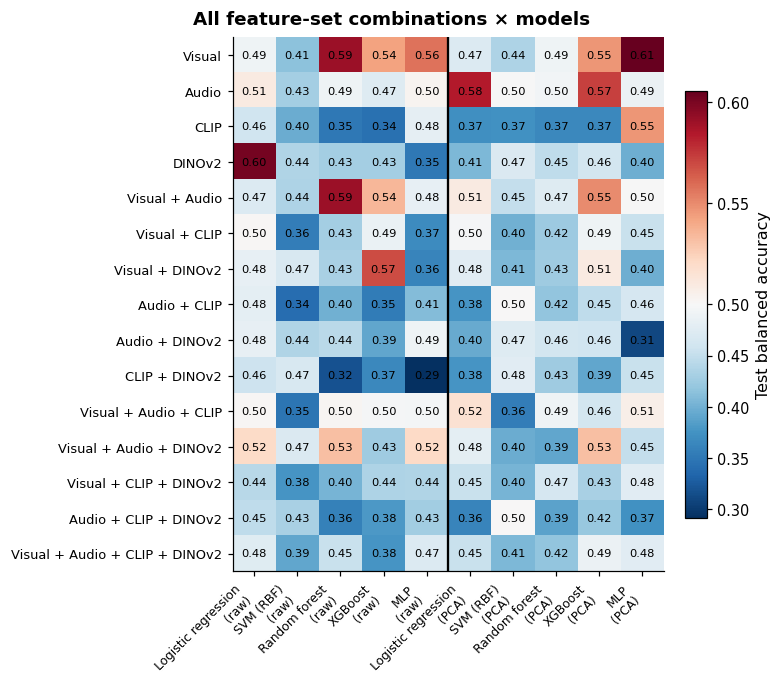

Fig15_combination_heatmap — Test balanced accuracy of all 150 configurations: 15 combinations of the Visual,
Audio, CLIP and DINOv2 blocks (rows) × 5 models with raw or PCA-reduced blocks (columns). Hyper-parameters
were chosen on validation.



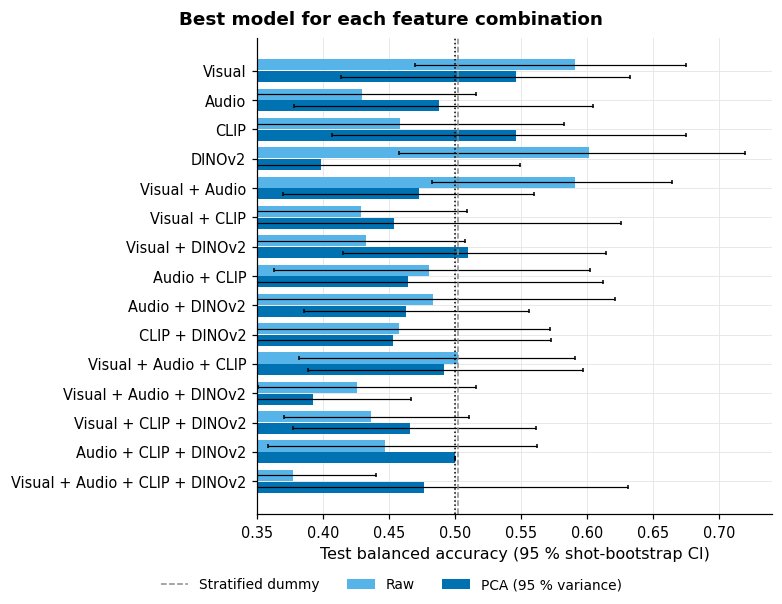

Fig16_best_per_combination — For every combination and variant, the model with the highest validation ROC-AUC
is shown with its test balanced accuracy and 95 % confidence interval.



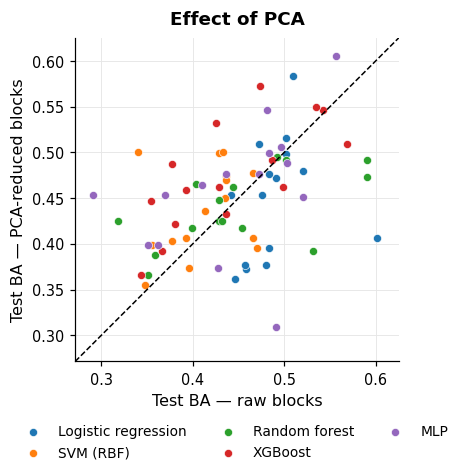

Fig17_pca_effect — Each point is one combination × model. Points above the diagonal improved with PCA (mean
change +0.005).



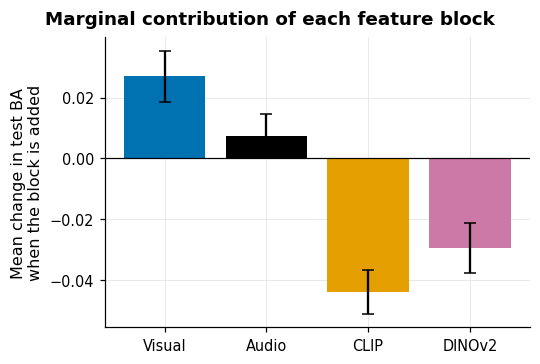

Fig18_block_contribution — Average change in test balanced accuracy when a block is added to any combination
that lacks it (over all combinations, models and variants; error bars = SEM).



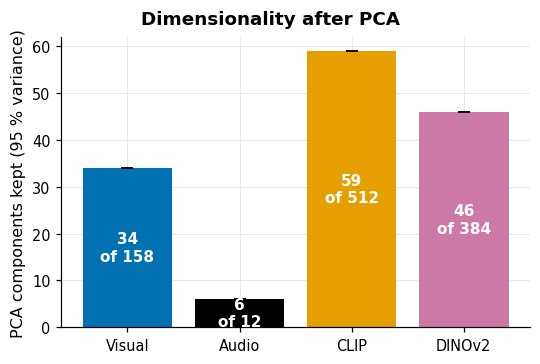

Fig19_pca_dimensions — Number of principal components retained per block (median, range over configurations),
fitted on training data only.



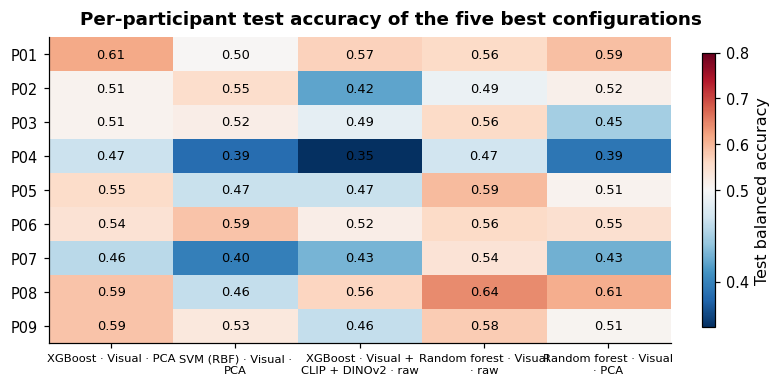

Fig20_top5_per_participant — Configurations ranked by validation ROC-AUC; rows are participants.



In [ ]:
combo_order = [cname(c) for c in COMBOS]
colmap = [(m, md_) for md_ in MODES for m in CFG["MODELS"]]
H = np.full((len(combo_order), len(colmap)), np.nan)
for r in RES_DF.itertuples():
    H[combo_order.index(r.combination), colmap.index((r.model, r.mode))] = r.test_balanced_accuracy
fig, ax = fig_ax(FULL, 6.2)
im = ax.imshow(H, cmap="RdBu_r", norm=mpl.colors.TwoSlopeNorm(vmin=min(0.4, np.nanmin(H)), vcenter=0.5,
                                                               vmax=max(0.6, np.nanmax(H))), aspect="auto")
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        ax.text(j, i, f"{H[i, j]:.2f}", ha="center", va="center", fontsize=7.5)
ax.axvline(len(CFG["MODELS"]) - 0.5, color="k", lw=1.5)
ax.set_xticks(range(len(colmap)))
ax.set_xticklabels([f"{MODEL_NAMES[m]}\n({'PCA' if md_ == 'pca' else 'raw'})" for m, md_ in colmap], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(combo_order)))
ax.set_yticklabels(combo_order, fontsize=8.5)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8).set_label("Test balanced accuracy")
save(fig, "Fig15_combination_heatmap", "All feature-set combinations × models",
     "Test balanced accuracy of all 150 configurations: 15 combinations of the Visual, Audio, CLIP and DINOv2 blocks "
     "(rows) × 5 models with raw or PCA-reduced blocks (columns). Hyper-parameters were chosen on validation.")

bestc = RES_DF.sort_values("val_roc_auc", ascending=False).groupby(["combination", "mode"]).head(1).set_index(["combination", "mode"])
fig, ax = fig_ax(FULL, 5.4)
y = np.arange(len(combo_order))[::-1]
for k, (md_, c) in enumerate([("raw", OI["sky"]), ("pca", OI["blue"])]):
    d = bestc.xs(md_, level="mode").reindex(combo_order)
    ax.barh(y + (0.2 if md_ == "raw" else -0.2), d.test_balanced_accuracy, 0.38, color=c,
            xerr=[d.test_balanced_accuracy - d.test_ba_ci95_low, d.test_ba_ci95_high - d.test_balanced_accuracy],
            capsize=1.5, error_kw=dict(lw=0.8), label="Raw" if md_ == "raw" else "PCA (95 % variance)")
ax.axvline(0.5, color="k", ls=":", lw=1)
ax.axvline(DUMMY["balanced_accuracy"], color=OI["grey"], ls="--", lw=1, label="Stratified dummy")
ax.set_yticks(y)
ax.set_yticklabels(combo_order)
ax.set_xlim(max(0.35, np.nanmin([bestc.test_ba_ci95_low.min(), bestc.test_balanced_accuracy.min()]) - 0.02),
            np.nanmax([bestc.test_ba_ci95_high.max(), bestc.test_balanced_accuracy.max()]) + 0.02)
ax.set_xlabel("Test balanced accuracy (95 % shot-bootstrap CI)")
legend_below(fig, ax, 3)
save(fig, "Fig16_best_per_combination", "Best model for each feature combination",
     "For every combination and variant, the model with the highest validation ROC-AUC is shown with its test balanced "
     "accuracy and 95 % confidence interval.")

pr = RES_DF.pivot_table(index=["combination", "model"], columns="mode", values="test_balanced_accuracy").dropna()
fig, ax = fig_ax(HALF, 4.2)
for m in CFG["MODELS"]:
    d = pr.xs(m, level="model")
    ax.scatter(d["raw"], d["pca"], s=28, label=MODEL_NAMES[m], edgecolor="white", lw=0.4)
lo_, hi_ = pr.min().min() - 0.02, pr.max().max() + 0.02
ax.plot([lo_, hi_], [lo_, hi_], "k--", lw=1)
ax.set_xlim(lo_, hi_)
ax.set_ylim(lo_, hi_)
ax.set_aspect("equal")
ax.set_xlabel("Test BA — raw blocks")
ax.set_ylabel("Test BA — PCA-reduced blocks")
legend_below(fig, ax, 3)
save(fig, "Fig17_pca_effect", "Effect of PCA", f"Each point is one combination × model. Points above the diagonal improved "
     f"with PCA (mean change {(pr['pca'] - pr['raw']).mean():+.3f}).")

contrib = []
for b in BLOCKS:
    for md_ in MODES:
        for m in CFG["MODELS"]:
            r = RES_DF[(RES_DF["mode"] == md_) & (RES_DF.model == m)].set_index("combination").test_balanced_accuracy
            for c in COMBOS:
                if b in c or not c:
                    continue
                with_b = cname(tuple(x for x in BLOCKS if x in c or x == b))
                if cname(c) in r and with_b in r:
                    contrib.append({"block": b, "mode": md_, "model": m, "delta": r[with_b] - r[cname(c)]})
CON = pd.DataFrame(contrib)
save_csv(CON, "block_marginal_contributions")
s = CON.groupby("block").delta.agg(["mean", "sem"]).reindex(list(BLOCKS))
fig, ax = fig_ax(HALF, 3.2)
ax.bar(s.index, s["mean"], yerr=s["sem"], color=[BCOL[b] for b in s.index], capsize=4)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("Mean change in test BA\nwhen the block is added")
save(fig, "Fig18_block_contribution", "Marginal contribution of each feature block",
     "Average change in test balanced accuracy when a block is added to any combination that lacks it (over all "
     "combinations, models and variants; error bars = SEM).")

dims = RES_DF[RES_DF["mode"] == "pca"].dims_after_reduction.map(json.loads)
dd = pd.DataFrame([{"block": b, "components": n} for x in dims for b, n in x.items()])
fig, ax = fig_ax(HALF, 3.2)
g_ = dd.groupby("block").components.agg(["median", "min", "max"]).reindex(list(BLOCKS))
ax.bar(g_.index, g_["median"], color=[BCOL[b] for b in g_.index],
       yerr=[g_["median"] - g_["min"], g_["max"] - g_["median"]], capsize=4)
for i, (b, r) in enumerate(g_.iterrows()):
    ax.text(i, r["median"] / 2, f"{int(r['median'])}\nof {len(BLOCKS[b])}", ha="center", va="center", color="white", fontweight="bold")
ax.set_ylabel("PCA components kept (95 % variance)")
save(fig, "Fig19_pca_dimensions", "Dimensionality after PCA", "Number of principal components retained per block "
     "(median, range over configurations), fitted on training data only.")

fig, ax = fig_ax(FULL, 3.4)
Mx = PP[PP.config.isin(RANK[:5])].pivot(index="participant", columns="config", values="balanced_accuracy")[RANK[:5]]
im = ax.imshow(Mx.values, cmap="RdBu_r", norm=mpl.colors.TwoSlopeNorm(vmin=0.35, vcenter=0.5, vmax=0.8), aspect="auto")
for i in range(Mx.shape[0]):
    for j in range(Mx.shape[1]):
        ax.text(j, i, f"{Mx.values[i, j]:.2f}", ha="center", va="center", fontsize=8.5)
ax.set_xticks(range(Mx.shape[1]))
ax.set_xticklabels([textwrap.fill(LABEL[c], 22) for c in Mx.columns], fontsize=7.5)
ax.set_yticks(range(len(Mx)))
ax.set_yticklabels(Mx.index)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.9).set_label("Test balanced accuracy")
save(fig, "Fig20_top5_per_participant", "Per-participant test accuracy of the five best configurations",
     "Configurations ranked by validation ROC-AUC; rows are participants.")

## 9c. Leave-one-subject-out (LOSO) evaluation — individual targets
Tests generalisation to **new viewers**, which requires viewer-level labels, so LOSO uses the **individual** targets (CorrCA and, for comparison, channel-average ISC). For each participant the model is trained on the others and tested on the held-out participant, with the hyper-parameters selected on validation in §9 (no re-tuning):

| Variant | Train on | Test on | Question |
|---|---|---|---|
| **LOSO — same film** | all windows of the other participants | all windows of the held-out participant | a new viewer, film moments already seen (labelled by others) |
| **LOSO — unseen film** (strict) | the others' **train** windows | the held-out participant's **test** windows | a new viewer **and** new film moments — the main generalisation test |

Evaluated for the `LOSO_TOP_K` configurations with the highest validation ROC-AUC plus the primary interpretable configuration (best Visual + Audio raw model). Mean ± SD over held-out participants and a one-sided Wilcoxon test against 0.5.

individual      XGBoost · Visual · PCA                             LOSO — same film     BA 0.632 ± 0.024 | 9/9 > 0.5
individual      XGBoost · Visual · PCA                             LOSO — unseen film   BA 0.516 ± 0.072 | 5/9 > 0.5
individual      SVM (RBF) · Visual · PCA                           LOSO — same film     BA 0.631 ± 0.025 | 9/9 > 0.5
individual      SVM (RBF) · Visual · PCA                           LOSO — unseen film   BA 0.456 ± 0.061 | 2/9 > 0.5
individual      XGBoost · Visual + CLIP + DINOv2 · raw             LOSO — same film     BA 0.644 ± 0.024 | 9/9 > 0.5
individual      XGBoost · Visual + CLIP + DINOv2 · raw             LOSO — unseen film   BA 0.510 ± 0.075 | 5/9 > 0.5
individual      Random forest · Visual · raw                       LOSO — same film     BA 0.617 ± 0.019 | 9/9 > 0.5
individual      Random forest · Visual · raw                       LOSO — unseen film   BA 0.560 ± 0.047 | 9/9 > 0.5
individual      Random forest · Visual · PCA                    

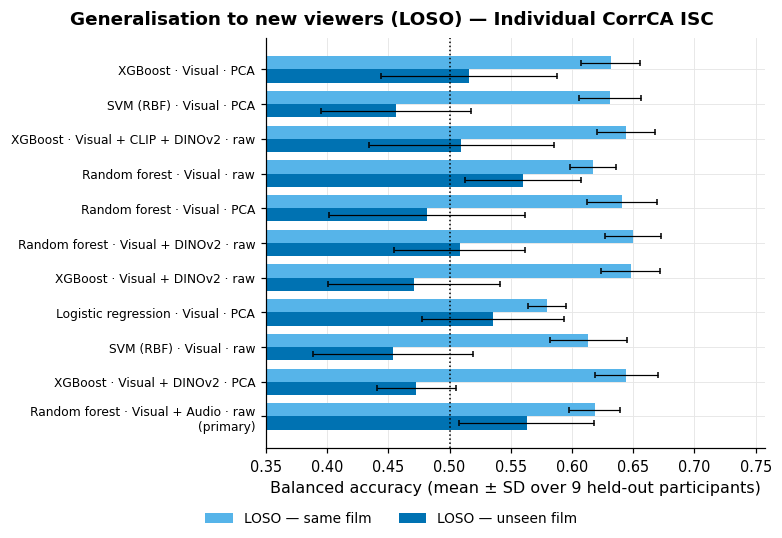

Fig20b_loso_individual — Top configurations (validation ranking) and the primary interpretable configuration:
LOSO with the same film (light) and with unseen film moments (dark).



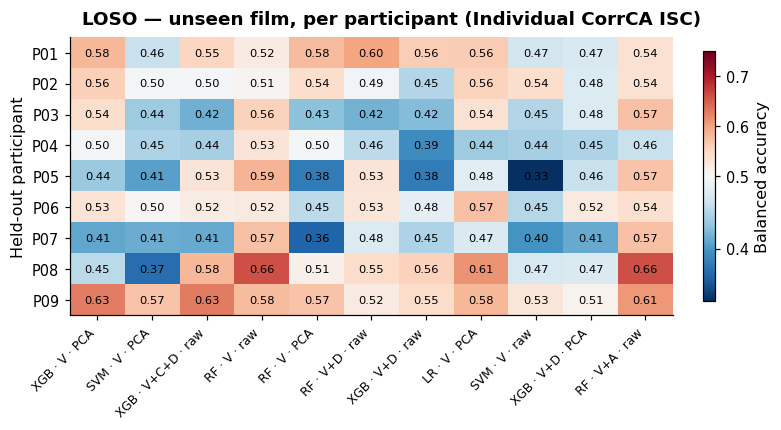

Fig20c_loso_unseen_individual — Each cell is one LOSO fold. Column labels: model · blocks (V = Visual, A =
Audio, C = CLIP, D = DINOv2) · raw/PCA.



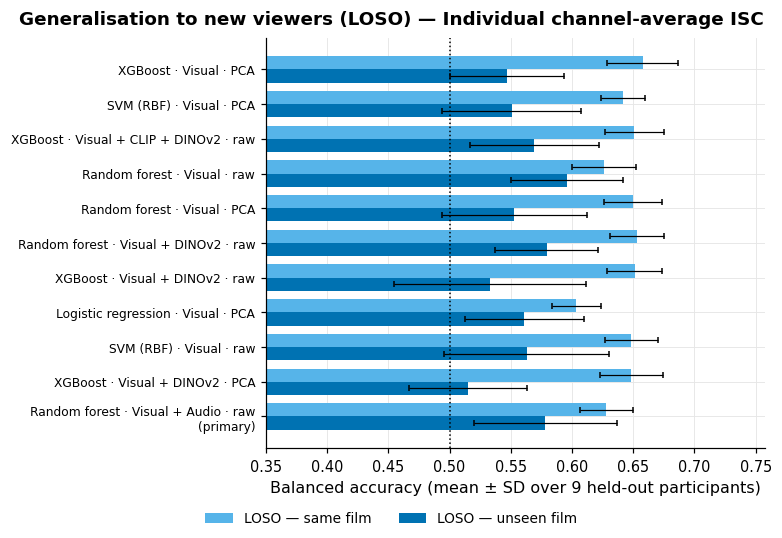

Fig20b_loso_individual_avg — Top configurations (validation ranking) and the primary interpretable
configuration: LOSO with the same film (light) and with unseen film moments (dark).



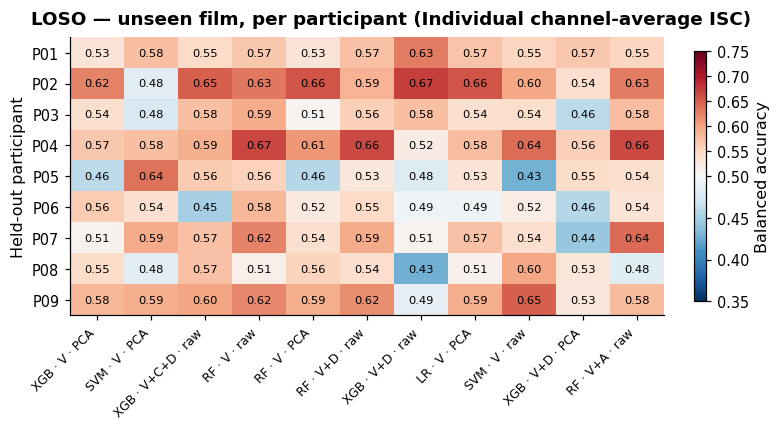

Fig20c_loso_unseen_individual_avg — Each cell is one LOSO fold. Column labels: model · blocks (V = Visual, A =
Audio, C = CLIP, D = DINOv2) · raw/PCA.



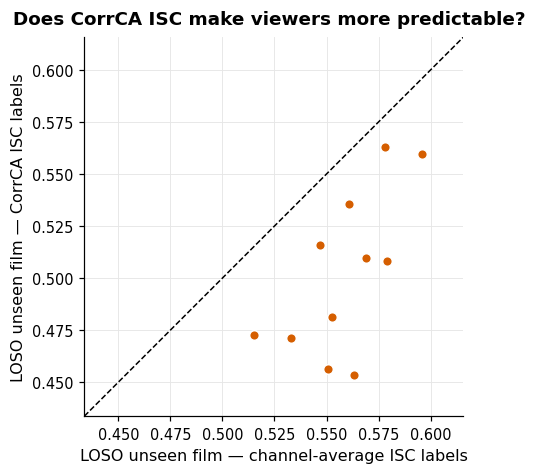

Fig20d_loso_corrca_vs_avg — Each point is one configuration (mean over held-out participants). Points above
the diagonal are better predicted with CorrCA-based labels.



In [ ]:
va_combo = "Visual + Audio" if "Audio" in BLOCKS else "Visual"
PRIMARY_CFG = RES_DF[(RES_DF.combination == va_combo) & (RES_DF["mode"] == "raw")].sort_values("val_roc_auc", ascending=False).config.iloc[0]
LOSO_CFGS = list(dict.fromkeys(RANK[:CFG["LOSO_TOP_K"]] + [PRIMARY_CFG]))
ABBR = {"logreg": "LR", "svm": "SVM", "rf": "RF", "xgb": "XGB", "mlp": "MLP"}
SHORTLAB = {c: f"{ABBR[r.model]} · {'+'.join(b[0] for b in r.combination.split(' + '))} · {'PCA' if r['mode'] == 'pca' else 'raw'}"
            for c, r in RES_DF.set_index("config").iterrows()}
LOSO_FILE = D["results"] / "loso_results.csv"
LOSO = pd.read_csv(LOSO_FILE) if LOSO_FILE.exists() else pd.DataFrame()
VARIANTS = {"LOSO — same film": (["train", "val", "test"], ["train", "val", "test"]),
            "LOSO — unseen film": (["train"], ["test"])}
for target in ["individual", "individual_avg"]:
    for cid in LOSO_CFGS:
        r = RES_DF.set_index("config").loc[cid]
        combo, params = tuple(r.combination.split(" + ")), json.loads(r.best_params)
        for vname, (tr_parts, te_parts) in VARIANTS.items():
            if len(LOSO) and ((LOSO.config == cid) & (LOSO.variant == vname) & (LOSO.target == target)).any():
                continue
            fold_rows = []
            all_tr, all_te = rows(tr_parts, target), rows(te_parts, target)
            for pid in PIDS:
                dtr = all_tr[all_tr.participant != pid]
                dte = all_te[all_te.participant == pid].reset_index(drop=True)
                m = fit_cfg(r.model, combo, r["mode"], params, dtr)
                p = m.predict_proba(dte[cols_of(combo)])[:, 1]
                fold_rows.append({"target": target, "config": cid, "variant": vname, "participant": pid,
                                  **metrics(dte.y.to_numpy(), p)})
            LOSO = pd.concat([LOSO, pd.DataFrame(fold_rows)], ignore_index=True)
            LOSO.to_csv(LOSO_FILE, index=False)
            d = pd.DataFrame(fold_rows)
            print(f"{target:15s} {LABEL[cid]:50s} {vname:20s} BA {d.balanced_accuracy.mean():.3f} ± "
                  f"{d.balanced_accuracy.std():.3f} | {(d.balanced_accuracy > 0.5).sum()}/{len(PIDS)} > 0.5")


def _wil(v):
    v = v.dropna() - 0.5
    return scipy.stats.wilcoxon(v, alternative="greater").pvalue if (v != 0).sum() > 0 else np.nan


LOSO_SUM = LOSO.groupby(["target", "config", "variant"]).apply(lambda g: pd.Series({
    "ba_mean": g.balanced_accuracy.mean(), "ba_sd": g.balanced_accuracy.std(ddof=1), "auc_mean": g.roc_auc.mean(),
    "auc_sd": g.roc_auc.std(ddof=1), "n_above_chance": int((g.balanced_accuracy > 0.5).sum()),
    "wilcoxon_p": _wil(g.balanced_accuracy)}), include_groups=False).reset_index()
LOSO_SUM["label"] = LOSO_SUM.config.map(LABEL)
save_csv(LOSO_SUM, "loso_summary")
print(LOSO_SUM.sort_values(["target", "variant", "ba_mean"], ascending=[True, True, False])
      [["target", "label", "variant", "ba_mean", "ba_sd", "auc_mean", "n_above_chance", "wilcoxon_p"]].round(3).to_string(index=False))

order_c = LOSO_CFGS
for target in ["individual", "individual_avg"]:
    fig, ax = fig_ax(FULL, 4.8)
    yy = np.arange(len(order_c))[::-1]
    for k, (vname, c) in enumerate([("LOSO — same film", OI["sky"]), ("LOSO — unseen film", OI["blue"])]):
        d = LOSO_SUM[(LOSO_SUM.variant == vname) & (LOSO_SUM.target == target)].set_index("config").loc[order_c]
        ax.barh(yy + (0.5 - k) * 0.38, d.ba_mean, 0.38, xerr=d.ba_sd, color=c, capsize=2, label=vname, error_kw=dict(lw=0.8))
    ax.axvline(0.5, color="k", ls=":", lw=1)
    ax.set_yticks(yy)
    ax.set_yticklabels([textwrap.fill(LABEL[c] + (" (primary)" if c == PRIMARY_CFG else ""), 38) for c in order_c], fontsize=8)
    ax.set_xlim(0.35, max(0.75, LOSO_SUM.ba_mean.max() + LOSO_SUM.ba_sd.max() + 0.02))
    ax.set_xlabel(f"Balanced accuracy (mean ± SD over {len(PIDS)} held-out participants)")
    legend_below(fig, ax, 2)
    save(fig, f"Fig20b_loso_{target}", f"Generalisation to new viewers (LOSO) — {TARGET_NAMES[target]}",
         "Top configurations (validation ranking) and the primary interpretable configuration: LOSO with the same film "
         "(light) and with unseen film moments (dark).")

    M = LOSO[(LOSO.variant == "LOSO — unseen film") & (LOSO.target == target)].pivot(
        index="participant", columns="config", values="balanced_accuracy")[order_c]
    fig, ax = fig_ax(FULL, 3.8)
    im = ax.imshow(M.values, cmap="RdBu_r", norm=mpl.colors.TwoSlopeNorm(vmin=min(0.35, np.nanmin(M.values)), vcenter=0.5,
                                                                         vmax=max(0.75, np.nanmax(M.values))), aspect="auto")
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, f"{M.values[i, j]:.2f}", ha="center", va="center", fontsize=7.5)
    ax.set_xticks(range(M.shape[1]))
    ax.set_xticklabels([SHORTLAB[c] for c in M.columns], fontsize=8, rotation=45, ha="right")
    ax.set_yticks(range(len(M)))
    ax.set_yticklabels(M.index)
    ax.set_ylabel("Held-out participant")
    ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.9).set_label("Balanced accuracy")
    save(fig, f"Fig20c_loso_unseen_{target}", f"LOSO — unseen film, per participant ({TARGET_NAMES[target]})",
         "Each cell is one LOSO fold. Column labels: model · blocks (V = Visual, A = Audio, C = CLIP, D = DINOv2) · raw/PCA.")

cmp = LOSO_SUM[LOSO_SUM.variant == "LOSO — unseen film"].pivot(index="config", columns="target", values="ba_mean").loc[order_c]
fig, ax = fig_ax(HALF, 4.2)
ax.scatter(cmp["individual_avg"], cmp["individual"], s=40, color=OI["vermillion"], edgecolor="white")
lo_, hi_ = cmp.min().min() - 0.02, cmp.max().max() + 0.02
ax.plot([lo_, hi_], [lo_, hi_], "k--", lw=1)
ax.set_xlim(lo_, hi_)
ax.set_ylim(lo_, hi_)
ax.set_aspect("equal")
ax.set_xlabel("LOSO unseen film — channel-average ISC labels")
ax.set_ylabel("LOSO unseen film — CorrCA ISC labels")
save(fig, "Fig20d_loso_corrca_vs_avg", "Does CorrCA ISC make viewers more predictable?",
     "Each point is one configuration (mean over held-out participants). Points above the diagonal are better predicted "
     "with CorrCA-based labels.")

## 9d. Comparison of the three targets
The five models on the interpretable **Visual + Audio (raw)** features, each tuned on validation and tested once, for the audience, individual CorrCA and individual channel-average targets (same split, same features).

target  audience  individual  individual_avg
model                                       
logreg     0.472       0.495           0.575
mlp        0.483       0.488           0.540
rf         0.590       0.565           0.572
svm        0.436       0.545           0.541
xgb        0.535       0.513           0.612


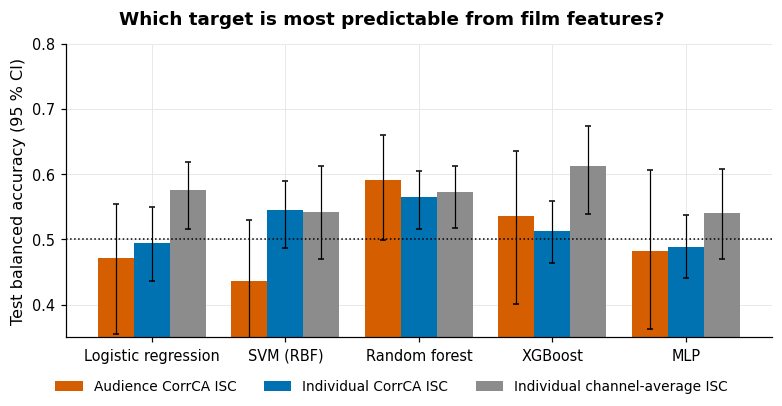

Fig20e_target_comparison — Test balanced accuracy on unseen film moments (Visual + Audio features, raw) for
the three targets. Same split, features and tuning procedure.



In [ ]:
TC_ROWS = []
combo_va = tuple(va_combo.split(" + "))
for target in LABELS:
    dtr, dva, dte = rows("train", target), rows("val", target), rows("test", target)
    for model in CFG["MODELS"]:
        best = None
        for vals in product(*GRIDS[model][1].values()):
            params = dict(zip(GRIDS[model][1], vals))
            m = fit_cfg(model, combo_va, "raw", params, dtr)
            mv = metrics(dva.y.to_numpy(), m.predict_proba(dva[cols_of(combo_va)])[:, 1])
            if best is None or (mv["roc_auc"], mv["balanced_accuracy"]) > best[0]:
                best = ((mv["roc_auc"], mv["balanced_accuracy"]), m)
        p = best[1].predict_proba(dte[cols_of(combo_va)])[:, 1]
        (lo, hi), _ = shot_bootstrap(dte, p, n=300)
        TC_ROWS.append({"target": target, "model": model, "val_roc_auc": best[0][0], **metrics(dte.y.to_numpy(), p),
                        "ba_ci95_low": lo, "ba_ci95_high": hi})
TC = pd.DataFrame(TC_ROWS)
save_csv(TC, "target_comparison_visual_audio")
print(TC.pivot(index="model", columns="target", values="balanced_accuracy").round(3).to_string())
fig, ax = fig_ax(FULL, 3.6)
x = np.arange(len(CFG["MODELS"]))
tcol = {"audience": OI["vermillion"], "individual": OI["blue"], "individual_avg": OI["grey"]}
for k, t in enumerate(LABELS):
    d = TC[TC.target == t].set_index("model").loc[CFG["MODELS"]]
    ax.bar(x + (k - 1) * 0.27, d.balanced_accuracy, 0.27, color=tcol[t], label=TARGET_NAMES[t],
           yerr=[d.balanced_accuracy - d.ba_ci95_low, d.ba_ci95_high - d.balanced_accuracy], capsize=2, error_kw=dict(lw=0.8))
ax.axhline(0.5, color="k", ls=":", lw=1)
ax.set_xticks(x)
ax.set_xticklabels([MODEL_NAMES[m] for m in CFG["MODELS"]])
ax.set_ylim(0.35, max(0.8, np.nanmax([TC.ba_ci95_high.max(), TC.balanced_accuracy.max()]) + 0.02))
ax.set_ylabel("Test balanced accuracy (95 % CI)")
legend_below(fig, ax, 3)
save(fig, "Fig20e_target_comparison", "Which target is most predictable from film features?",
     "Test balanced accuracy on unseen film moments (Visual + Audio features, raw) for the three targets. Same split, "
     "features and tuning procedure.")

## 9e. Stimulus–response lag
The primary interpretable configuration is retrained with the **target shifted by L windows** (features at window *k* predict the label at window *k + L*; the same split and the same hyper-parameters). A peak at L > 0 indicates that film features predict synchrony that follows them.

 lag_windows  lag_s  balanced_accuracy  roc_auc  pr_auc    f1  accuracy  brier
          -2   -8.0              0.510    0.540   0.486 0.537     0.492  0.261
          -1   -4.0              0.565    0.590   0.526 0.557     0.557  0.258
           0    0.0              0.590    0.537   0.501 0.561     0.590  0.261
           1    4.0              0.588    0.611   0.553 0.520     0.600  0.248
           2    8.0              0.499    0.475   0.442 0.516     0.492  0.262
           3   12.0              0.431    0.401   0.446 0.476     0.431  0.268


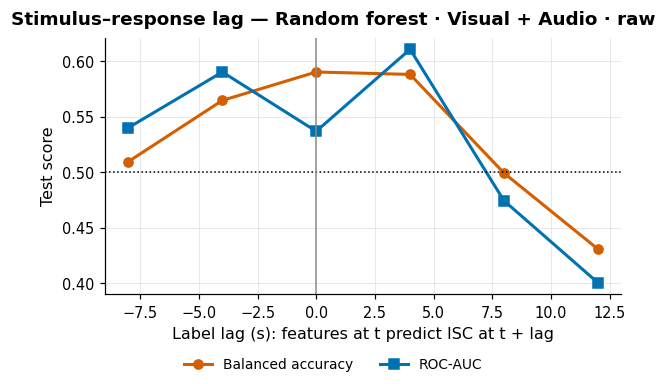

Fig20f_label_lag — Test performance when the Audience CorrCA ISC label is shifted relative to the film
features.



In [ ]:
rr = RES_DF.set_index("config").loc[PRIMARY_CFG]
combo_p, params_p = tuple(rr.combination.split(" + ")), json.loads(rr.best_params)
lag_rows = []
L_orig = LABELS[PRIMARY]
for Lg in CFG["LABEL_LAGS"]:
    LABELS[PRIMARY] = L_orig.shift(-Lg)
    dtr, dte = rows("train"), rows("test")
    dtr, dte = dtr.dropna(subset=["y"]), dte.dropna(subset=["y"]).reset_index(drop=True)
    dtr["y"], dte["y"] = dtr.y.astype(int), dte.y.astype(int)
    m = fit_cfg(rr.model, combo_p, rr["mode"], params_p, dtr)
    p = m.predict_proba(dte[cols_of(combo_p)])[:, 1]
    lag_rows.append({"lag_windows": Lg, "lag_s": Lg * CFG["WINDOW_S"], **metrics(dte.y.to_numpy(), p)})
LABELS[PRIMARY] = L_orig
LAGS = pd.DataFrame(lag_rows)
save_csv(LAGS, "label_lag_analysis")
print(LAGS.round(3).to_string(index=False))
fig, ax = fig_ax(HALF + 0.6, 3.4)
ax.plot(LAGS.lag_s, LAGS.balanced_accuracy, marker="o", color=OI["vermillion"], lw=2, label="Balanced accuracy")
ax.plot(LAGS.lag_s, LAGS.roc_auc, marker="s", color=OI["blue"], lw=2, label="ROC-AUC")
ax.axhline(0.5, color="k", ls=":", lw=1)
ax.axvline(0, color=OI["grey"], lw=1)
ax.set_xlabel("Label lag (s): features at t predict ISC at t + lag")
ax.set_ylabel("Test score")
legend_below(fig, ax, 2)
save(fig, "Fig20f_label_lag", f"Stimulus–response lag — {LABEL[PRIMARY_CFG]}",
     f"Test performance when the {TARGET_NAMES[PRIMARY]} label is shifted relative to the film features.")

## 10. Examination of the top configurations
For the two configurations with the highest **validation** ROC-AUC: confusion matrix, ROC and precision–recall curves (pooled and per participant), calibration, threshold sensitivity, and predictions along the film.

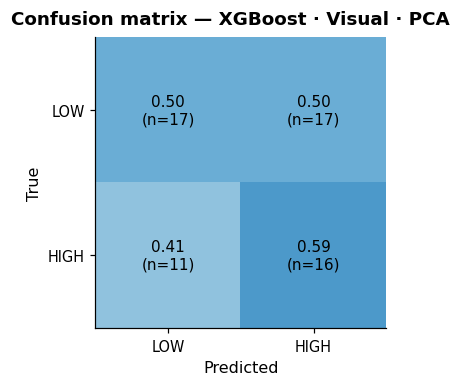

Fig21_1_confusion — Row-normalised confusion matrix on all test rows.



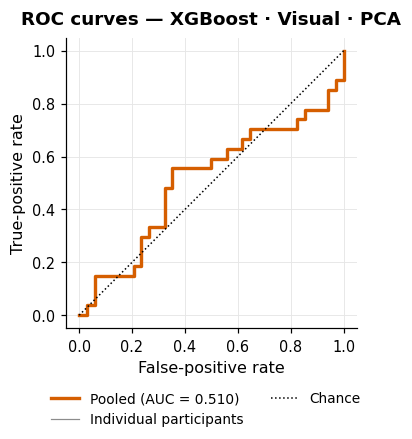

Fig22_1_roc — Test ROC curve pooled and per participant.



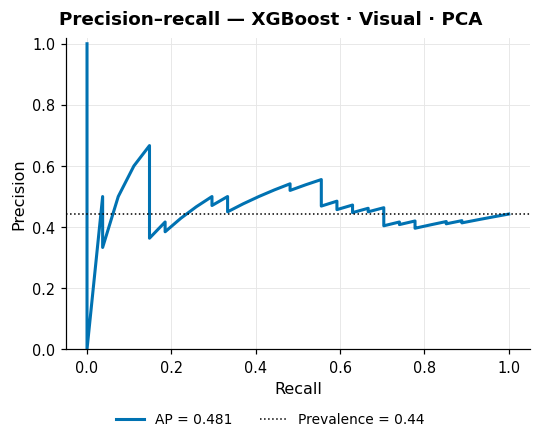

Fig23_1_pr — Pooled test precision–recall curve.



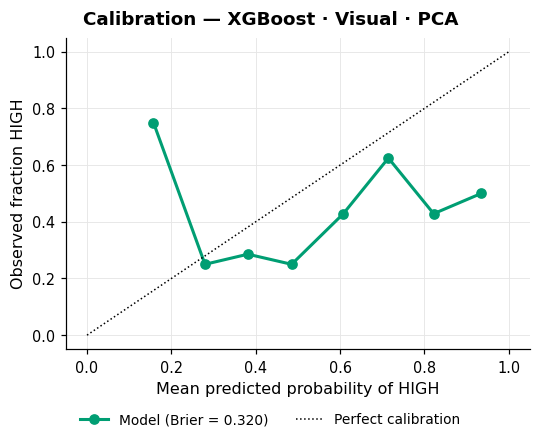

Fig24_1_calibration — Reliability diagram on the test set (quantile bins).



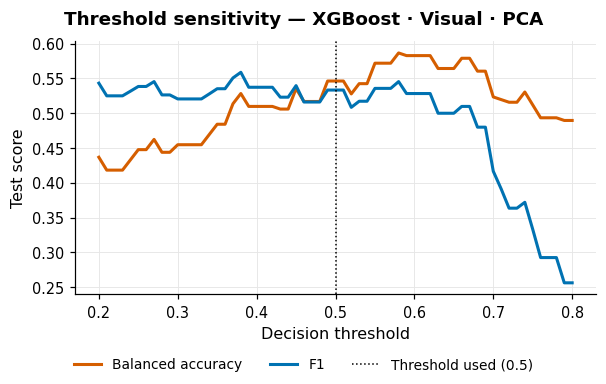

Fig25_1_threshold — Test scores across decision thresholds (inspection only; reported results use 0.5).



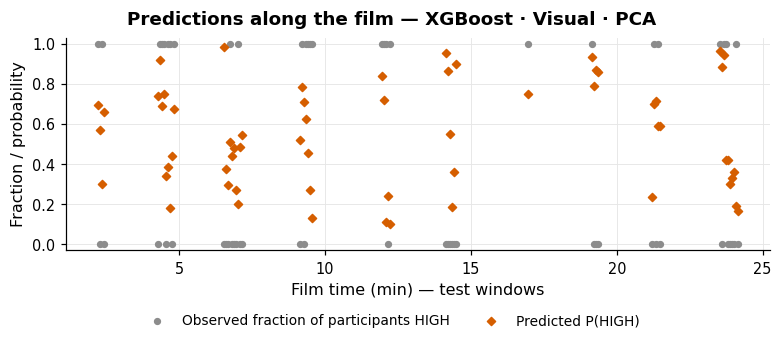

Fig26_1_timeline — Predicted probability of HIGH ISC vs the observed fraction of participants HIGH per test
window (Spearman ρ = 0.02).



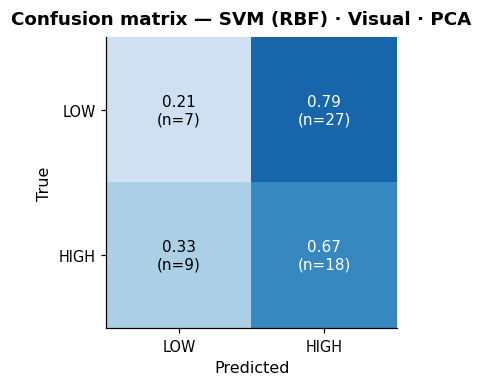

Fig21_2_confusion — Row-normalised confusion matrix on all test rows.



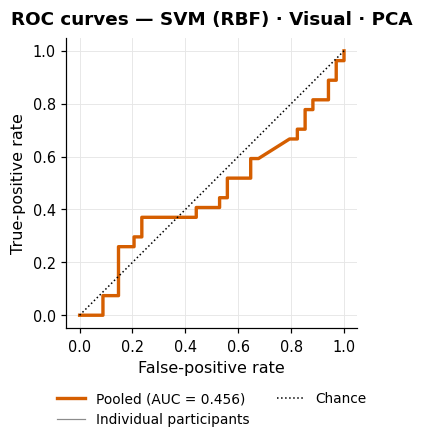

Fig22_2_roc — Test ROC curve pooled and per participant.



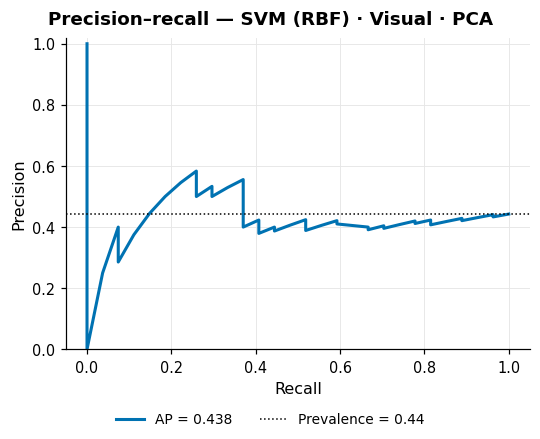

Fig23_2_pr — Pooled test precision–recall curve.



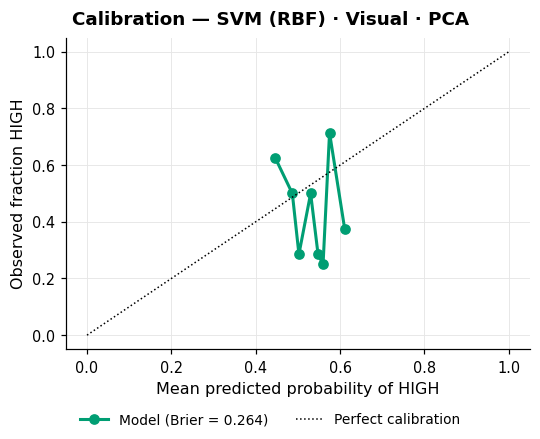

Fig24_2_calibration — Reliability diagram on the test set (quantile bins).



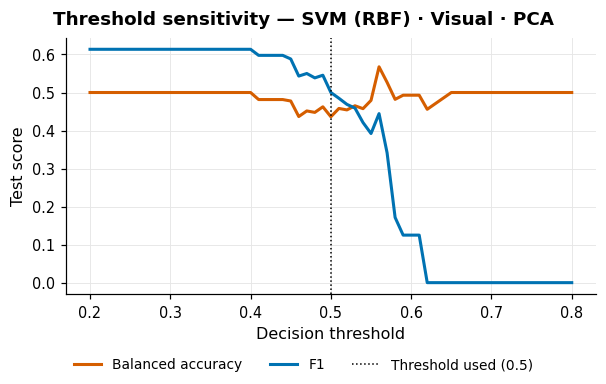

Fig25_2_threshold — Test scores across decision thresholds (inspection only; reported results use 0.5).



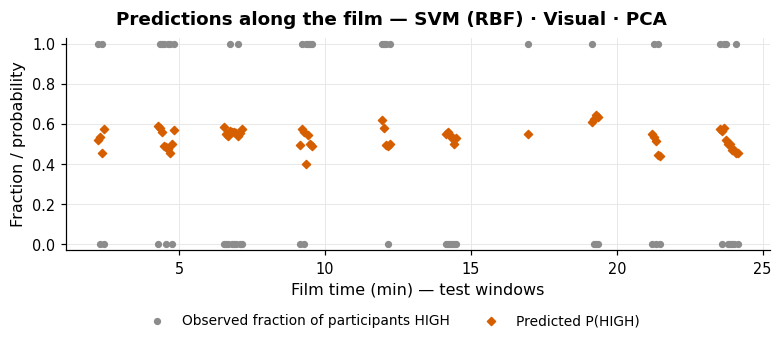

Fig26_2_timeline — Predicted probability of HIGH ISC vs the observed fraction of participants HIGH per test
window (Spearman ρ = -0.08).



In [ ]:
for rank, cid in enumerate(TOP, 1):
    p, y = PRED[cid], DTE.y.to_numpy()
    pred = (p >= 0.5).astype(int)
    lab = LABEL[cid]
    cm, cmn = confusion_matrix(y, pred), confusion_matrix(y, pred, normalize="true")
    fig, ax = fig_ax(3.8, 3.4)
    ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cmn[i, j]:.2f}\n(n={cm[i, j]})", ha="center", va="center", color="white" if cmn[i, j] > 0.6 else "black")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["LOW", "HIGH"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["LOW", "HIGH"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.grid(False)
    save(fig, f"Fig21_{rank}_confusion", f"Confusion matrix — {lab}", "Row-normalised confusion matrix on all test rows.")

    fig, ax = fig_ax(HALF, 3.9)
    for pid, g in DTE.groupby("participant"):
        f_, t_, _ = roc_curve(g.y, p[g.index])
        ax.plot(f_, t_, color=OI["grey"], lw=0.7, alpha=0.6)
    f_, t_, _ = roc_curve(y, p)
    ax.plot(f_, t_, color=OI["vermillion"], lw=2.2, label=f"Pooled (AUC = {roc_auc_score(y, p):.3f})")
    ax.plot([], [], color=OI["grey"], lw=0.8, label="Individual participants")
    ax.plot([0, 1], [0, 1], "k:", lw=1, label="Chance")
    ax.set_xlabel("False-positive rate")
    ax.set_ylabel("True-positive rate")
    ax.set_aspect("equal")
    legend_below(fig, ax, 2)
    save(fig, f"Fig22_{rank}_roc", f"ROC curves — {lab}", "Test ROC curve pooled and per participant.")

    fig, ax = fig_ax(HALF, 3.9)
    pr_, rc_, _ = precision_recall_curve(y, p)
    ax.plot(rc_, pr_, color=OI["blue"], lw=2, label=f"AP = {average_precision_score(y, p):.3f}")
    ax.axhline(y.mean(), color="k", ls=":", lw=1, label=f"Prevalence = {y.mean():.2f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_ylim(0, 1.02)
    legend_below(fig, ax, 2)
    save(fig, f"Fig23_{rank}_pr", f"Precision–recall — {lab}", "Pooled test precision–recall curve.")

    fig, ax = fig_ax(HALF, 3.9)
    fp, mp = calibration_curve(y, p, n_bins=8, strategy="quantile")
    ax.plot(mp, fp, marker="o", color=OI["green"], lw=2, label=f"Model (Brier = {brier_score_loss(y, p):.3f})")
    ax.plot([0, 1], [0, 1], "k:", lw=1, label="Perfect calibration")
    ax.set_xlabel("Mean predicted probability of HIGH")
    ax.set_ylabel("Observed fraction HIGH")
    legend_below(fig, ax, 2)
    save(fig, f"Fig24_{rank}_calibration", f"Calibration — {lab}", "Reliability diagram on the test set (quantile bins).")

    fig, ax = fig_ax(HALF + 0.6, 3.4)
    ths = np.linspace(0.2, 0.8, 61)
    ax.plot(ths, [balanced_accuracy_score(y, (p >= t).astype(int)) for t in ths], color=OI["vermillion"], lw=2, label="Balanced accuracy")
    ax.plot(ths, [f1_score(y, (p >= t).astype(int)) for t in ths], color=OI["blue"], lw=2, label="F1")
    ax.axvline(0.5, color="k", ls=":", lw=1, label="Threshold used (0.5)")
    ax.set_xlabel("Decision threshold")
    ax.set_ylabel("Test score")
    legend_below(fig, ax, 3)
    save(fig, f"Fig25_{rank}_threshold", f"Threshold sensitivity — {lab}", "Test scores across decision thresholds "
         "(inspection only; reported results use 0.5).")

    tw = DTE.assign(p=p).groupby("segment").agg(prob=("p", "mean"), frac_high=("y", "mean")).join(SEG.set_index("segment").t_start)
    fig, ax = fig_ax(FULL, 3.0)
    ax.scatter(tw.t_start / 60, tw.frac_high, s=14, color=OI["grey"], label="Observed fraction of participants HIGH")
    ax.scatter(tw.t_start / 60, tw.prob, s=14, color=OI["vermillion"], marker="D", label="Predicted P(HIGH)")
    r_ = scipy.stats.spearmanr(tw.prob, tw.frac_high)[0]
    ax.set_xlabel("Film time (min) — test windows")
    ax.set_ylabel("Fraction / probability")
    ax.set_ylim(-0.03, 1.03)
    legend_below(fig, ax, 2)
    save(fig, f"Fig26_{rank}_timeline", f"Predictions along the film — {lab}",
         f"Predicted probability of HIGH ISC vs the observed fraction of participants HIGH per test window (Spearman ρ = {r_:.2f}).")

## 11. Ablation of the low-level feature groups
The best model on the **Visual + Audio (raw)** features (chosen on validation) is retrained with its selected hyper-parameters on: all 93 features, visual only, audio only, each group alone, and all minus each group. Test balanced accuracy with 95 % shot-bootstrap confidence intervals.

Ablation model: Random forest {'max_depth': 4}
               feature_set  n_features  balanced_accuracy  roc_auc  ba_ci95_low  ba_ci95_high
                   All 170         170              0.590    0.537        0.499         0.660
         Visual only (158)         158              0.590    0.566        0.489         0.672
           Audio only (12)          12              0.492    0.483        0.424         0.569
   Only Colour & luminance          18              0.435    0.431        0.299         0.554
     Only Hue distribution           9              0.480    0.423        0.310         0.645
              Only Texture          11              0.477    0.489        0.378         0.603
               Only Motion          15              0.509    0.458        0.374         0.630
     Only Temporal editing          10              0.561    0.544        0.422         0.660
          Only Composition          18              0.528    0.431        0.409         0.625
          Onl

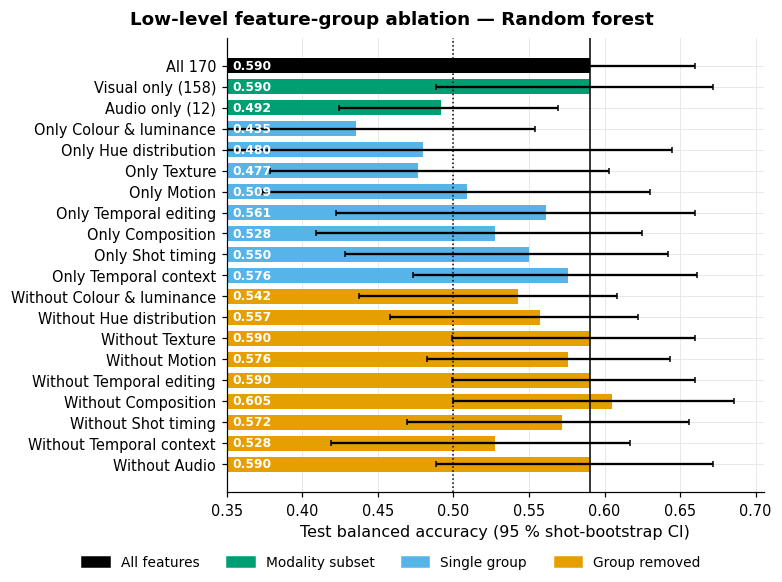

Fig27_ablation_lowlevel — Test balanced accuracy when training on subsets of the visual and audio features
(hyper-parameters fixed to the validation-selected values). The vertical line marks the model with all
features.



In [ ]:
va_combo = "Visual + Audio" if "Audio" in BLOCKS else "Visual"
LL = RES_DF[(RES_DF.combination == va_combo) & (RES_DF["mode"] == "raw")].sort_values("val_roc_auc", ascending=False).iloc[0]
ll_model, ll_params = LL.model, json.loads(LL.best_params)
SETS = {f"All {len(FEATURES)}": FEATURES, f"Visual only ({len(VIS)})": VIS}
if "Audio" in BLOCKS:
    SETS["Audio only (12)"] = AUDIO
SETS.update({f"Only {GLAB[g]}": c for g, c in GROUPS.items()})
SETS.update({f"Without {GLAB[g]}": [f for f in FEATURES if f not in c] for g, c in GROUPS_ALL.items()})
ABL = []
for sname, cols in SETS.items():
    mdl = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler()),
                                  ("clf", GRIDS[ll_model][0](**ll_params))]).fit(DTR[cols], DTR.y)
    p = mdl.predict_proba(DTE[cols])[:, 1]
    (lo, hi), _ = shot_bootstrap(DTE, p, n=300)
    ABL.append({"feature_set": sname, "n_features": len(cols), **metrics(DTE.y.to_numpy(), p), "ba_ci95_low": lo, "ba_ci95_high": hi})
ABL_DF = pd.DataFrame(ABL)
save_csv(ABL_DF, "ablation_lowlevel_test")
print(f"Ablation model: {MODEL_NAMES[ll_model]} {ll_params}")
print(ABL_DF[["feature_set", "n_features", "balanced_accuracy", "roc_auc", "ba_ci95_low", "ba_ci95_high"]].round(3).to_string(index=False))
d = ABL_DF.set_index("feature_set")
fig, ax = fig_ax(FULL, 5.2)
yy = np.arange(len(d))[::-1]
cols_ = [OI["black"] if s.startswith("All") else (OI["orange"] if s.startswith("Without") else
         (OI["sky"] if s.startswith("Only") else OI["green"])) for s in d.index]
ax.barh(yy, d.balanced_accuracy, xerr=[d.balanced_accuracy - d.ba_ci95_low, d.ba_ci95_high - d.balanced_accuracy],
        color=cols_, capsize=2, height=0.7)
x0 = max(0.35, np.nanmin([d.ba_ci95_low.min(), d.balanced_accuracy.min()]) - 0.02)
for yi, v in zip(yy, d.balanced_accuracy):
    ax.text(x0 + 0.004, yi, f"{v:.3f}", va="center", fontsize=8, color="white", fontweight="bold")
ax.axvline(d.balanced_accuracy.iloc[0], color="k", lw=1)
ax.axvline(0.5, color="k", ls=":", lw=1)
ax.set_yticks(yy)
ax.set_yticklabels(d.index)
ax.set_xlim(x0, np.nanmax([d.ba_ci95_high.max(), d.balanced_accuracy.max()]) + 0.02)
ax.set_xlabel("Test balanced accuracy (95 % shot-bootstrap CI)")
legend_below(fig, ax, 4, [mpl.patches.Patch(color=c) for c in [OI["black"], OI["green"], OI["sky"], OI["orange"]]],
             ["All features", "Modality subset", "Single group", "Group removed"])
save(fig, "Fig27_ablation_lowlevel", f"Low-level feature-group ablation — {MODEL_NAMES[ll_model]}",
     "Test balanced accuracy when training on subsets of the visual and audio features (hyper-parameters fixed to the "
     "validation-selected values). The vertical line marks the model with all features.")

## 12. Explanations
* **Interpretable features — SHAP** (TreeExplainer) for the best tree model on **Visual + Audio (raw)**: global importance, beeswarm, dependence plots for the four most important features, importance per feature group, and local explanations of the most confident HIGH and LOW windows.
* **Best overall configuration — block-level importance:** each feature block (Visual, Audio, CLIP, DINOv2) is shuffled jointly on the test set and the drop in ROC-AUC is measured (model-agnostic; works with PCA and embeddings).
* **Permutation importance** of individual low-level features for the Visual + Audio model.

CLIP/DINOv2 dimensions and PCA components have no direct human meaning; their role is assessed only at block level. Importances describe model reliance, not causal effects.

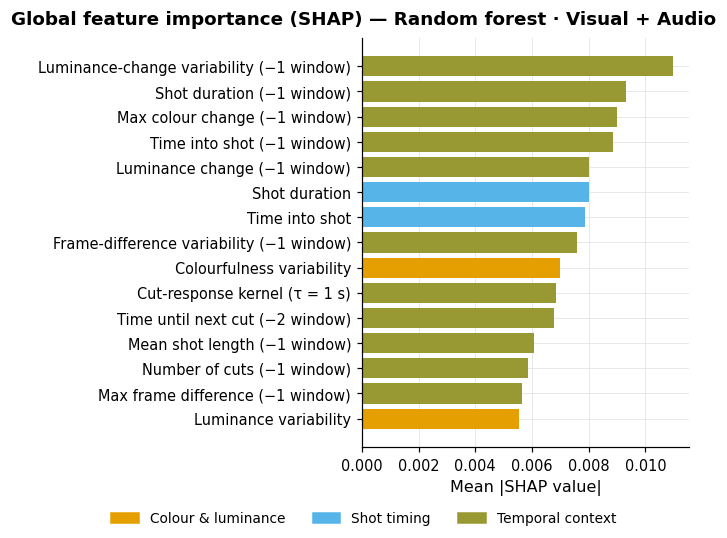

Fig28_shap_importance — Mean absolute SHAP value of the 15 most important features on the test windows,
coloured by feature group.



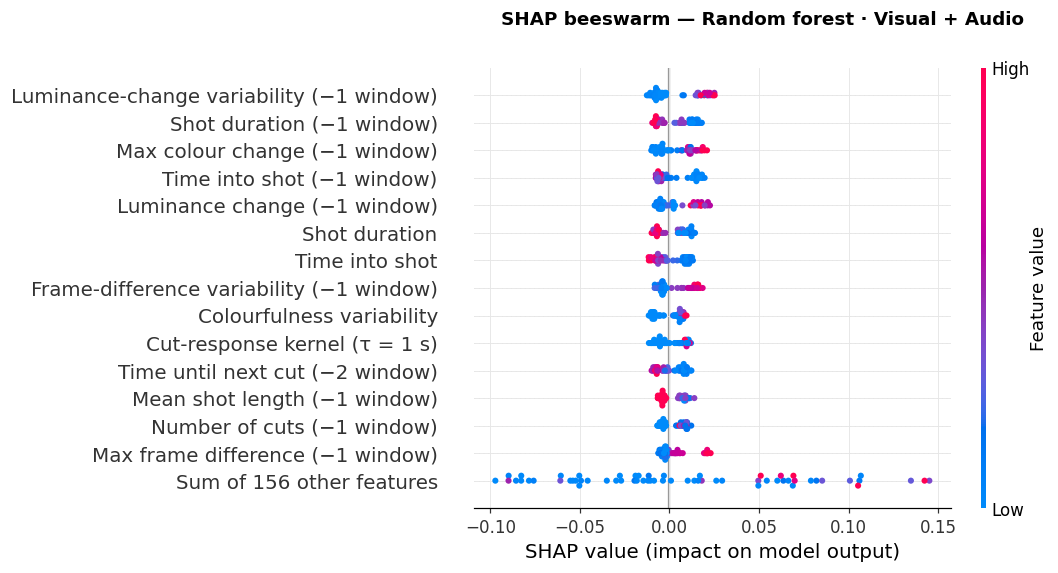

Fig29_shap_beeswarm — Each dot is one test window; position = contribution to the predicted log-odds of HIGH
ISC, colour = feature value (red high, blue low).



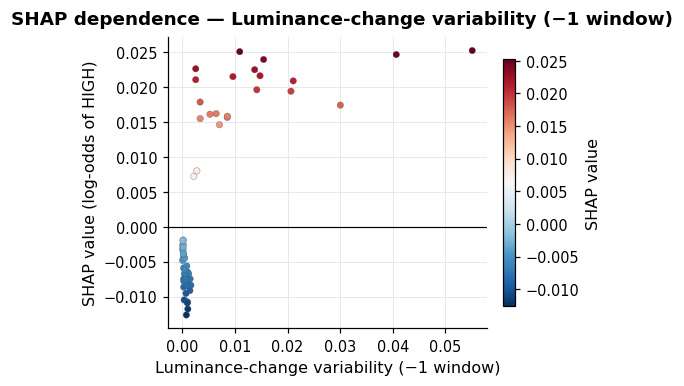

Fig30_1_shap_dependence — How the value of 'Luminance-change variability (−1 window)' changes the prediction
for each test window.



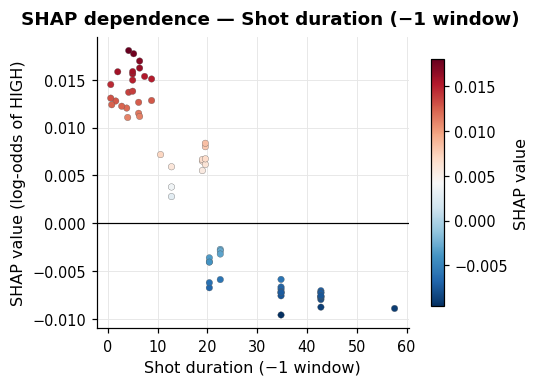

Fig30_2_shap_dependence — How the value of 'Shot duration (−1 window)' changes the prediction for each test
window.



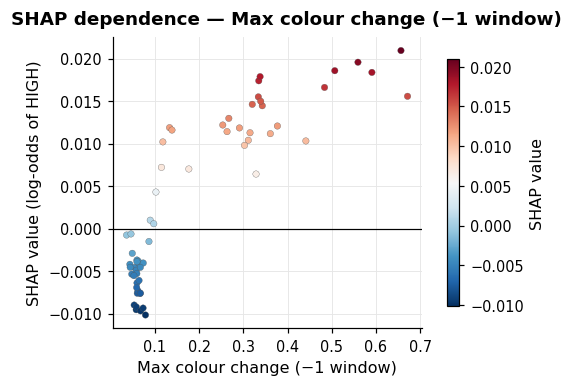

Fig30_3_shap_dependence — How the value of 'Max colour change (−1 window)' changes the prediction for each
test window.



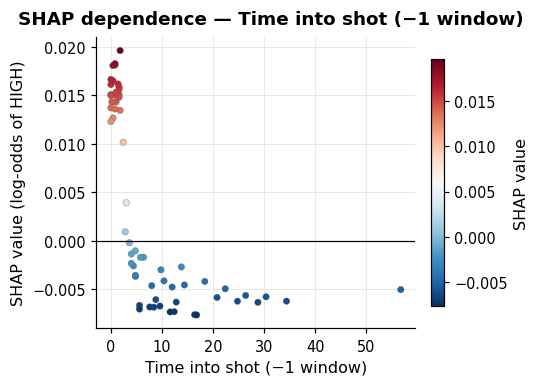

Fig30_4_shap_dependence — How the value of 'Time into shot (−1 window)' changes the prediction for each test
window.



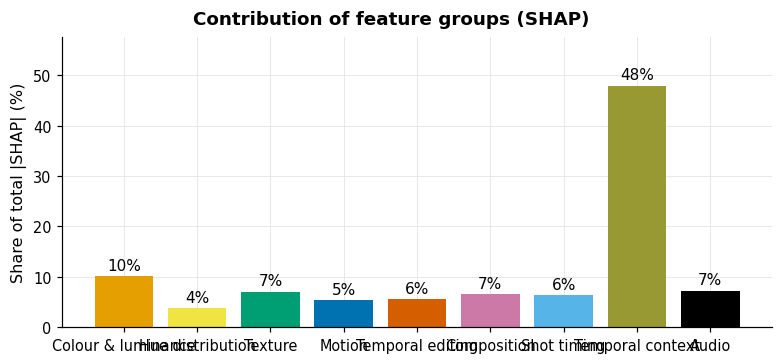

Fig31_shap_groups — Share of the total mean |SHAP| attributed to each feature group.



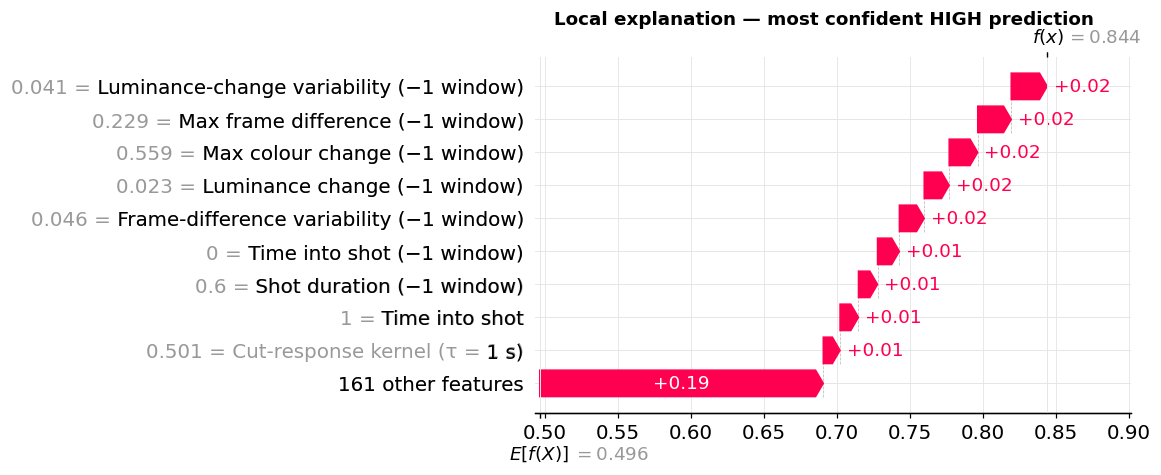

Fig32_shap_local_HIGH — Window at 23.6 min (predicted P(HIGH) = 0.84): contribution of each feature.



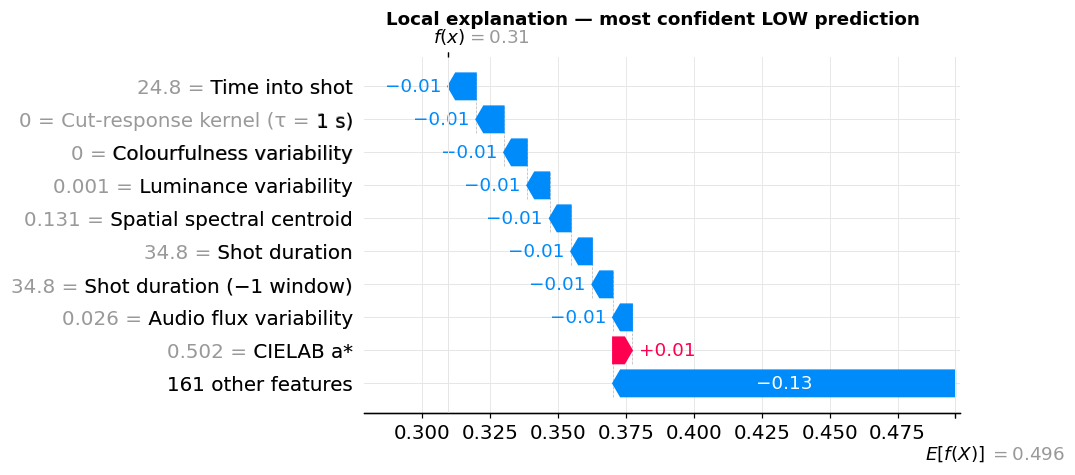

Fig32_shap_local_LOW — Window at 24.0 min (predicted P(HIGH) = 0.31): contribution of each feature.



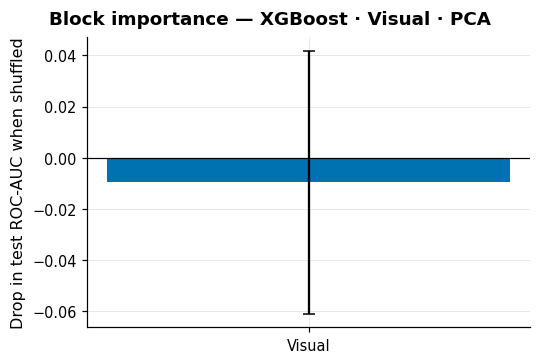

Fig33_block_importance — Decrease in test ROC-AUC when all features of a block are permuted jointly (mean ± SD
over 10 permutations) for the best configuration on validation.



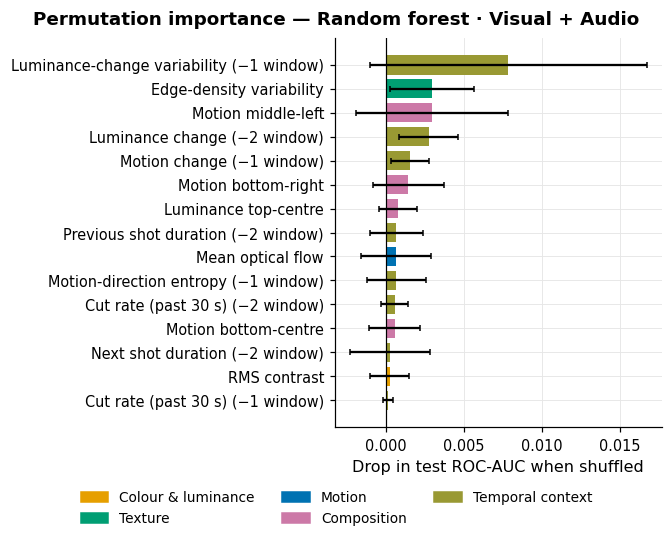

Fig34_permutation_importance — Mean ± SD decrease in test ROC-AUC over 10 permutations of each feature.



In [ ]:
tree_row = RES_DF[(RES_DF.combination == va_combo) & (RES_DF["mode"] == "raw") & RES_DF.model.isin(["xgb", "rf"])] \
    .sort_values("val_roc_auc", ascending=False).iloc[0]
tm = fit_cfg(tree_row.model, tuple(va_combo.split(" + ")), "raw", json.loads(tree_row.best_params), DTR)
Xte_u = X_FULL.loc[SPLIT[SPLIT == "test"].index, FEATURES]
Zte = tm.named_steps["prep"].transform(Xte_u)
sv = shap.TreeExplainer(tm.named_steps["clf"])(Zte)
if sv.values.ndim == 3:
    sv = sv[:, :, 1]
sv.feature_names = [nice(f) for f in FEATURES]
sv.data = Xte_u.to_numpy()
imp = pd.DataFrame({"feature": FEATURES, "label": [nice(f) for f in FEATURES], "group": [GROUP_OF[f] for f in FEATURES],
                    "mean_abs_shap": np.abs(sv.values).mean(0)}).sort_values("mean_abs_shap", ascending=False)
save_csv(imp, "shap_importance_visual_audio")
tname = f"{MODEL_NAMES[tree_row.model]} · {va_combo}"
top = imp.head(15)[::-1]
fig, ax = fig_ax(HALF + 1.2, 4.8)
ax.barh(top.label, top.mean_abs_shap, color=[GCOL[g] for g in top.group])
ax.set_xlabel("Mean |SHAP value|")
pres = [g for g in GROUPS_ALL if g in set(top.group)]
legend_below(fig, ax, 3, [mpl.patches.Patch(color=GCOL[g]) for g in pres], [GLAB[g] for g in pres])
save(fig, "Fig28_shap_importance", f"Global feature importance (SHAP) — {tname}",
     "Mean absolute SHAP value of the 15 most important features on the test windows, coloured by feature group.")

plt.figure()
shap.plots.beeswarm(sv, max_display=15, show=False)
fig = plt.gcf()
fig.set_size_inches(FULL, 5.2)
save(fig, "Fig29_shap_beeswarm", f"SHAP beeswarm — {tname}", "Each dot is one test window; position = contribution to "
     "the predicted log-odds of HIGH ISC, colour = feature value (red high, blue low).")

for k, f in enumerate(imp.feature.head(4), 1):
    j = FEATURES.index(f)
    fig, ax = fig_ax(HALF, 3.4)
    sc = ax.scatter(Xte_u[f], sv.values[:, j], c=sv.values[:, j], cmap="RdBu_r", s=18, edgecolor="#555555", lw=0.2)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel(nice(f))
    ax.set_ylabel("SHAP value (log-odds of HIGH)")
    fig.colorbar(sc, ax=ax, shrink=0.85).set_label("SHAP value")
    save(fig, f"Fig30_{k}_shap_dependence", f"SHAP dependence — {nice(f)}",
         f"How the value of '{nice(f)}' changes the prediction for each test window.")

share = imp.groupby("group").mean_abs_shap.sum().reindex(GROUPS_ALL) / imp.mean_abs_shap.sum() * 100
fig, ax = fig_ax(FULL, 3.2)
bars = ax.bar([GLAB[g] for g in share.index], share.values, color=[GCOL[g] for g in share.index])
ax.bar_label(bars, fmt="%.0f%%", padding=2)
ax.set_ylabel("Share of total |SHAP| (%)")
ax.set_ylim(0, share.max() * 1.2)
save(fig, "Fig31_shap_groups", "Contribution of feature groups (SHAP)", "Share of the total mean |SHAP| attributed to "
     "each feature group.")

prob_te = tm.predict_proba(Xte_u)[:, 1]
for lab_, idx in [("HIGH", int(np.argmax(prob_te))), ("LOW", int(np.argmin(prob_te)))]:
    plt.figure()
    shap.plots.waterfall(sv[idx], max_display=10, show=False)
    fig = plt.gcf()
    fig.set_size_inches(FULL, 4.2)
    t = SEG.set_index("segment").t_start[Xte_u.index[idx]]
    save(fig, f"Fig32_shap_local_{lab_}", f"Local explanation — most confident {lab_} prediction",
         f"Window at {t / 60:.1f} min (predicted P(HIGH) = {prob_te[idx]:.2f}): contribution of each feature.")

# block-level permutation importance for the best overall configuration
b_row = RES_DF.set_index("config").loc[RANK[0]]
b_combo = tuple(b_row.combination.split(" + "))
b_model = fit_cfg(b_row.model, b_combo, b_row["mode"], json.loads(b_row.best_params), DTR)
Xt = DTE[cols_of(b_combo)].reset_index(drop=True)
base_auc = roc_auc_score(DTE.y, b_model.predict_proba(Xt)[:, 1])
rng = np.random.default_rng(CFG["SEED"])
BPI = []
for b in b_combo:
    for rep in range(10):
        Xp = Xt.copy()
        perm = rng.permutation(len(Xp))
        Xp[BLOCKS[b]] = Xp[BLOCKS[b]].to_numpy()[perm]
        BPI.append({"block": b, "rep": rep, "auc_drop": base_auc - roc_auc_score(DTE.y, b_model.predict_proba(Xp)[:, 1])})
BPI = pd.DataFrame(BPI)
save_csv(BPI, "block_permutation_importance_best")
s = BPI.groupby("block").auc_drop.agg(["mean", "std"]).reindex(list(b_combo))
fig, ax = fig_ax(HALF, 3.2)
ax.bar(s.index, s["mean"], yerr=s["std"], color=[BCOL[b] for b in s.index], capsize=4)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("Drop in test ROC-AUC when shuffled")
save(fig, "Fig33_block_importance", f"Block importance — {LABEL[RANK[0]]}",
     "Decrease in test ROC-AUC when all features of a block are permuted jointly (mean ± SD over 10 permutations) for the "
     "best configuration on validation.")

pi = permutation_importance(tm, DTE[FEATURES], DTE.y, scoring="roc_auc", n_repeats=10, random_state=CFG["SEED"], n_jobs=-1)
PI = pd.DataFrame({"feature": FEATURES, "label": [nice(f) for f in FEATURES], "group": [GROUP_OF[f] for f in FEATURES],
                   "auc_drop_mean": pi.importances_mean, "auc_drop_sd": pi.importances_std}).sort_values("auc_drop_mean", ascending=False)
save_csv(PI, "permutation_importance_visual_audio")
t15 = PI.head(15)[::-1]
fig, ax = fig_ax(HALF + 1.2, 4.8)
ax.barh(t15.label, t15.auc_drop_mean, xerr=t15.auc_drop_sd, color=[GCOL[g] for g in t15.group], capsize=2)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Drop in test ROC-AUC when shuffled")
pres = [g for g in GROUPS_ALL if g in set(t15.group)]
legend_below(fig, ax, 3, [mpl.patches.Patch(color=GCOL[g]) for g in pres], [GLAB[g] for g in pres])
save(fig, "Fig34_permutation_importance", f"Permutation importance — {tname}",
     "Mean ± SD decrease in test ROC-AUC over 10 permutations of each feature.")

## 13. Null test, reports and export
**Circular-shift null** for the best configuration on validation: the target's ISC series (the audience series, or every participant's series for individual targets) is circularly shifted against the film (≥ `MIN_SHIFT_S`), labels are recomputed with the same rule, and the configuration (selected hyper-parameters) is retrained and tested `N_NULL` times. `p = (1 + #null ≥ observed) / (N_NULL + 1)`.

XGBoost · Visual · PCA: observed 0.546, null mean 0.498 (max 0.600), p = 0.194


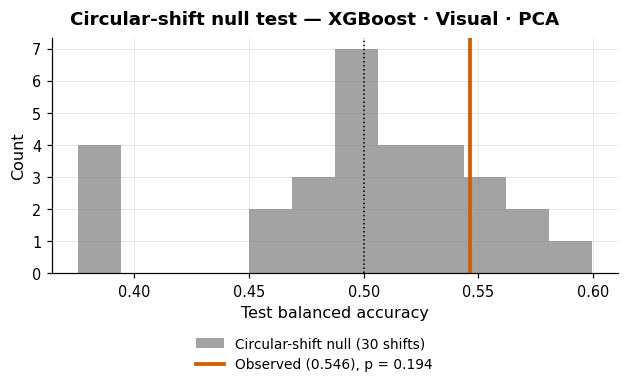

Fig35_null_test — Test accuracy after destroying the film–EEG alignment by circular shifts (≥ 60 s). Smallest
attainable p with 30 shifts = 0.032.



In [ ]:
obs = b_row.test_balanced_accuracy
min_shift = int(np.ceil(CFG["MIN_SHIFT_S"] / CFG["WINDOW_S"]))
NULL, L_REAL = [], LABELS[PRIMARY].copy()
V_REAL = VALUES[PRIMARY]
for i in range(CFG["N_NULL"]):
    rng = np.random.default_rng(1000 + i)
    roll = lambda v: np.roll(v, rng.integers(min_shift, len(v) - min_shift))
    if PRIMARY == "audience":
        sh = pd.Series(roll(V_REAL.to_numpy()), index=V_REAL.index)
    else:
        sh = V_REAL.apply(lambda c: pd.Series(roll(c.to_numpy()), index=c.index))
    LABELS[PRIMARY] = (sh > sh.loc[REF].median()).astype(int)
    dtr, dte = rows("train"), rows("test")
    mdl = fit_cfg(b_row.model, b_combo, b_row["mode"], json.loads(b_row.best_params), dtr)
    NULL.append(balanced_accuracy_score(dte.y, (mdl.predict_proba(dte[cols_of(b_combo)])[:, 1] >= 0.5).astype(int)))
LABELS[PRIMARY] = L_REAL
p_null = (1 + np.sum(np.array(NULL) >= obs)) / (len(NULL) + 1)
pd.DataFrame({"null_balanced_accuracy": NULL}).to_csv(D["results"] / "null_test.csv", index=False)
print(f"{LABEL[RANK[0]]}: observed {obs:.3f}, null mean {np.mean(NULL):.3f} (max {np.max(NULL):.3f}), p = {p_null:.3f}")
fig, ax = fig_ax(HALF + 0.8, 3.4)
ax.hist(NULL, bins=12, color=OI["grey"], alpha=0.8, label=f"Circular-shift null ({len(NULL)} shifts)")
ax.axvline(obs, color=OI["vermillion"], lw=2.5, label=f"Observed ({obs:.3f}), p = {p_null:.3f}")
ax.axvline(0.5, color="k", ls=":", lw=1)
ax.set_xlabel("Test balanced accuracy")
ax.set_ylabel("Count")
legend_below(fig, ax, 1)
save(fig, "Fig35_null_test", f"Circular-shift null test — {LABEL[RANK[0]]}",
     f"Test accuracy after destroying the film–EEG alignment by circular shifts (≥ {CFG['MIN_SHIFT_S']} s). "
     f"Smallest attainable p with {len(NULL)} shifts = {1 / (len(NULL) + 1):.3f}.")

### Summary report and export
`results/summary_report.md` (key numbers, tables, all figure captions), `results/results_tables.xlsx`, `run_info.json`, and one ZIP with results and figures.

In [ ]:
split_counts = SPLIT.value_counts()
top_tbl = RES_DF.sort_values("val_roc_auc", ascending=False)[["combination", "mode", "model", "n_model_inputs", "val_roc_auc",
                                                              "test_balanced_accuracy", "test_ba_ci95_low", "test_ba_ci95_high",
                                                              "test_roc_auc", "participants_above_chance", "wilcoxon_p_vs_0.5"]]
best_combo_tbl = bestc.reset_index()[["combination", "mode", "model", "test_balanced_accuracy", "test_roc_auc"]]
lines = [f"# Summary report — ISC prediction from film features ({CFG['WINDOW_S']:g}-s windows)",
         f"_Generated {datetime.now():%Y-%m-%d %H:%M}_", "",
         "## Data", f"- Participants: {len(PIDS)}; windows per participant: {N_SEG}; alignment offset {OFFSET:.2f} s ({SYNC['mode']}).",
         "- Feature blocks: " + ", ".join(f"{b} ({len(c)})" for b, c in BLOCKS.items()) + ".",
         f"- Group-mean ISC {grp_isc.mean():.4f}; positive in {100 * (grp_isc > 0).mean():.1f}% of windows; "
         f"Spearman ρ(ISC, time since cut) = {rho:.2f}.", "",
         "## Split", f"- Shots: {SHOT.nunique()}; blocks: {CFG['N_BLOCKS']}; windows — train {split_counts.get('train', 0)}, "
         f"validation {split_counts.get('val', 0)}, test {split_counts.get('test', 0)}, buffer {split_counts.get('buffer', 0)}.",
         f"- Share HIGH (mean over participants): train {bal.loc['ALL', 'train']:.3f}, validation {bal.loc['ALL', 'val']:.3f}, "
         f"test {bal.loc['ALL', 'test']:.3f}.", "",
         f"## All configurations ({len(RES_DF)}; top 20 by validation ROC-AUC)", top_tbl.head(20).round(3).to_markdown(index=False), "",
         f"- Chance reference (stratified dummy): test balanced accuracy {DUMMY['balanced_accuracy']:.3f}.",
         f"- Best on validation: **{LABEL[RANK[0]]}** — test balanced accuracy {obs:.3f} (95% CI {b_row.test_ba_ci95_low:.3f}–"
         f"{b_row.test_ba_ci95_high:.3f}), ROC-AUC {b_row.test_roc_auc:.3f}; circular-shift null p = {p_null:.3f}.", "",
         "## Best model per combination", best_combo_tbl.round(3).to_markdown(index=False), "",
         "## Marginal block contributions (mean Δ test BA when added)",
         CON.groupby("block").delta.agg(["mean", "sem", "count"]).round(4).to_markdown(), "",
         "## Targets", f"- Primary target: {TARGET_NAMES[PRIMARY]} (CorrCA, K = {CFG['CORRCA_K']}, fitted on training windows).",
         f"- Split-half reliability of audience ISC (median r): " + ", ".join(
             f"{k} {v:.2f}" for k, v in REL.groupby("measure").split_half_r.median().items()) + ".",
         "- Target comparison (Visual + Audio raw, test balanced accuracy):", "",
         TC.pivot(index="model", columns="target", values="balanced_accuracy").round(3).to_markdown(), "",
         "## Stimulus–response lag (primary interpretable configuration)", LAGS.round(3).to_markdown(index=False), "",
         "## Leave-one-subject-out (individual targets; mean over held-out participants)",
         LOSO_SUM[["target", "label", "variant", "ba_mean", "ba_sd", "auc_mean", "n_above_chance", "wilcoxon_p"]].round(3).to_markdown(index=False), "",
         f"- Primary interpretable configuration: {LABEL[PRIMARY_CFG]}.", "",
         "## Low-level ablation", ABL_DF[["feature_set", "n_features", "balanced_accuracy", "roc_auc"]].round(3).to_markdown(index=False), "",
         "## Most important low-level features (SHAP)", imp.head(10)[["label", "group", "mean_abs_shap"]].round(4).to_markdown(index=False), "",
         "## Figures"] + [f"- **{n}. {t}.** {c}" for n, t, c in CAPTIONS]
(D["results"] / "summary_report.md").write_text("\n".join(lines))
with pd.ExcelWriter(D["results"] / "results_tables.xlsx") as xw:
    for name, df in [("all_configurations", RES_DF), ("best_per_combination", best_combo_tbl), ("per_participant", PP),
                     ("tuning_validation", TUNE_DF), ("loso_summary", LOSO_SUM), ("loso_folds", LOSO), ("target_comparison", TC), ("label_lag", LAGS),
                     ("isc_reliability", REL), ("class_balance_targets", BAL_T), ("block_contributions", CON), ("ablation_lowlevel", ABL_DF),
                     ("shap_importance", imp), ("permutation_importance", PI), ("block_importance_best", BPI),
                     ("class_balance", bal.reset_index()), ("isc_descriptives", ISC_STATS.reset_index()),
                     ("feature_descriptives", desc.reset_index())]:
        df.to_excel(xw, sheet_name=name[:31], index=False)
pd.DataFrame(CAPTIONS, columns=["figure", "title", "caption"]).to_csv(D["results"] / "figure_captions.csv", index=False)
json.dump({"config": CFG, "alignment": SYNC, "blocks": {b: len(c) for b, c in BLOCKS.items()}, "best_configuration": RANK[0],
           "top_configurations": RANK[:5], "versions": {"mne": mne.__version__, "sklearn": sklearn.__version__,
                                                        "xgboost": xgboost.__version__, "shap": shap.__version__}},
          open(D["results"] / "run_info.json", "w"), indent=2, default=str)
zp = D["export"] / f"ISC_paper_package_{WTAG}_{datetime.now():%Y%m%d_%H%M}.zip"
with zipfile.ZipFile(zp, "w", zipfile.ZIP_DEFLATED) as z:
    for f in list(D["results"].glob("*.*")) + list(D["figures"].glob("*")):
        z.write(f, arcname=f"{f.parent.name}/{f.name}")
print((D["results"] / "summary_report.md").read_text()[:4000])
print(f"\n{len(CAPTIONS)} figures | package: {zp} ({zp.stat().st_size / 1e6:.1f} MB)")
if IN_COLAB:
    from google.colab import files
    files.download(str(zp))

# Summary report — ISC prediction from film features (4-s windows)
_Generated 2026-09-29 11:54_

## Data
- Participants: 9; windows per participant: 363; alignment offset 39.77 s (zenodo_segment).
- Feature blocks: Visual (158), Audio (12), CLIP (512), DINOv2 (384).
- Group-mean ISC 0.0369; positive in 78.2% of windows; Spearman ρ(ISC, time since cut) = -0.34.

## Split
- Shots: 91; blocks: 10; windows — train 218, validation 56, test 61, buffer 28.
- Share HIGH (mean over participants): train 0.526, validation 0.470, test 0.468.

## All configurations (150; top 20 by validation ROC-AUC)
| combination             | mode   | model   |   n_model_inputs |   val_roc_auc |   test_balanced_accuracy |   test_ba_ci95_low |   test_ba_ci95_high |   test_roc_auc |   participants_above_chance |   wilcoxon_p_vs_0.5 |
|:------------------------|:-------|:--------|-----------------:|--------------:|-------------------------:|-------------------:|--------------------:|---------------:|----------------

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>